# Visualizations

In [2]:
import pandas as pd
import numpy as np
import scipy.stats as sci
import datetime
import seaborn as sns
import matplotlib.pyplot as plt

## Read in cleaned csv files

In [42]:
df_VAERS_cl = pd.read_csv('data/VAERSDATA_cleaned.csv')
df_symptoms_cl = pd.read_csv('data/VAERSSYMPTOMS_cleaned.csv')
df_vax_cl = pd.read_csv('data/VAERSVAX_cleaned.csv')

In [43]:
# view df_VAERS_cl
df_VAERS_cl.head()

,Unnamed: 0,VAERS_ID,RECVDATE,STATE,AGE_YRS,SEX,RPT_DATE,DIED,DATEDIED,L_THREAT,...,VAX_DATE,ONSET_DATE,NUMDAYS,V_ADMINBY,V_FUNDBY,FORM_VERS,TODAYS_DATE,BIRTH_DEFECT,OFC_VISIT,ER_ED_VISIT
0,0,902418,2020-12-15,NJ,56.0,F,NaN,N,NaN,N,...,2020-12-15,2020-12-15,0.0,PVT,UNK,2,2020-12-15,N,N,N
1,1,902440,2020-12-15,AZ,35.0,F,NaN,N,NaN,N,...,2020-12-15,2020-12-15,0.0,PVT,UNK,2,2020-12-15,N,N,N
2,2,902446,2020-12-15,WV,55.0,F,NaN,N,NaN,N,...,2020-12-15,2020-12-15,0.0,OTH,UNK,2,2020-12-15,N,N,N
3,3,902464,2020-12-15,LA,42.0,M,NaN,N,NaN,N,...,2020-12-15,2020-12-15,0.0,PVT,UNK,2,2020-12-15,N,N,Y
4,4,902465,2020-12-15,AR,60.0,F,NaN,N,NaN,N,...,2020-12-15,2020-12-15,0.0,PUB,UNK,2,2020-12-15,N,N,N


In [44]:
# drop unnamed column
df_VAERS_cl = df_VAERS_cl.drop('Unnamed: 0', axis=1)

In [45]:
df_VAERS_cl.head()

,VAERS_ID,RECVDATE,STATE,AGE_YRS,SEX,RPT_DATE,DIED,DATEDIED,L_THREAT,ER_VISIT,...,VAX_DATE,ONSET_DATE,NUMDAYS,V_ADMINBY,V_FUNDBY,FORM_VERS,TODAYS_DATE,BIRTH_DEFECT,OFC_VISIT,ER_ED_VISIT
0,902418,2020-12-15,NJ,56.0,F,NaN,N,NaN,N,N,...,2020-12-15,2020-12-15,0.0,PVT,UNK,2,2020-12-15,N,N,N
1,902440,2020-12-15,AZ,35.0,F,NaN,N,NaN,N,N,...,2020-12-15,2020-12-15,0.0,PVT,UNK,2,2020-12-15,N,N,N
2,902446,2020-12-15,WV,55.0,F,NaN,N,NaN,N,N,...,2020-12-15,2020-12-15,0.0,OTH,UNK,2,2020-12-15,N,N,N
3,902464,2020-12-15,LA,42.0,M,NaN,N,NaN,N,N,...,2020-12-15,2020-12-15,0.0,PVT,UNK,2,2020-12-15,N,N,Y
4,902465,2020-12-15,AR,60.0,F,NaN,N,NaN,N,N,...,2020-12-15,2020-12-15,0.0,PUB,UNK,2,2020-12-15,N,N,N


In [46]:
df_symptoms_cl.head()

,Unnamed: 0,VAERS_ID,symptom,symptom_version,symptom_dict
0,0,902418,Hypoaesthesia,24.0,"{'SYMPTOM1': 'Hypoaesthesia', 'SYMPTOMVERSION1..."
1,1,902440,Headache,23.1,"{'SYMPTOM1': 'Headache', 'SYMPTOMVERSION1': 23.1}"
2,2,902446,Erythema,23.1,"{'SYMPTOM1': 'Erythema', 'SYMPTOMVERSION1': 23.1}"
3,3,902464,Dizziness,23.1,"{'SYMPTOM1': 'Dizziness', 'SYMPTOMVERSION1': 2..."
4,4,902465,Dysgeusia,23.1,"{'SYMPTOM1': 'Dysgeusia', 'SYMPTOMVERSION1': 2..."


In [47]:
# drop Unnamed: 0 column
df_symptoms_cl = df_symptoms_cl.drop('Unnamed: 0', axis=1)

In [48]:
df_symptoms_cl.head()

,VAERS_ID,symptom,symptom_version,symptom_dict
0,902418,Hypoaesthesia,24.0,"{'SYMPTOM1': 'Hypoaesthesia', 'SYMPTOMVERSION1..."
1,902440,Headache,23.1,"{'SYMPTOM1': 'Headache', 'SYMPTOMVERSION1': 23.1}"
2,902446,Erythema,23.1,"{'SYMPTOM1': 'Erythema', 'SYMPTOMVERSION1': 23.1}"
3,902464,Dizziness,23.1,"{'SYMPTOM1': 'Dizziness', 'SYMPTOMVERSION1': 2..."
4,902465,Dysgeusia,23.1,"{'SYMPTOM1': 'Dysgeusia', 'SYMPTOMVERSION1': 2..."


In [49]:
df_vax_cl.head()

,Unnamed: 0,VAERS_ID,VAX_TYPE,VAX_MANU,VAX_LOT,VAX_DOSE_SERIES,VAX_ROUTE,VAX_SITE,VAX_NAME
0,0,902418,COVID19,PFIZER\BIONTECH,EH9899,1.0,IM,LA,PFIZER-BIONTECH
1,1,902440,COVID19,PFIZER\BIONTECH,EH9899,1.0,SYR,LA,PFIZER-BIONTECH
2,2,902446,COVID19,PFIZER\BIONTECH,EH9899,1.0,IM,RA,PFIZER-BIONTECH
3,3,902464,COVID19,PFIZER\BIONTECH,EH9899,NaN,IM,LA,PFIZER-BIONTECH
4,4,902465,COVID19,PFIZER\BIONTECH,EH9899,1.0,IM,RA,PFIZER-BIONTECH


In [50]:
# drop Unnamed: 0 column
df_vax_cl = df_vax_cl.drop('Unnamed: 0', axis=1)

In [51]:
df_vax_cl.head()

,VAERS_ID,VAX_TYPE,VAX_MANU,VAX_LOT,VAX_DOSE_SERIES,VAX_ROUTE,VAX_SITE,VAX_NAME
0,902418,COVID19,PFIZER\BIONTECH,EH9899,1.0,IM,LA,PFIZER-BIONTECH
1,902440,COVID19,PFIZER\BIONTECH,EH9899,1.0,SYR,LA,PFIZER-BIONTECH
2,902446,COVID19,PFIZER\BIONTECH,EH9899,1.0,IM,RA,PFIZER-BIONTECH
3,902464,COVID19,PFIZER\BIONTECH,EH9899,NaN,IM,LA,PFIZER-BIONTECH
4,902465,COVID19,PFIZER\BIONTECH,EH9899,1.0,IM,RA,PFIZER-BIONTECH


# Filter Datasets for only Pfizer and Moderna rows

In [54]:
# add VAX_MANU column to df_VAERS_cl
df_VAERS_cl = pd.merge(df_VAERS_cl, df_vax_cl, how='left', on='VAERS_ID')

In [55]:
df_VAERS_cl.head()

,VAERS_ID,RECVDATE,STATE,AGE_YRS,SEX,RPT_DATE,DIED,DATEDIED,L_THREAT,ER_VISIT,...,BIRTH_DEFECT,OFC_VISIT,ER_ED_VISIT,VAX_TYPE,VAX_MANU,VAX_LOT,VAX_DOSE_SERIES,VAX_ROUTE,VAX_SITE,VAX_NAME
0,902418,2020-12-15,NJ,56.0,F,NaN,N,NaN,N,N,...,N,N,N,COVID19,PFIZER\BIONTECH,EH9899,1.0,IM,LA,PFIZER-BIONTECH
1,902440,2020-12-15,AZ,35.0,F,NaN,N,NaN,N,N,...,N,N,N,COVID19,PFIZER\BIONTECH,EH9899,1.0,SYR,LA,PFIZER-BIONTECH
2,902446,2020-12-15,WV,55.0,F,NaN,N,NaN,N,N,...,N,N,N,COVID19,PFIZER\BIONTECH,EH9899,1.0,IM,RA,PFIZER-BIONTECH
3,902464,2020-12-15,LA,42.0,M,NaN,N,NaN,N,N,...,N,N,Y,COVID19,PFIZER\BIONTECH,EH9899,NaN,IM,LA,PFIZER-BIONTECH
4,902465,2020-12-15,AR,60.0,F,NaN,N,NaN,N,N,...,N,N,N,COVID19,PFIZER\BIONTECH,EH9899,1.0,IM,RA,PFIZER-BIONTECH


In [56]:
# add VAX_MANU column to df_VAERS_cl
df_symptoms_cl = pd.merge(df_symptoms_cl, df_vax_cl, how='left', on='VAERS_ID')

In [57]:
df_symptoms_cl.head()

,VAERS_ID,symptom,symptom_version,symptom_dict,VAX_TYPE,VAX_MANU,VAX_LOT,VAX_DOSE_SERIES,VAX_ROUTE,VAX_SITE,VAX_NAME
0,902418,Hypoaesthesia,24.0,"{'SYMPTOM1': 'Hypoaesthesia', 'SYMPTOMVERSION1...",COVID19,PFIZER\BIONTECH,EH9899,1.0,IM,LA,PFIZER-BIONTECH
1,902440,Headache,23.1,"{'SYMPTOM1': 'Headache', 'SYMPTOMVERSION1': 23.1}",COVID19,PFIZER\BIONTECH,EH9899,1.0,SYR,LA,PFIZER-BIONTECH
2,902446,Erythema,23.1,"{'SYMPTOM1': 'Erythema', 'SYMPTOMVERSION1': 23.1}",COVID19,PFIZER\BIONTECH,EH9899,1.0,IM,RA,PFIZER-BIONTECH
3,902464,Dizziness,23.1,"{'SYMPTOM1': 'Dizziness', 'SYMPTOMVERSION1': 2...",COVID19,PFIZER\BIONTECH,EH9899,NaN,IM,LA,PFIZER-BIONTECH
4,902465,Dysgeusia,23.1,"{'SYMPTOM1': 'Dysgeusia', 'SYMPTOMVERSION1': 2...",COVID19,PFIZER\BIONTECH,EH9899,1.0,IM,RA,PFIZER-BIONTECH


In [58]:
print(df_symptoms_cl.shape)
print(df_VAERS_cl.shape)

(4595283, 11)
(879019, 32)


In [59]:
# identify non-Pfizer and Moderna rows
idx_to_drop_VAERS = df_VAERS_cl[(df_VAERS_cl['VAX_MANU'] != 'PFIZER\\BIONTECH') & (df_VAERS_cl['VAX_MANU'] != 'MODERNA')].index
idx_to_drop_symptoms = df_symptoms_cl[(df_symptoms_cl['VAX_MANU'] != 'PFIZER\\BIONTECH') & (df_symptoms_cl['VAX_MANU'] != 'MODERNA')].index

# verify
print(idx_to_drop_VAERS)
print(idx_to_drop_symptoms)

print("Number of non-Pfizer or Moderna rows in VAERS: ", len(idx_to_drop_VAERS))
print("Number of non-Pfizer or Moderna rows in symptoms: ", len(idx_to_drop_symptoms))
print("Total current rows in VAERS: ", len(df_VAERS_cl))
print("Total current rows in symptoms: ", len(df_symptoms_cl))

Index([   861,   4045,   4195,   5155,   5450,   5493,   7526,   7970,   8739,
         9722,
       ...
       878855, 878891, 878919, 878935, 878955, 878970, 878974, 878981, 878986,
       878987],
      dtype='int64', length=68964)
Index([   1096,    5148,    6387,    6685,    7097,    7151,    9736,    9737,
         10297,   11279,
       ...
       4594859, 4595074, 4595131, 4595169, 4595190, 4595202, 4595203, 4595211,
       4595239, 4595262],
      dtype='int64', length=380738)
Number of non-Pfizer or Moderna rows in VAERS:  68964
Number of non-Pfizer or Moderna rows in symptoms:  380738
Total current rows in VAERS:  879019
Total current rows in symptoms:  4595283


In [60]:
print(df_VAERS_cl.iloc[861])
print(df_symptoms_cl.iloc[1096])

VAERS_ID                        904043
RECVDATE                    2020-12-19
STATE                               FL
AGE_YRS                           58.0
SEX                                  F
RPT_DATE                           NaN
DIED                                 N
DATEDIED                           NaN
L_THREAT                             N
ER_VISIT                             N
HOSPITAL                             N
HOSPDAYS                           NaN
X_STAY                               N
DISABLE                              N
RECOVD                               N
VAX_DATE                    2020-12-18
ONSET_DATE                  2020-12-19
NUMDAYS                            1.0
V_ADMINBY                          PVT
V_FUNDBY                           UNK
FORM_VERS                            2
TODAYS_DATE                 2020-12-19
BIRTH_DEFECT                         N
OFC_VISIT                            N
ER_ED_VISIT                          N
VAX_TYPE                 

In [61]:
# drop rows from df_VAERS_cl
df_VAERS_filtered = df_VAERS_cl.drop(idx_to_drop_VAERS)
print(df_VAERS_filtered.head(10))

   VAERS_ID    RECVDATE STATE  AGE_YRS SEX RPT_DATE DIED DATEDIED L_THREAT  \
0    902418  2020-12-15    NJ     56.0   F      NaN    N      NaN        N   
1    902440  2020-12-15    AZ     35.0   F      NaN    N      NaN        N   
2    902446  2020-12-15    WV     55.0   F      NaN    N      NaN        N   
3    902464  2020-12-15    LA     42.0   M      NaN    N      NaN        N   
4    902465  2020-12-15    AR     60.0   F      NaN    N      NaN        N   
5    902468  2020-12-15   NaN     59.0   M      NaN    N      NaN        N   
6    902479  2020-12-15    KS     46.0   F      NaN    N      NaN        N   
7    902490  2020-12-15    NM     37.0   F      NaN    N      NaN        N   
8    902491  2020-12-15    NE     41.0   F      NaN    N      NaN        N   
9    902492  2020-12-15    AR     44.0   M      NaN    N      NaN        N   

  ER_VISIT  ... BIRTH_DEFECT  OFC_VISIT ER_ED_VISIT VAX_TYPE         VAX_MANU  \
0        N  ...            N          N           N  COVID19

In [62]:
print("Shape of df_VAERS cleaned: ", df_VAERS_cl.shape)
print("Shape of df_VAERS filtered: ", df_VAERS_filtered.shape)

Shape of df_VAERS cleaned:  (879019, 32)
Shape of df_VAERS filtered:  (810055, 32)


In [63]:
# drop rows from df_symptoms_cl
df_symptoms_filtered = df_symptoms_cl.drop(idx_to_drop_symptoms)
df_symptoms_filtered.head()

,VAERS_ID,symptom,symptom_version,symptom_dict,VAX_TYPE,VAX_MANU,VAX_LOT,VAX_DOSE_SERIES,VAX_ROUTE,VAX_SITE,VAX_NAME
0,902418,Hypoaesthesia,24.0,"{'SYMPTOM1': 'Hypoaesthesia', 'SYMPTOMVERSION1...",COVID19,PFIZER\BIONTECH,EH9899,1.0,IM,LA,PFIZER-BIONTECH
1,902440,Headache,23.1,"{'SYMPTOM1': 'Headache', 'SYMPTOMVERSION1': 23.1}",COVID19,PFIZER\BIONTECH,EH9899,1.0,SYR,LA,PFIZER-BIONTECH
2,902446,Erythema,23.1,"{'SYMPTOM1': 'Erythema', 'SYMPTOMVERSION1': 23.1}",COVID19,PFIZER\BIONTECH,EH9899,1.0,IM,RA,PFIZER-BIONTECH
3,902464,Dizziness,23.1,"{'SYMPTOM1': 'Dizziness', 'SYMPTOMVERSION1': 2...",COVID19,PFIZER\BIONTECH,EH9899,NaN,IM,LA,PFIZER-BIONTECH
4,902465,Dysgeusia,23.1,"{'SYMPTOM1': 'Dysgeusia', 'SYMPTOMVERSION1': 2...",COVID19,PFIZER\BIONTECH,EH9899,1.0,IM,RA,PFIZER-BIONTECH


In [64]:
print("Shape of df_symptoms cleaned: ", df_symptoms_cl.shape)
print("Shape of df_symptoms filtered: ", df_symptoms_filtered.shape)

Shape of df_symptoms cleaned:  (4595283, 11)
Shape of df_symptoms filtered:  (4214545, 11)


In [65]:
# verify only Pfizer & Moderna rows remaining
print(df_VAERS_filtered['VAX_MANU'].unique().tolist())
print(df_symptoms_filtered['VAX_MANU'].unique().tolist())

['PFIZER\\BIONTECH', 'MODERNA']
['PFIZER\\BIONTECH', 'MODERNA']


In [66]:
# same process for df_vax_cl
idx_to_drop_vax = df_vax_cl[(df_vax_cl['VAX_MANU'] != 'PFIZER\\BIONTECH') & (df_vax_cl['VAX_MANU'] != 'MODERNA')].index
print(idx_to_drop_vax)

Index([    856,    4041,    4952,    5177,    5473,    5516,    7555,    8001,
          8773,    9767,
       ...
       1071338, 1071361, 1071386, 1071401, 1071410, 1071447, 1071452, 1071462,
       1071473, 1071474],
      dtype='int64', length=81207)


In [67]:
print(df_vax_cl.iloc[1071361])

VAERS_ID           2775484
VAX_TYPE           COVID19
VAX_MANU           JANSSEN
VAX_LOT            1855835
VAX_DOSE_SERIES        1.0
VAX_ROUTE               IM
VAX_SITE                RA
VAX_NAME           JANSSEN
Name: 1071361, dtype: object


In [68]:
# drop rows from df_symptoms_cl
df_vax_filtered = df_vax_cl.drop(idx_to_drop_vax)
df_vax_filtered.head()

,VAERS_ID,VAX_TYPE,VAX_MANU,VAX_LOT,VAX_DOSE_SERIES,VAX_ROUTE,VAX_SITE,VAX_NAME
0,902418,COVID19,PFIZER\BIONTECH,EH9899,1.0,IM,LA,PFIZER-BIONTECH
1,902440,COVID19,PFIZER\BIONTECH,EH9899,1.0,SYR,LA,PFIZER-BIONTECH
2,902446,COVID19,PFIZER\BIONTECH,EH9899,1.0,IM,RA,PFIZER-BIONTECH
3,902464,COVID19,PFIZER\BIONTECH,EH9899,NaN,IM,LA,PFIZER-BIONTECH
4,902465,COVID19,PFIZER\BIONTECH,EH9899,1.0,IM,RA,PFIZER-BIONTECH


In [69]:
print("Shape of df_vax_cl: ", df_vax_cl.shape)
print("Shape of df_vax_filtered: ", df_vax_filtered.shape)

Shape of df_vax_cl:  (1071521, 8)
Shape of df_vax_filtered:  (990314, 8)


In [70]:
# write all three filtered dataframes to csv files
df_VAERS_filtered.to_csv("data/VAERSDATA_filtered.csv")
df_symptoms_filtered.to_csv("data/VAERSSYMPTOMS_filtered.csv")
df_vax_filtered.to_csv("data/VAERSVAX_filtered.csv")

# Distributions

## Patient Age Distribution

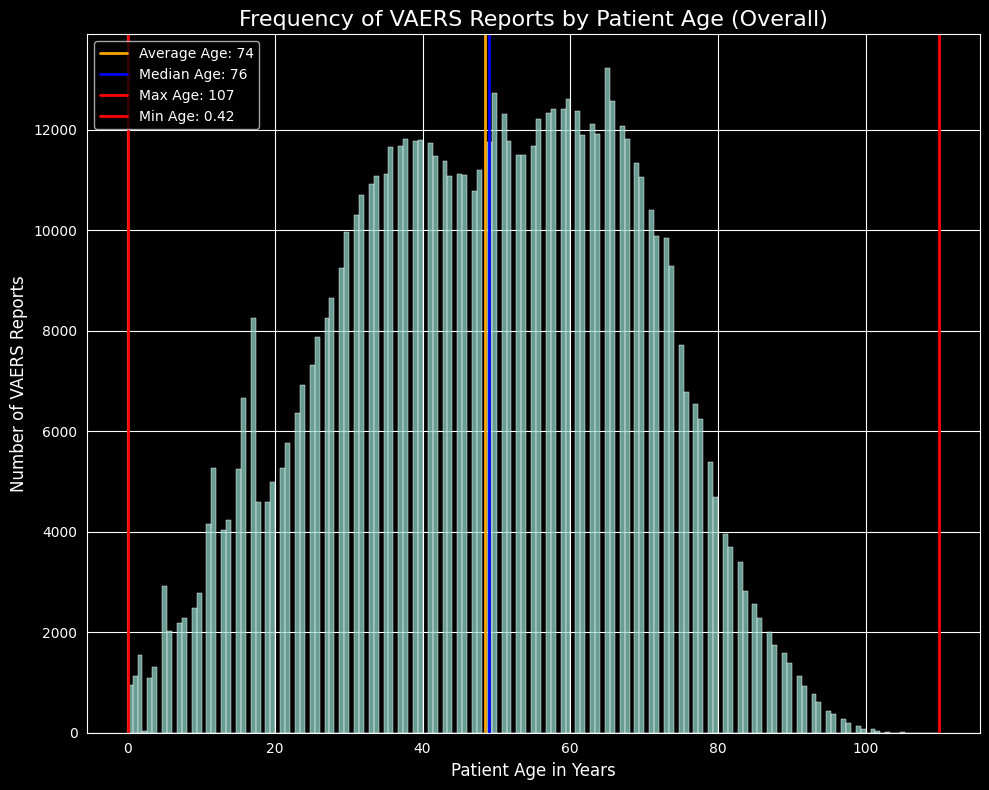

In [31]:
# plot distribution - patient age
fig, ax = plt.subplots(figsize=(10, 8))
patient_age_overall = sns.histplot(data=df_VAERS_filtered, x="AGE_YRS", legend=True)

plt.axvline(x=df_VAERS_filtered.AGE_YRS.mean(),
            color='orange', lw=2.0, label='Average Age: 74')
plt.axvline(x=df_VAERS_filtered.AGE_YRS.median(), color = 'blue', lw=2.0, label='Median Age: 76')
plt.axvline(x=df_VAERS_filtered.AGE_YRS.max(), color = 'red', lw=2.0, label='Max Age: 107')
plt.axvline(x=df_VAERS_filtered.AGE_YRS.min(), color = 'red', lw=2.0, label='Min Age: 0.42')

plt.legend(loc='upper left')

ax.set_xlabel('Patient Age in Years', fontsize=12)
ax.set_ylabel('Number of VAERS Reports', fontsize=12)
ax.set_title('Frequency of VAERS Reports by Patient Age (Overall)', fontsize=16)

fig.savefig('visualizations/overall/frequency_reports_age_OVERALL.png')

plt.tight_layout()
plt.show()

In [102]:
# save image to PNG
plt.savefig('visualizations/overall/frequency_reports_age_OVERALL')

<Figure size 640x480 with 0 Axes>

## Frequency of Reports by Sex

In [73]:
# # create groupby object
VAERS_grouped = df_VAERS_filtered.groupby(by=['SEX']).agg(report_count=("VAERS_ID", 'count'))

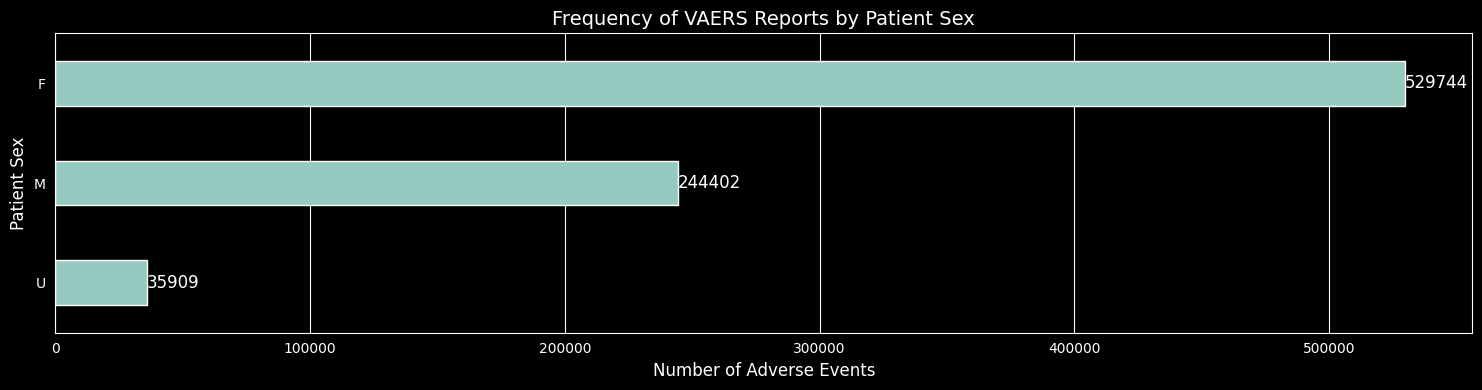

In [103]:
# plot adverse event counts - patient sex

# bar chart
fig, ax = plt.subplots(figsize=(15, 4))
sns.barplot(data=VAERS_grouped, x='report_count', y='SEX', legend=False, width=0.5, gap=0.1) # seaborn horizontal chart

for container in ax.containers:
    ax.bar_label(container, fontsize=12)

ax.set_xlabel('Number of Adverse Events', fontsize=12)
ax.set_ylabel('Patient Sex', fontsize=12)
ax.set_title('Frequency of VAERS Reports by Patient Sex', fontsize=14)

fig.savefig('visualizations/overall/frequency_reports_sex_OVERALL.png')

plt.tight_layout()
plt.show()

## Frequency of Reports by Patient Location

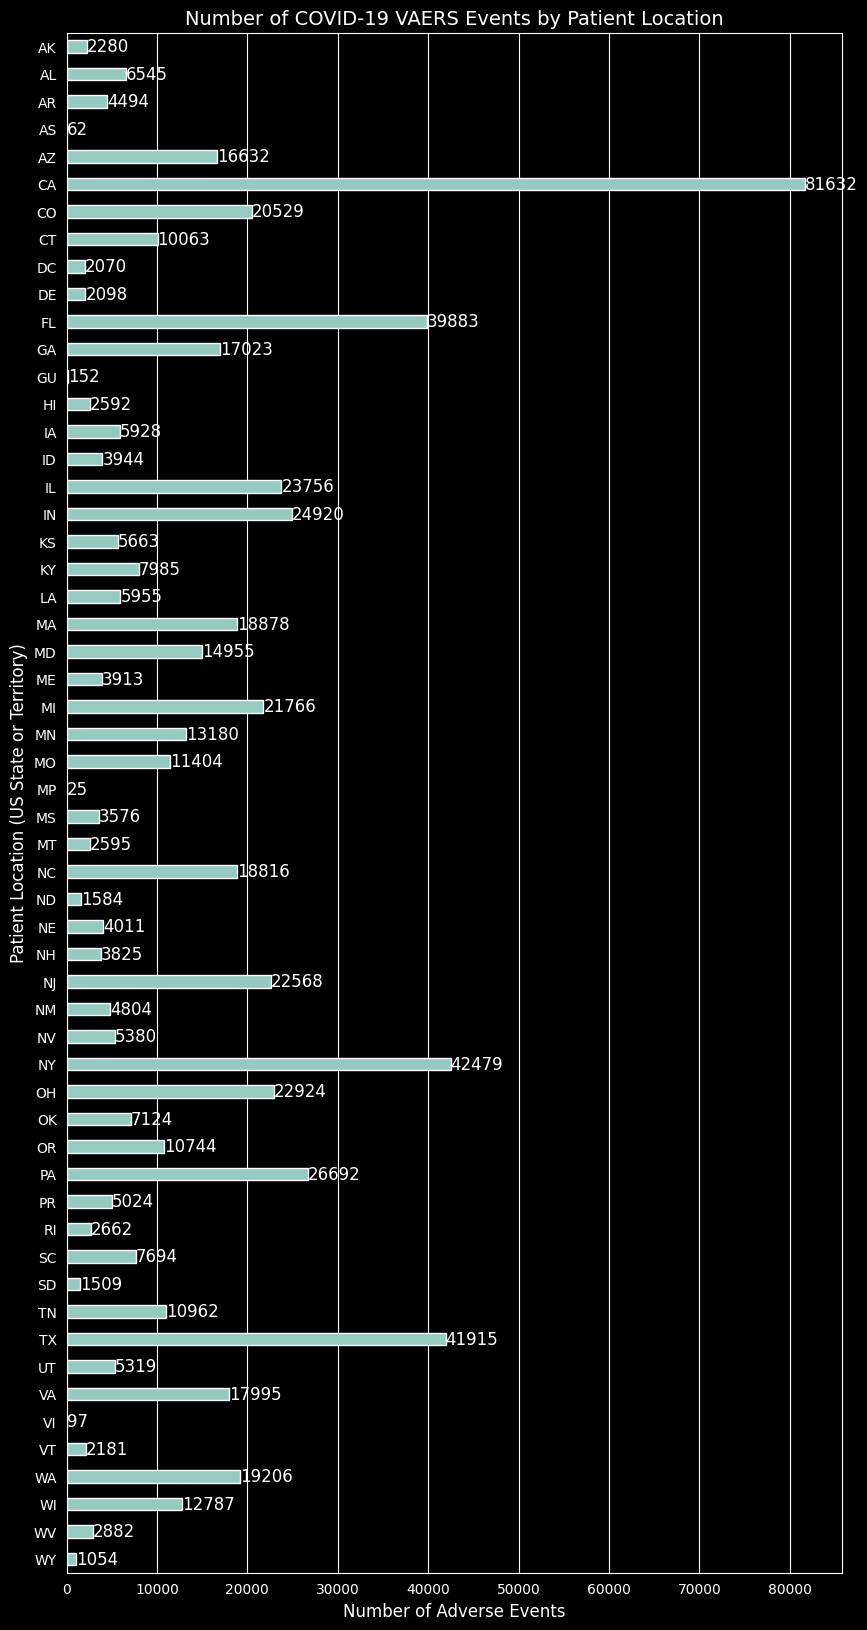

'Note - double-check filtering and create another view of this chart sorted by counts rather than alphabetical.'

<Figure size 640x480 with 0 Axes>

In [104]:
# plot adverse event counts - patient location

bar1 = df_VAERS_filtered.groupby(["STATE"]).agg(report_count=("VAERS_ID", 'count'))

# bar chart
fig, ax = plt.subplots(figsize=(10, 20))
sns.barplot(data=bar1, x='report_count', y='STATE', legend=False, width=0.5, gap=0.1) # seaborn horizontal chart

for container in ax.containers:
    ax.bar_label(container, fontsize=12)
ax.set_xlabel('Number of Adverse Events', fontsize=12)
ax.set_ylabel('Patient Location (US State or Territory)', fontsize=12)
ax.set_title('Number of COVID-19 VAERS Events by Patient Location', fontsize=14)

plt.show()

fig.savefig('visualizations/overall/frequency_reports_location_OVERALL.png')
plt.tight_layout()

'''Note - double-check filtering and create another view of this chart sorted by counts rather than alphabetical.'''

# Reports Over Time

## Frequency of Reports Over Time

In [75]:
# convert date objects in df_VAERS_filtered to datetime objects
# didn't transfer from prior data cleaning for some reason??
# df_VAERS - convert date columns to datetime objects
df_VAERS_filtered['RECVDATE'] = df_VAERS_filtered['RECVDATE'].astype('datetime64[ns]')
df_VAERS_filtered['DATEDIED'] = df_VAERS_filtered['DATEDIED'].astype('datetime64[ns]')
df_VAERS_filtered['VAX_DATE'] = df_VAERS_filtered['VAX_DATE'].astype('datetime64[ns]')
df_VAERS_filtered['ONSET_DATE'] = df_VAERS_filtered['ONSET_DATE'].astype('datetime64[ns]')
df_VAERS_filtered['TODAYS_DATE'] = df_VAERS_filtered['TODAYS_DATE'].astype('datetime64[ns]')
df_VAERS_filtered['RPT_DATE'] = df_VAERS_filtered['RPT_DATE'].astype('datetime64[ns]')

# verify conversion to datetime object
print(df_VAERS_filtered['RECVDATE'].dtype)
print(df_VAERS_filtered['DATEDIED'].dtype)
print(df_VAERS_filtered['VAX_DATE'].dtype)
print(df_VAERS_filtered['ONSET_DATE'].dtype)
print(df_VAERS_filtered['TODAYS_DATE'].dtype)
print(df_VAERS_filtered['RPT_DATE'].dtype)

datetime64[ns]
datetime64[ns]
datetime64[ns]
datetime64[ns]
datetime64[ns]
datetime64[ns]


In [76]:
# plot adverse events over time - both companies
bar2 = df_VAERS_filtered.sort_values(by='ONSET_DATE')

# add column to line1 with MonthYear object
import datetime
bar2['ONSET_YEAR'] = bar2['ONSET_DATE'].dt.year
bar2['ONSET_MONTH'] = bar2['ONSET_DATE'].dt.strftime('%b')
bar2['ONSET_MONTHYEAR'] = bar2['ONSET_DATE'].dt.strftime('%Y-%m')

bar2.head()

,VAERS_ID,RECVDATE,STATE,AGE_YRS,SEX,RPT_DATE,DIED,DATEDIED,L_THREAT,ER_VISIT,...,VAX_TYPE,VAX_MANU,VAX_LOT,VAX_DOSE_SERIES,VAX_ROUTE,VAX_SITE,VAX_NAME,ONSET_YEAR,ONSET_MONTH,ONSET_MONTHYEAR
740790,2259700,2022-04-30,NaN,NaN,U,NaT,N,NaT,N,N,...,COVID19,PFIZER\BIONTECH,NaN,2.0,UN,UN,PFIZER-BIONTECH,2020.0,Jan,2020-01
407045,1439899,2021-07-01,OR,31.0,F,NaT,N,NaT,N,N,...,COVID19,PFIZER\BIONTECH,EK9231,1.0,UN,LA,PFIZER-BIONTECH,2020.0,Jan,2020-01
786184,2449850,2022-09-17,NaN,64.0,M,NaT,N,NaT,N,N,...,COVID19,MODERNA,NaN,1.0,OT,UN,MODERNA,2020.0,Jan,2020-01
48337,2455904,2021-01-19,NaN,38.0,F,NaT,N,NaT,N,N,...,COVID19,PFIZER\BIONTECH,EK5730,1.0,IM,LA,PFIZER-BIONTECH,2020.0,Jan,2020-01
464377,1568333,2021-08-15,TX,NaN,F,NaT,N,NaT,N,N,...,COVID19,MODERNA,025J20-2A,1.0,OT,UN,MODERNA,2020.0,Jan,2020-01


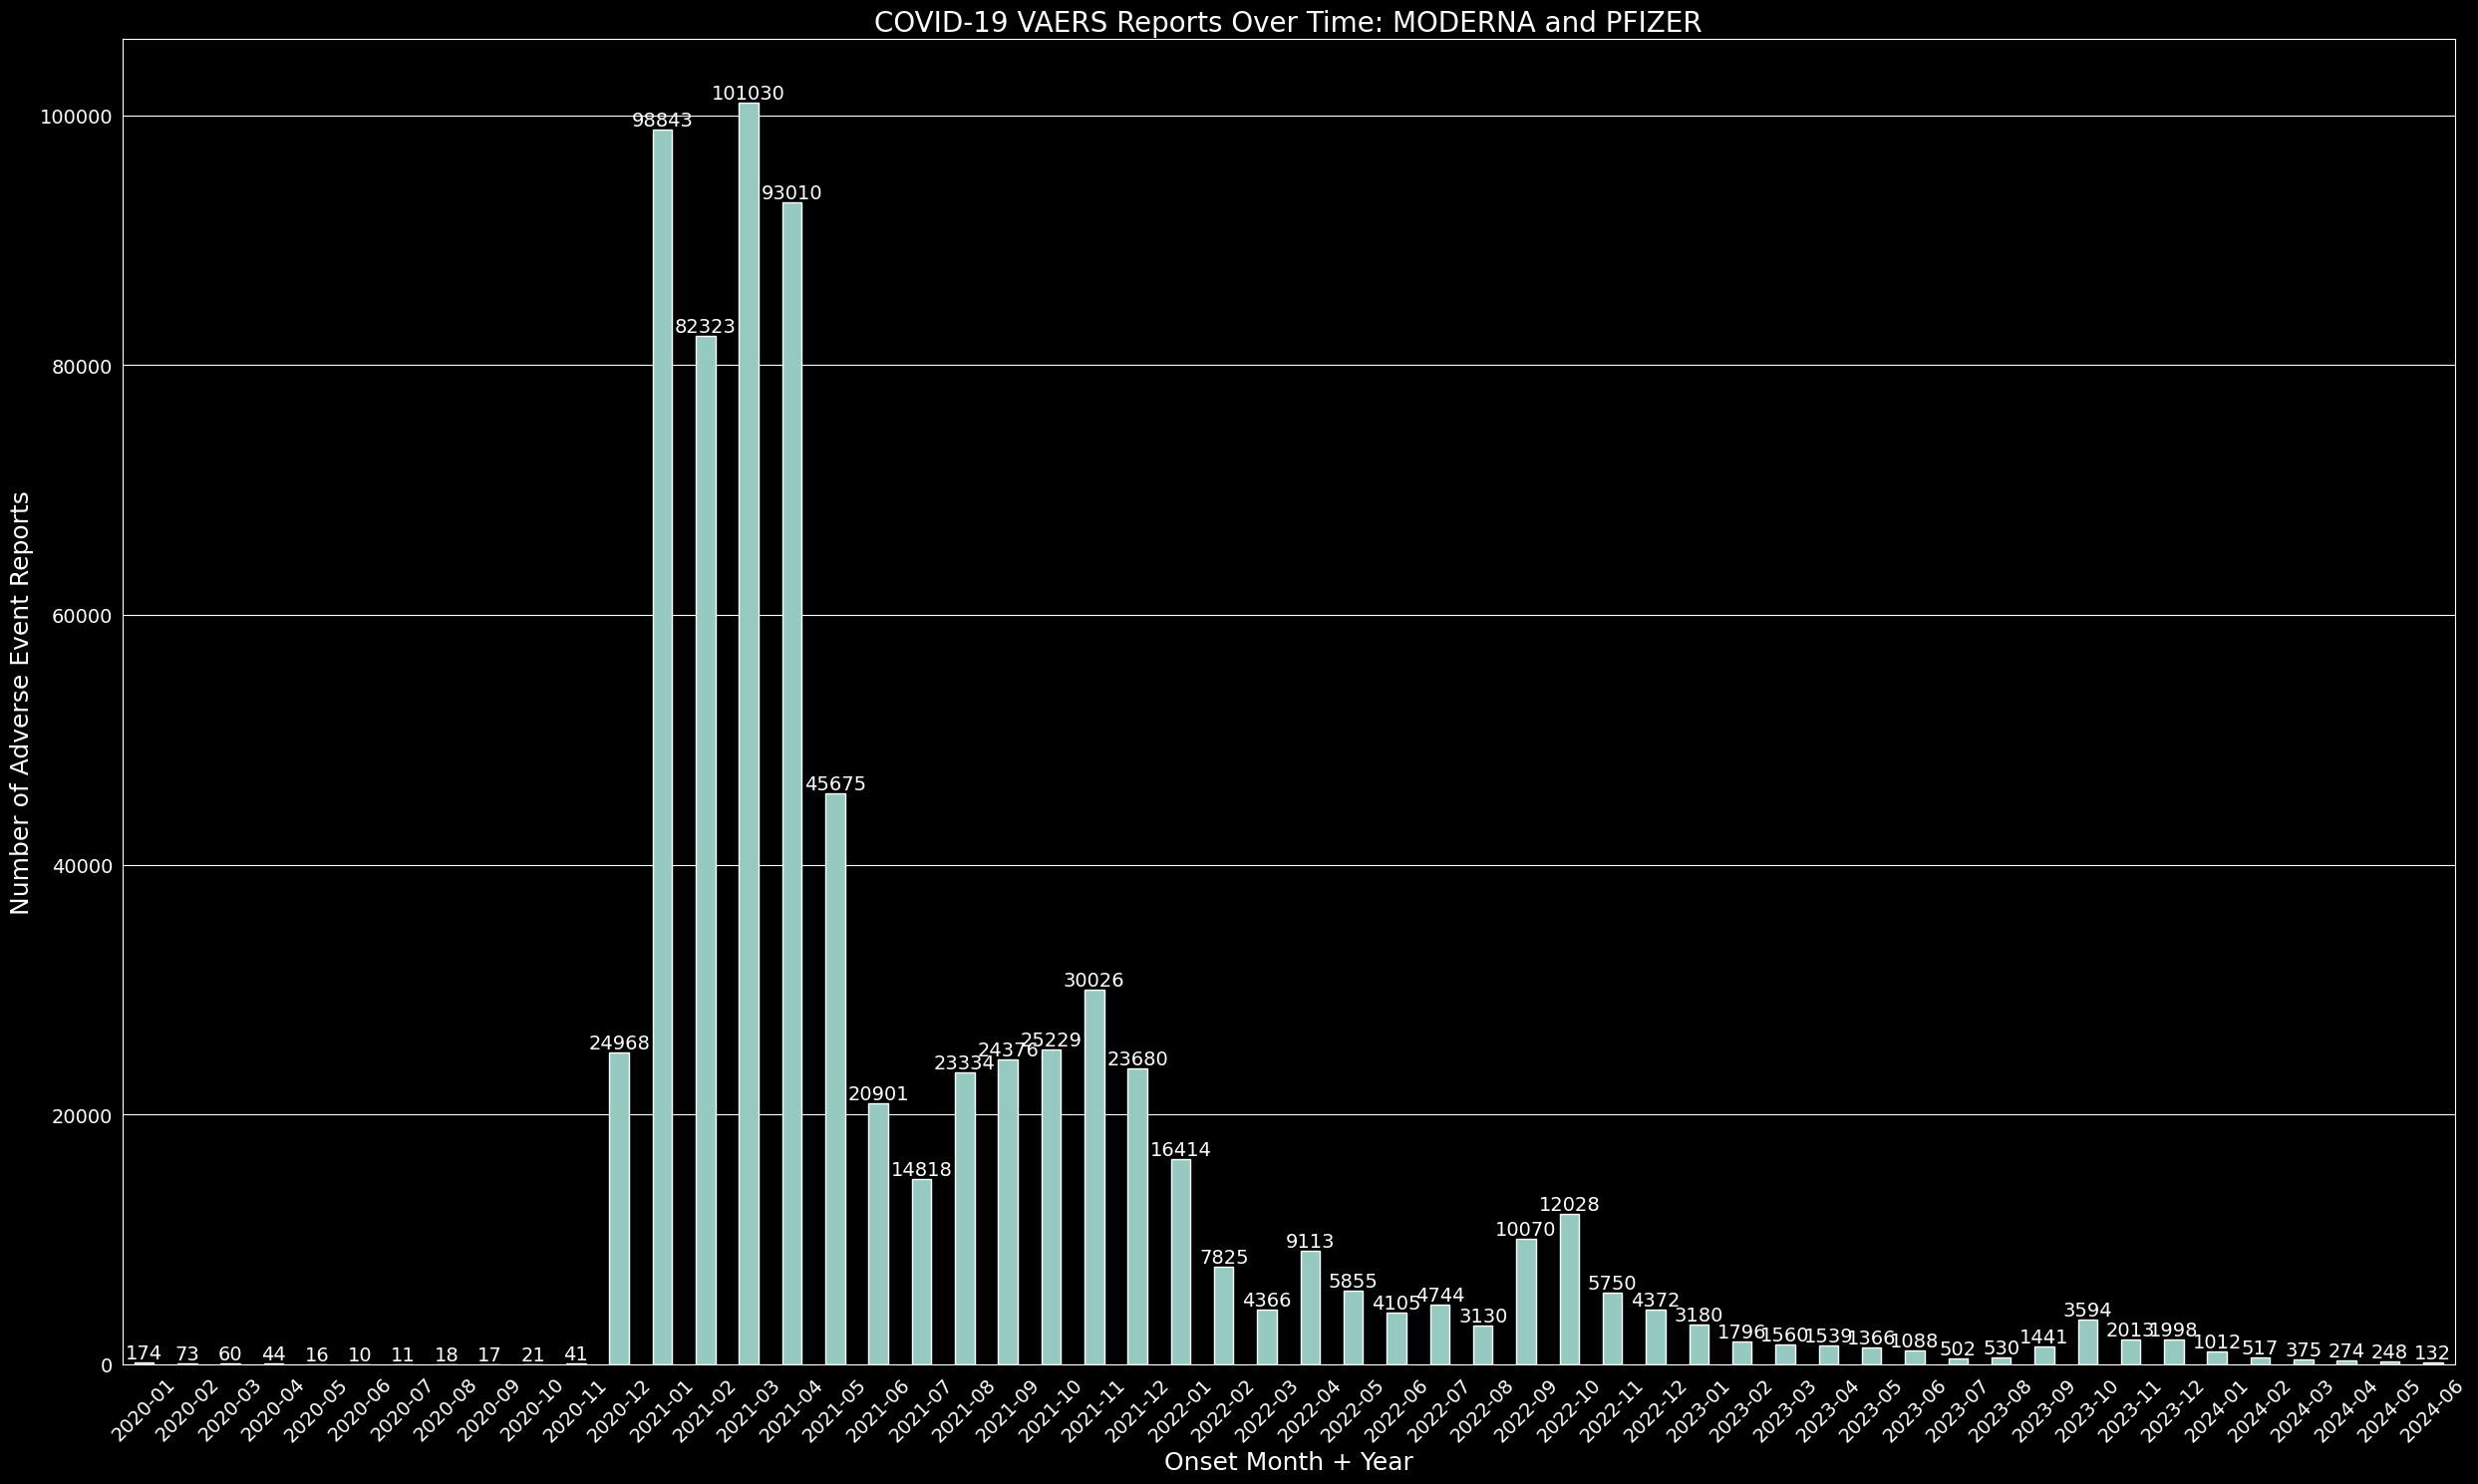

In [105]:
# plot adverse events over time - both companies

# create grouped bar chart
bar2_grouped = bar2.groupby(by=["ONSET_MONTHYEAR"]).agg(report_count=("VAERS_ID", 'count'))
# display(bar2_grouped)

# bar chart
fig, ax = plt.subplots(figsize=(25, 15))
frequency_reports_over_time_OVERALL = sns.barplot(data=bar2_grouped, x="ONSET_MONTHYEAR", y="report_count", width=0.5, gap=0.1)

for container in ax.containers:
    ax.bar_label(container, fontsize=14)
ax.set_xlabel('Onset Month + Year', fontsize=18)
ax.tick_params("x", rotation=45)
ax.tick_params(axis='both', which='major', labelsize=14)
ax.tick_params(axis='both', which='minor', labelsize=14)
ax.set_ylabel('Number of Adverse Event Reports', fontsize=18)
ax.set_title('COVID-19 VAERS Reports Over Time: MODERNA and PFIZER', fontsize=20)

plt.tight_layout()
plt.show()

fig.savefig("visualizations/overall/frequency_reports_over_time_OVERALL.png")

# for final visualizations - would be nice to code years by hue

## Frequency of Reports Over Time - Moderna Only

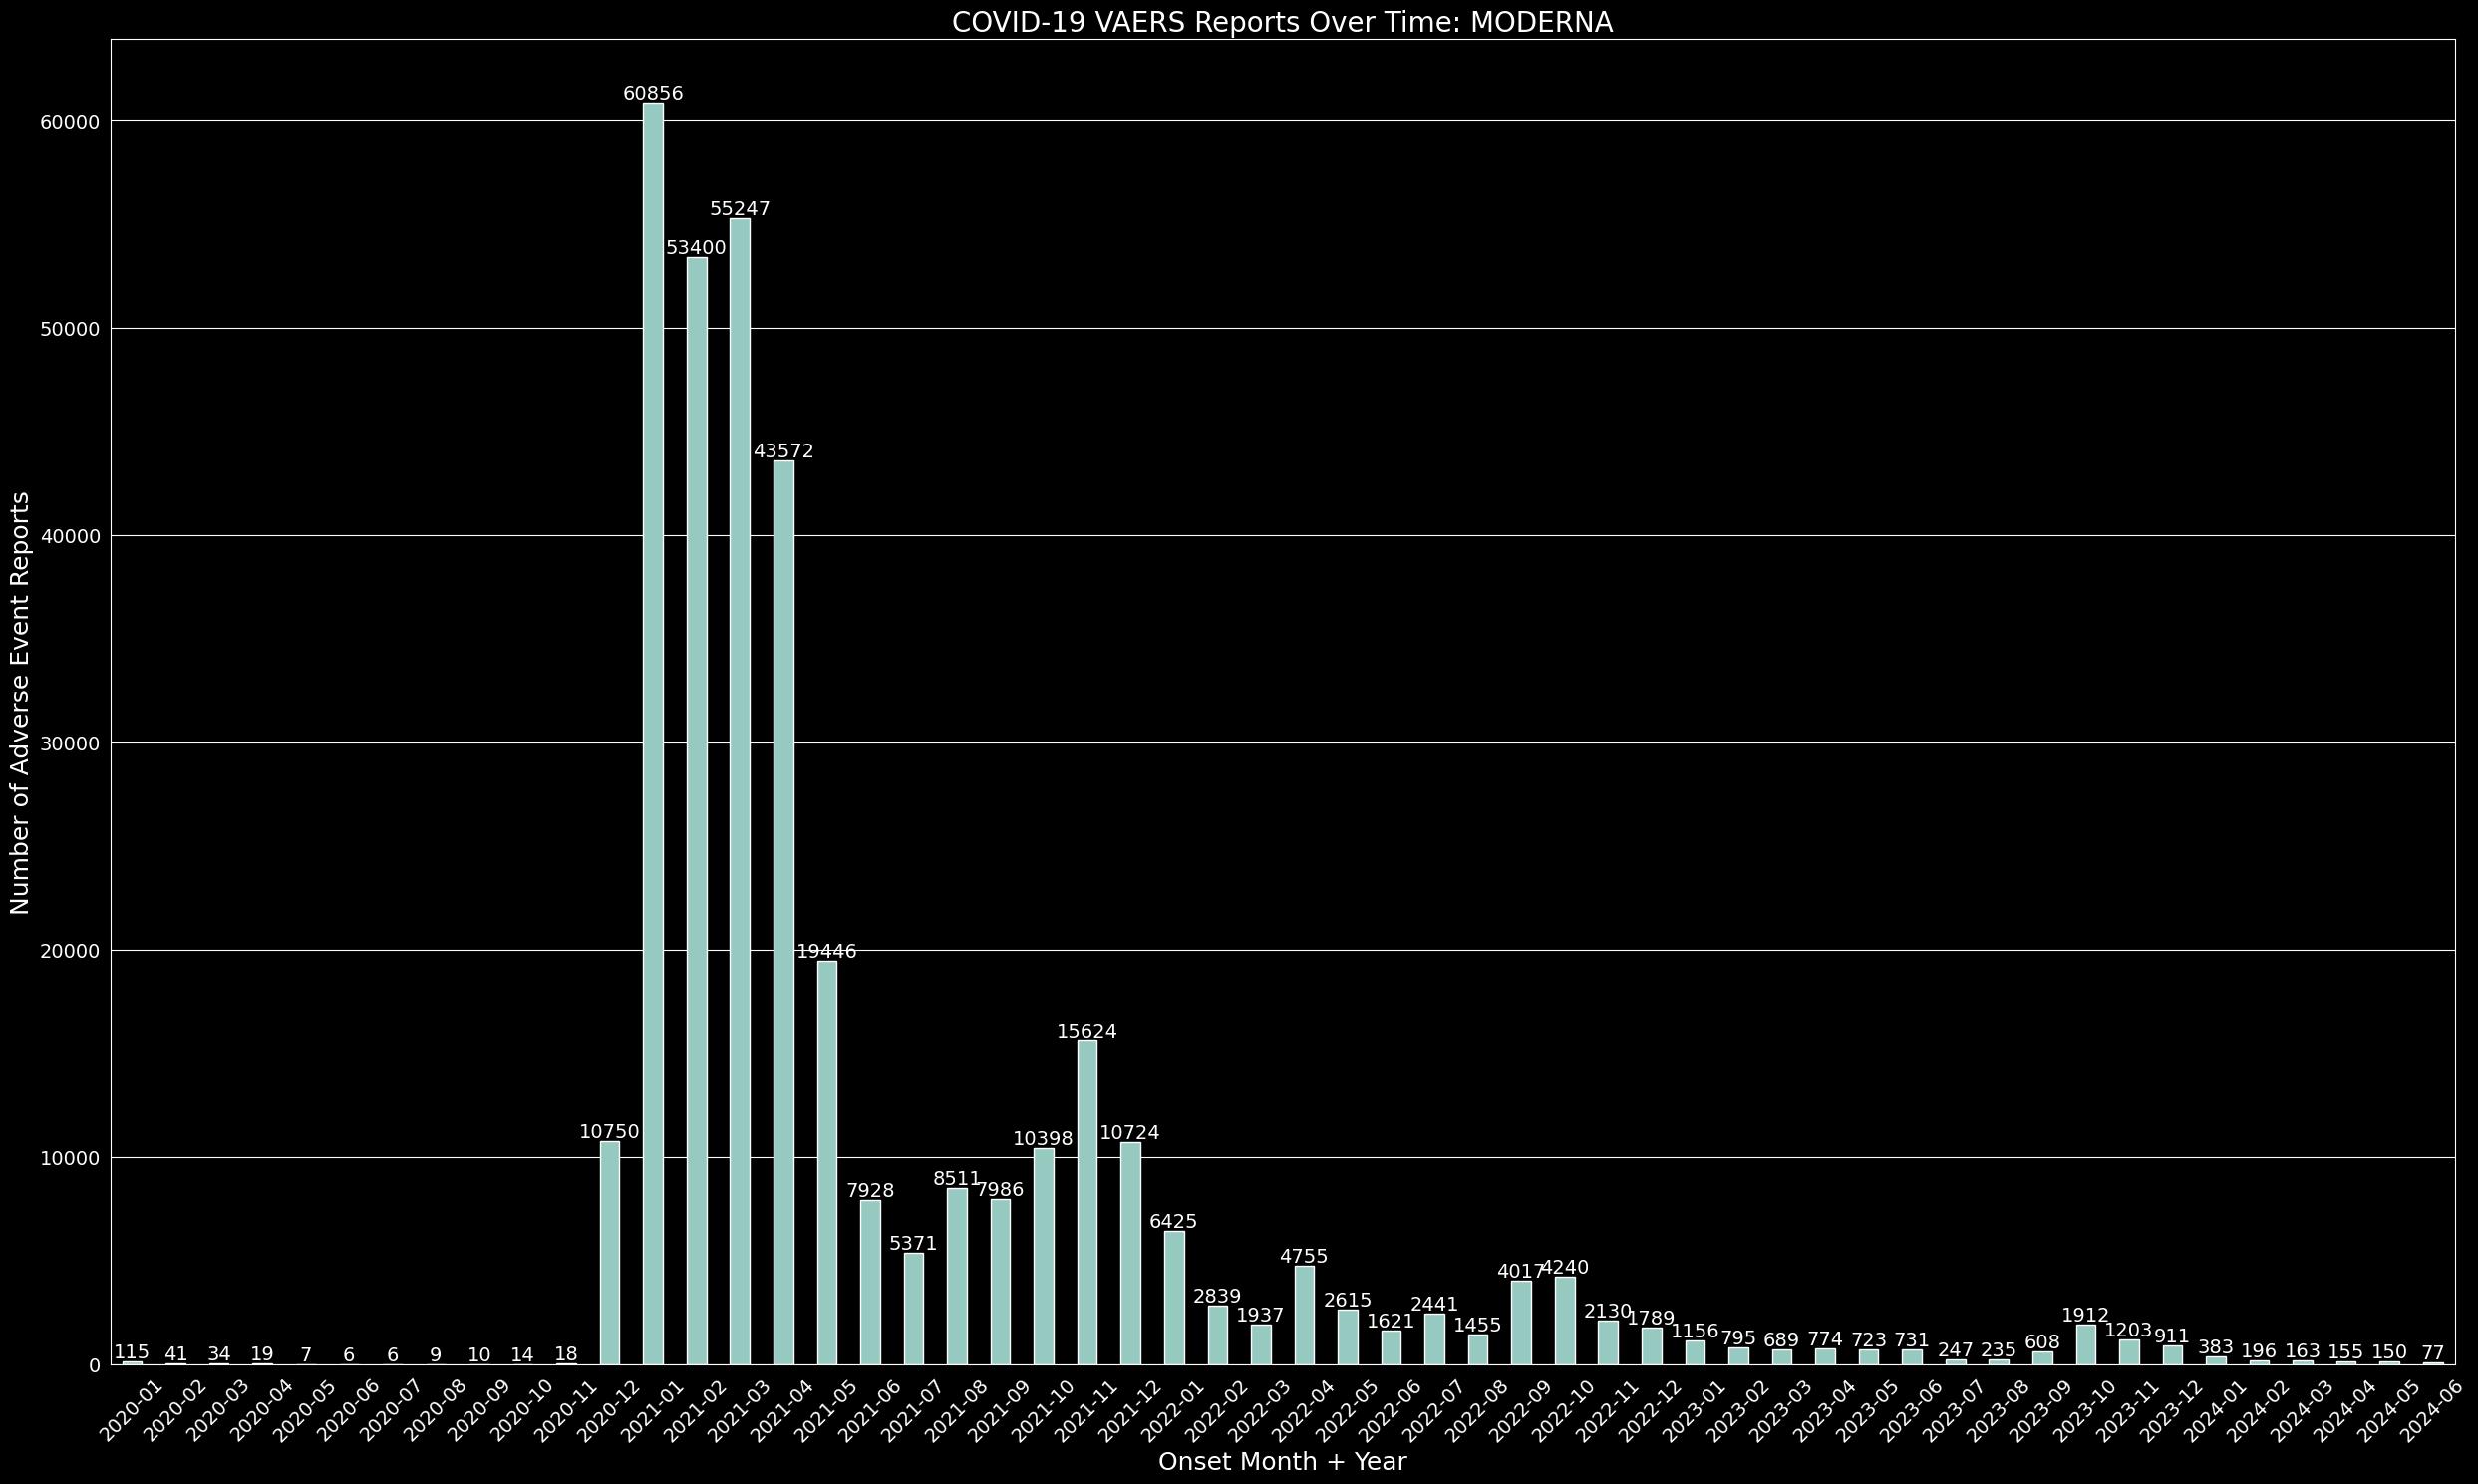

In [106]:
# plot adverse events over time - Moderna only
bar3 = bar2[bar2["VAX_MANU"] == "MODERNA"]
bar3_grouped = bar3.groupby(by=["ONSET_MONTHYEAR"]).agg(report_count=("VAERS_ID", 'count'))
# display(bar3_grouped)

# bar chart
fig, ax = plt.subplots(figsize=(25, 15))
sns.barplot(data=bar3_grouped, x="ONSET_MONTHYEAR", y="report_count", width=0.5, gap=0.1)

for container in ax.containers:
    ax.bar_label(container, fontsize=14)
ax.set_xlabel('Onset Month + Year', fontsize=18)
ax.tick_params("x", rotation=45)
ax.tick_params(axis='both', which='major', labelsize=14)
ax.tick_params(axis='both', which='minor', labelsize=14)
ax.set_ylabel('Number of Adverse Event Reports', fontsize=18)
ax.set_title('COVID-19 VAERS Reports Over Time: MODERNA', fontsize=20)

plt.tight_layout()
plt.show()

fig.savefig("visualizations/moderna/frequency_reports_over_time_MODERNA.png")

# for final visualizations - would be nice to code years by hue

## Frequency of Reports Over Time - Pfizer Only

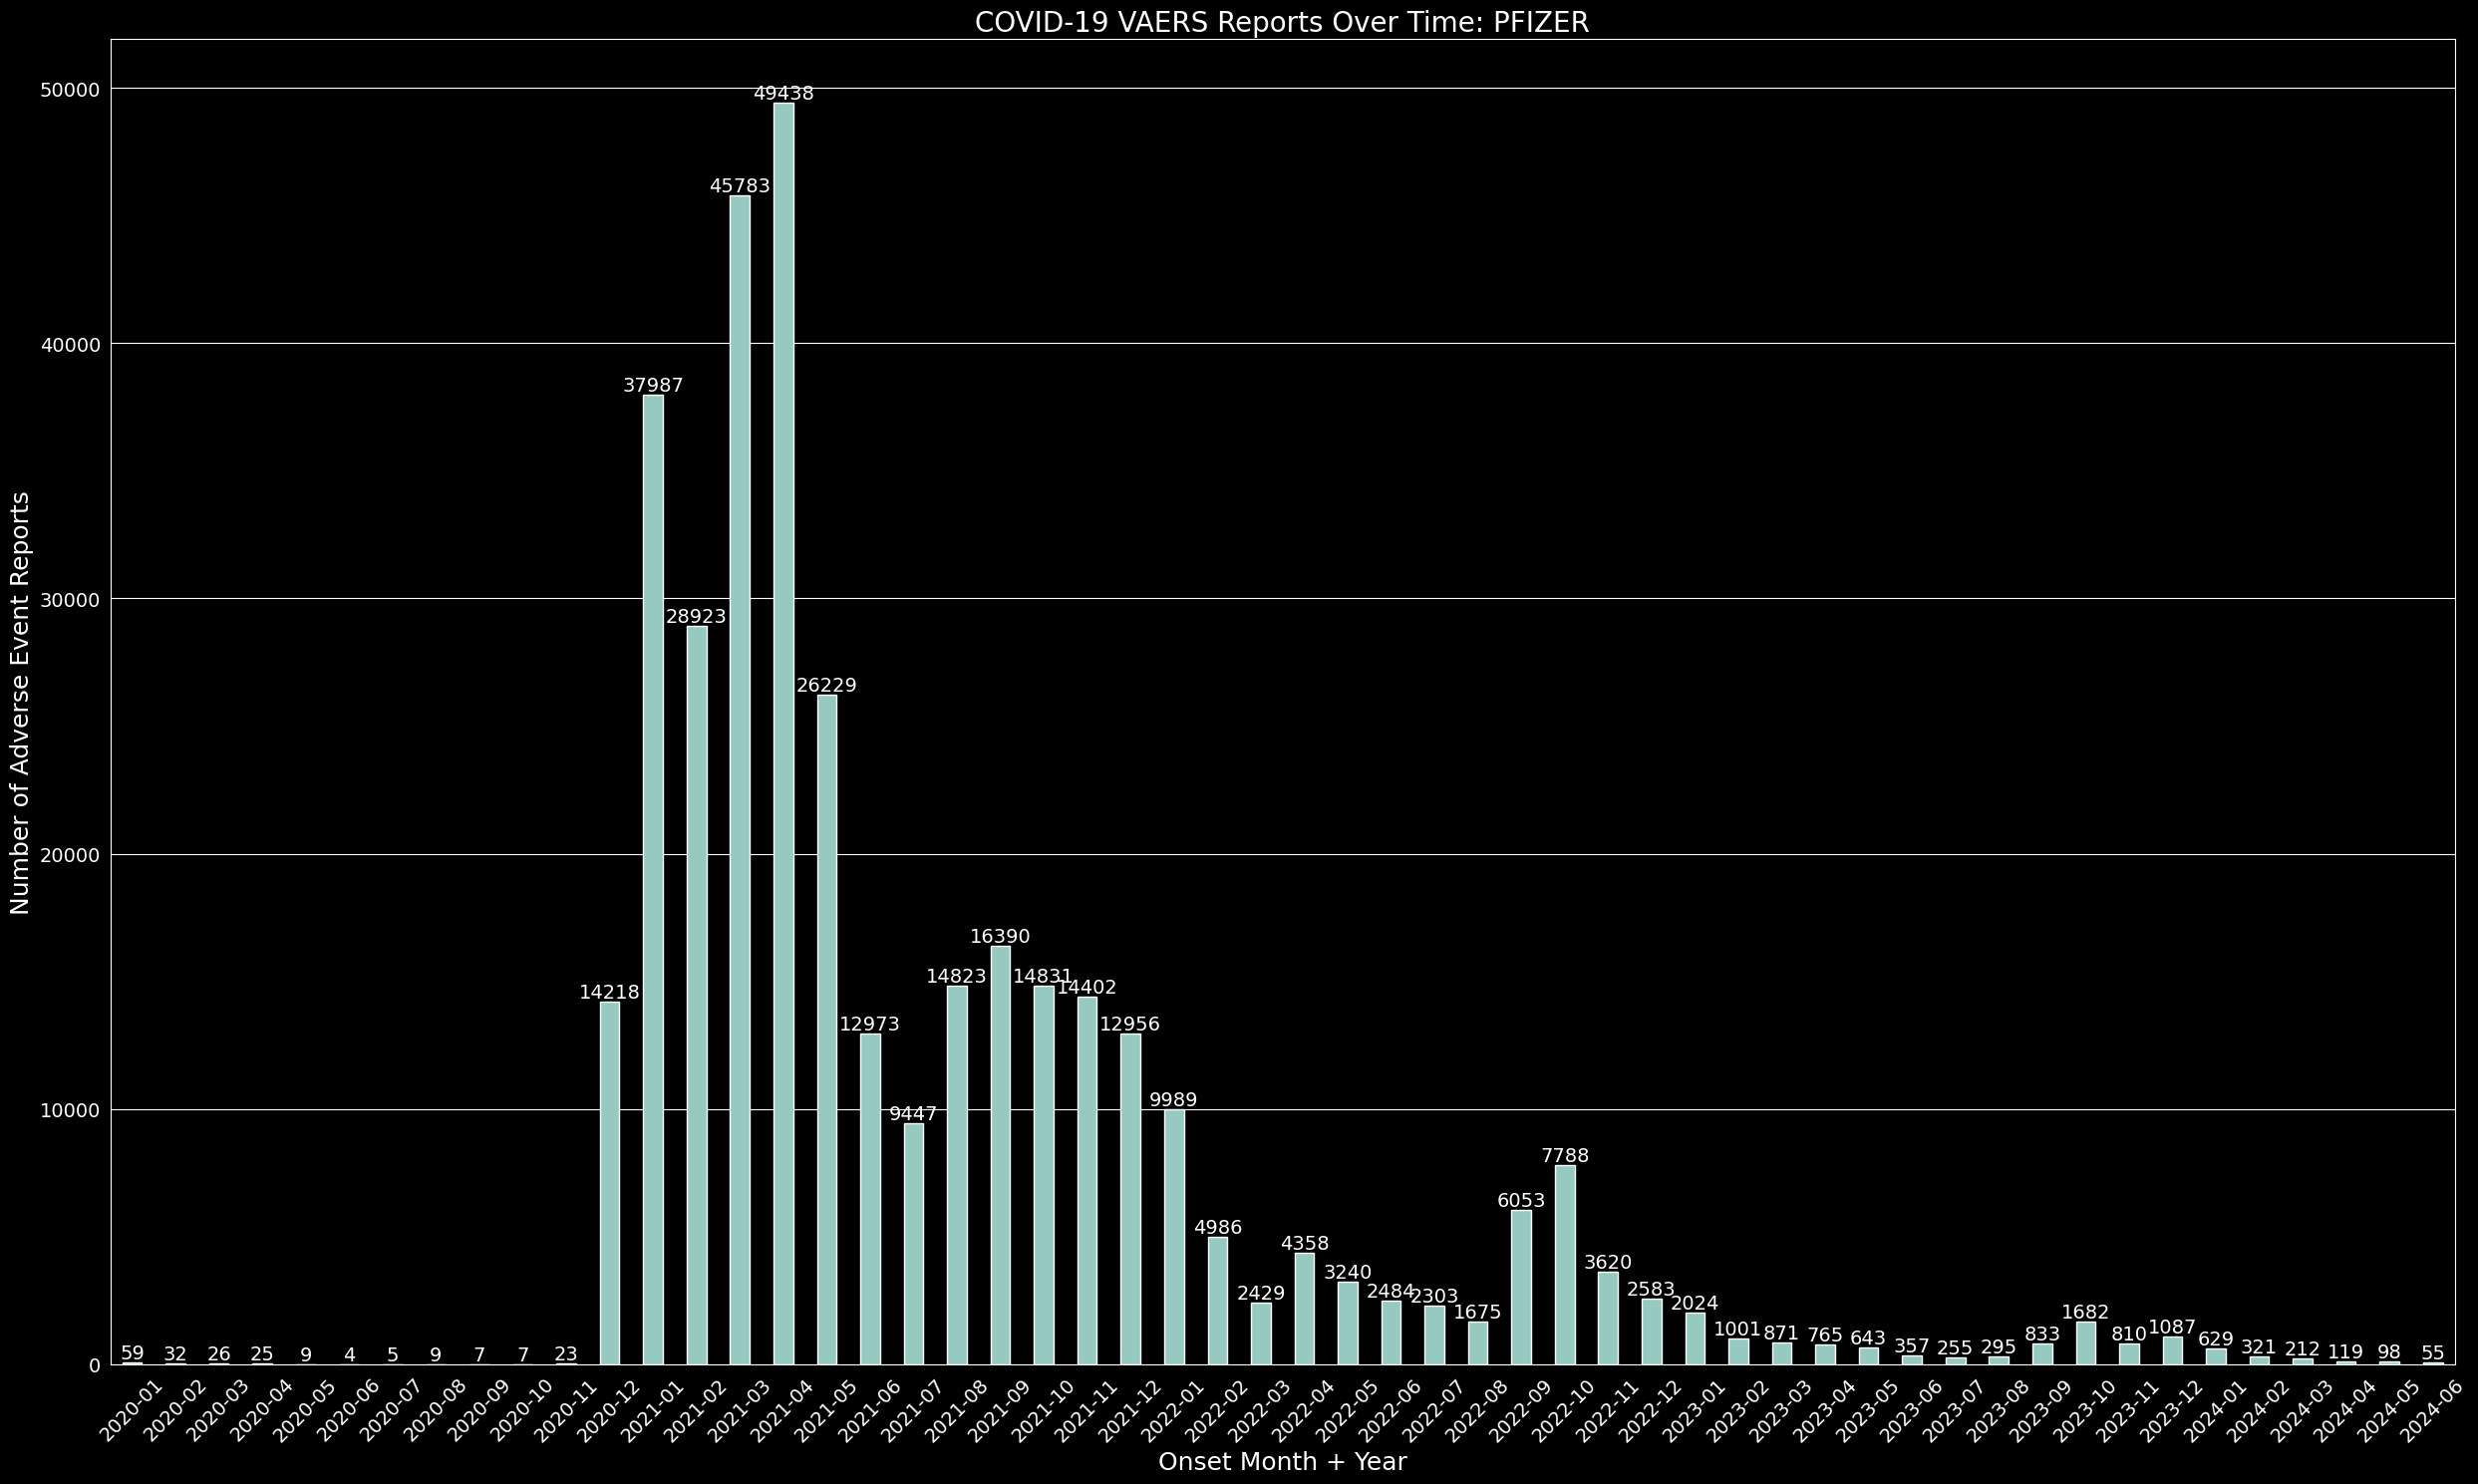

In [107]:
# plot adverse events over time - Pfizer only
bar4 = bar2[bar2["VAX_MANU"] == "PFIZER\\BIONTECH"]
bar4_grouped = bar4.groupby(by=["ONSET_MONTHYEAR"]).agg(report_count=("VAERS_ID", 'count'))
# display(bar3_grouped)

# bar chart
fig, ax = plt.subplots(figsize=(25, 15))
sns.barplot(data=bar4_grouped, x="ONSET_MONTHYEAR", y="report_count", width=0.5, gap=0.1)

for container in ax.containers:
    ax.bar_label(container, fontsize=14)
ax.set_xlabel('Onset Month + Year', fontsize=18)
ax.tick_params("x", rotation=45)
ax.tick_params(axis='both', which='major', labelsize=14)
ax.tick_params(axis='both', which='minor', labelsize=14)
ax.set_ylabel('Number of Adverse Event Reports', fontsize=18)
ax.set_title('COVID-19 VAERS Reports Over Time: PFIZER', fontsize=20)

plt.tight_layout()
plt.show()

fig.savefig("visualizations/pfizer/frequency_reports_over_time_PFIZER.png")

# for final visualizations - would be nice to code years by hue

# Common Symptoms

## Common Symptoms - Both

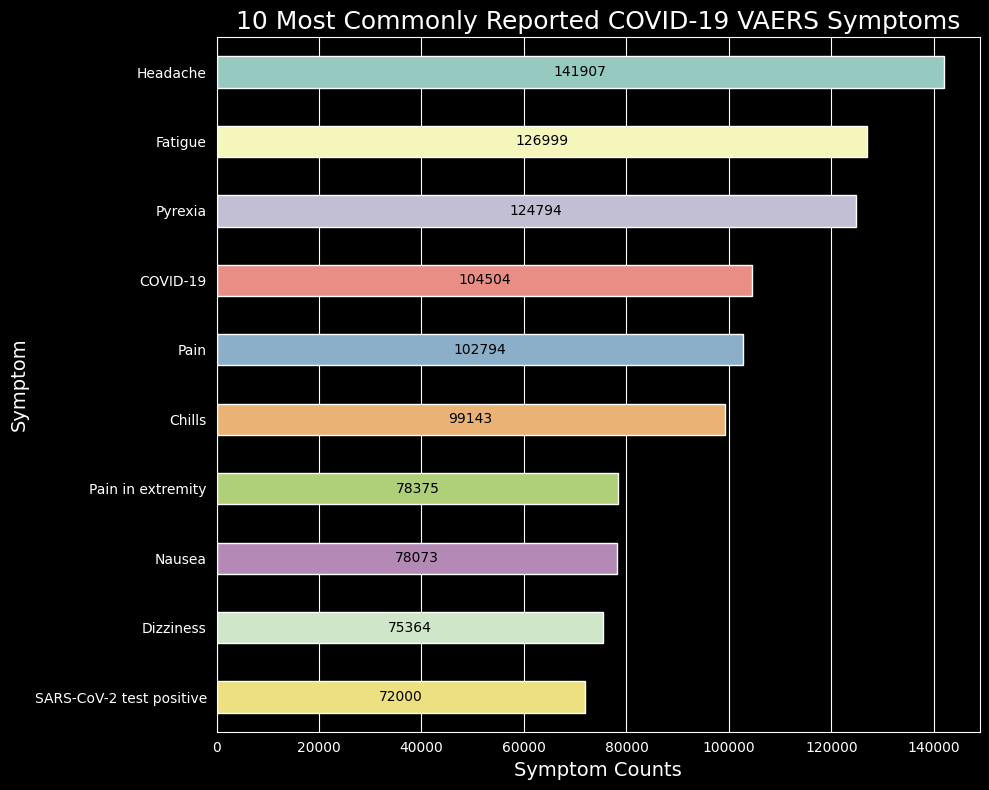

In [108]:
# plot counts of 10 most common symptoms
symptom_counts = df_symptoms_filtered['symptom'].value_counts()
df_symptom_counts = symptom_counts.to_frame()
df_symptom_counts[0:10]

# bar chart
fig, ax = plt.subplots(figsize=(10, 8))
most_common_symptoms_overall = sns.barplot(data=df_symptom_counts[0:10], x="count", y="symptom", hue='symptom', width=0.5, gap=0.1)

for container in ax.containers:
    ax.bar_label(container, fontsize=10, label_type='center', color='black')
ax.set_xlabel('Symptom Counts', fontsize=14)
ax.set_ylabel('Symptom', fontsize=14)
ax.set_title('10 Most Commonly Reported COVID-19 VAERS Symptoms', fontsize=18)

plt.tight_layout()
plt.show()

fig.savefig('visualizations/overall/most_common_symptoms_OVERALL')

## Common Symptoms - Pfizer

In [41]:
# filter for Pfizer
df_symptom_vax_Pfizer = df_symptoms_filtered[df_symptoms_filtered['VAX_MANU'] == 'PFIZER\\BIONTECH']

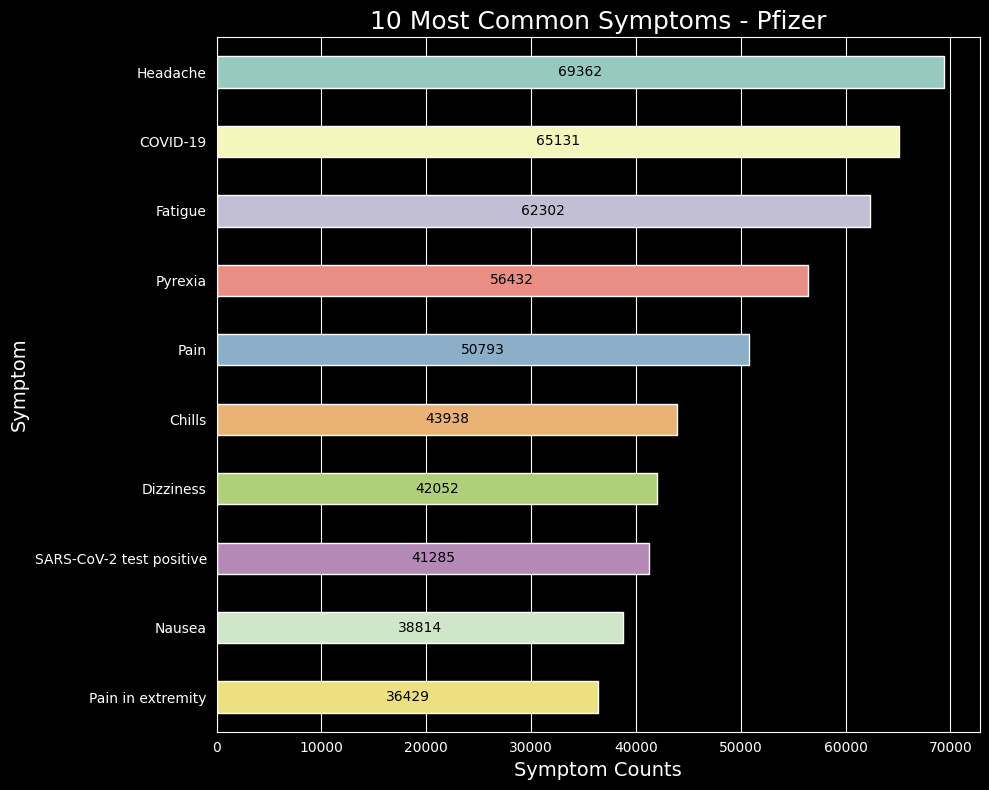

In [42]:
# get counts of 10 most common symptoms - Pfizer
symptom_counts_Pfizer = df_symptom_vax_Pfizer['symptom'].value_counts()
df_symptom_counts_Pfizer = symptom_counts_Pfizer.to_frame()

# bar chart
fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(data=df_symptom_counts_Pfizer[0:10], x="count", y="symptom", hue='symptom', width=0.5, gap=0.1)

for container in ax.containers:
    ax.bar_label(container, fontsize=10, label_type='center', color='black')
ax.set_xlabel('Symptom Counts', fontsize=14)
ax.set_ylabel('Symptom', fontsize=14)
ax.set_title('10 Most Common Symptoms - Pfizer', fontsize=18)

plt.tight_layout()
plt.show()

fig.savefig('visualizations/pfizer/most_common_symptoms_Pfizer.png')



## Common Symptoms - Moderna

In [43]:
# filter for Moderna
df_symptom_vax_Moderna = df_symptoms_filtered[df_symptoms_filtered['VAX_MANU'] == 'MODERNA']

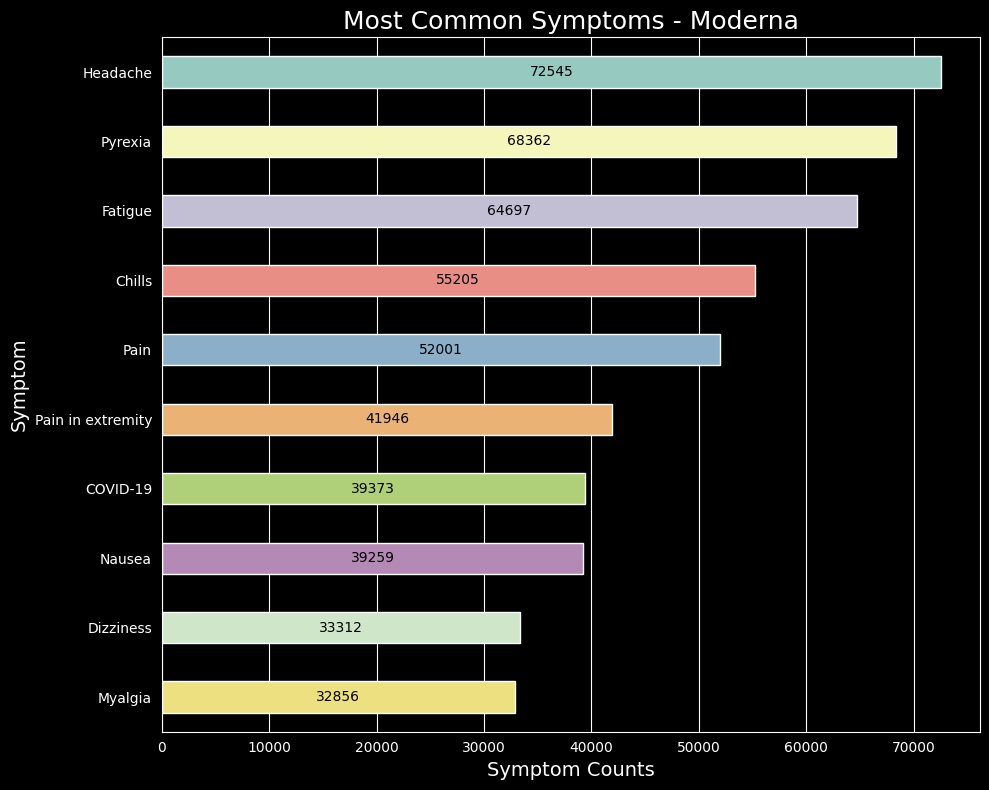

In [44]:
# plot counts of 10 most common symptoms - Moderna
symptom_counts_Moderna = df_symptom_vax_Moderna['symptom'].value_counts()
df_symptom_counts_Moderna = symptom_counts_Moderna.to_frame()

# bar chart
fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(data=df_symptom_counts_Moderna[0:10], x="count", y="symptom", hue='symptom', width=0.5, gap=0.1)

for container in ax.containers:
    ax.bar_label(container, fontsize=10, label_type='center', color='black')
ax.set_xlabel('Symptom Counts', fontsize=14)
ax.set_ylabel('Symptom', fontsize=14)
ax.set_title('Most Common Symptoms - Moderna', fontsize=18)

plt.tight_layout()
plt.show()

fig.savefig('visualizations/moderna/most_common_symptoms_Moderna.png')

## Common Symptoms - by Patient Sex

In [77]:
# merge df_symptoms_filtered and df_VAERS_filtered
df_symptoms_VAERS_merged = pd.merge(df_symptoms_filtered, df_VAERS_filtered, how='inner', on='VAERS_ID')

In [72]:
# filter by sex
df_symptoms_F = df_symptoms_VAERS_merged[df_symptoms_VAERS_merged['SEX'] == 'F']
df_symptoms_M = df_symptoms_VAERS_merged[df_symptoms_VAERS_merged['SEX'] == 'M']
df_symptoms_U = df_symptoms_VAERS_merged[df_symptoms_VAERS_merged['SEX'] == 'U']

In [47]:
# get counts of 10 most common symptoms by sex
symptom_counts_F = df_symptoms_F['symptom'].value_counts()
df_symptom_counts_F = symptom_counts_F.to_frame()
symptom_counts_M = df_symptoms_M['symptom'].value_counts()
df_symptom_counts_M = symptom_counts_M.to_frame()
symptom_counts_U = df_symptoms_U['symptom'].value_counts()
df_symptom_counts_U = symptom_counts_U.to_frame()

# df_symptom_counts_F[0:10]
# df_symptom_counts_M[0:10]
# df_symptom_counts_U[0:10]

### Common Symptoms - Female

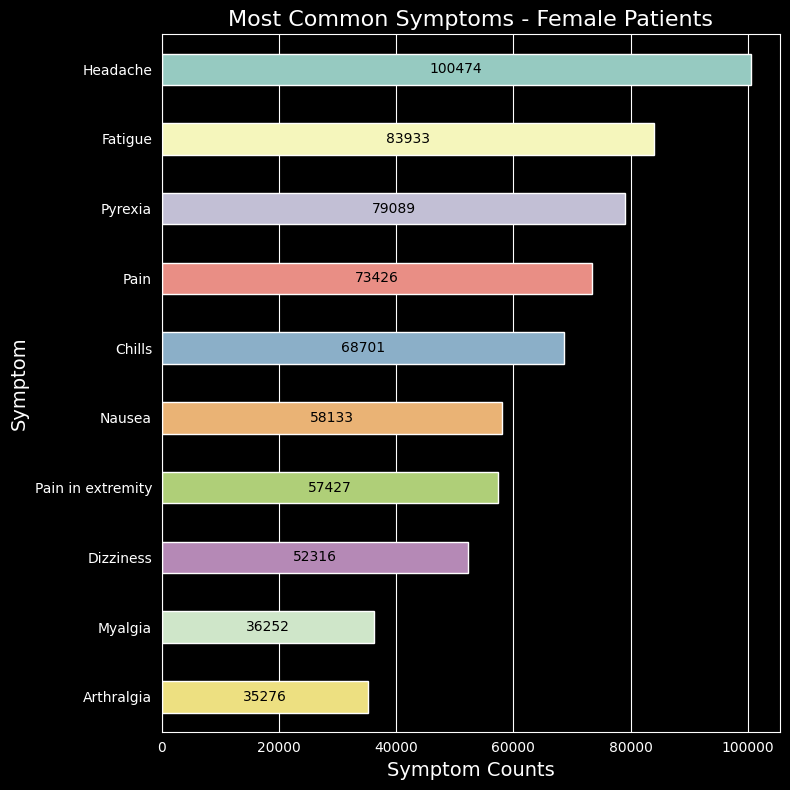

In [109]:
# plot most common symptoms by sex - F

# bar chart
fig, ax = plt.subplots(figsize=(8, 8))
sns.barplot(data=df_symptom_counts_F[0:10], x="count", y="symptom", hue='symptom', width=0.5, gap=0.1)

for container in ax.containers:
    ax.bar_label(container, fontsize=10, label_type='center', color='black')
ax.set_xlabel('Symptom Counts', fontsize=14)
ax.set_ylabel('Symptom', fontsize=14)
ax.set_title('Most Common Symptoms - Female Patients', fontsize=16)

plt.tight_layout()
plt.show()

fig.savefig('visualizations/overall/most_common_symptoms_female.png')


### Common Symptoms - Male

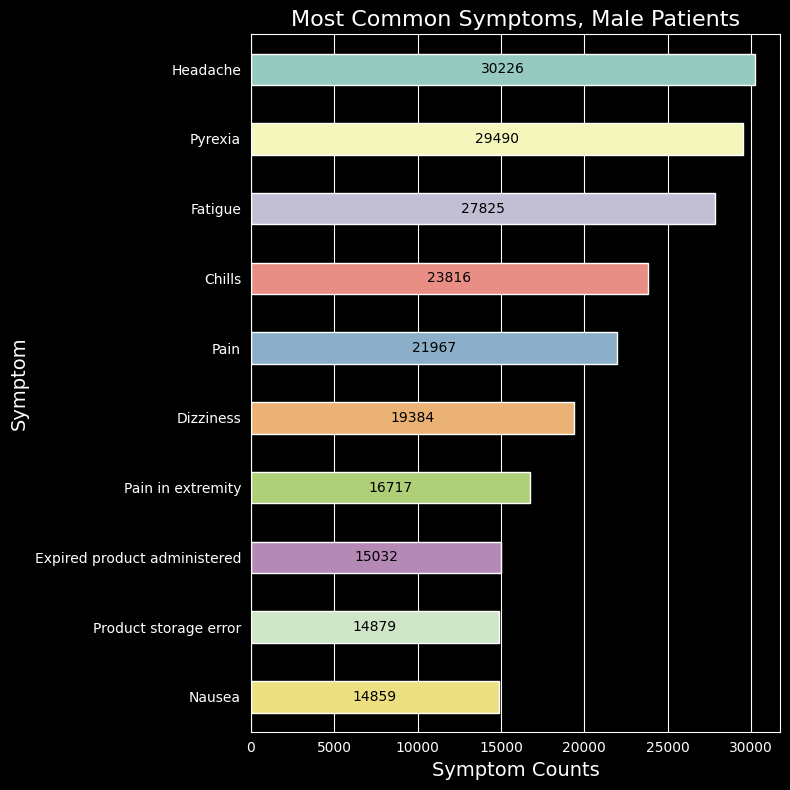

In [110]:
# plot most common symptoms by sex - M

# bar chart
fig, ax = plt.subplots(figsize=(8, 8))
sns.barplot(data=df_symptom_counts_M[0:10], x="count", y="symptom", hue='symptom', width=0.5, gap=0.1)

for container in ax.containers:
    ax.bar_label(container, fontsize=10, label_type='center', color='black')
ax.set_xlabel('Symptom Counts', fontsize=14)
ax.set_ylabel('Symptom', fontsize=14)
ax.set_title('Most Common Symptoms, Male Patients', fontsize=16)

plt.tight_layout()
plt.show()

fig.savefig('visualizations/overall/most_common_symptoms_male.png')

### Common Symptoms - Sex Not Identified

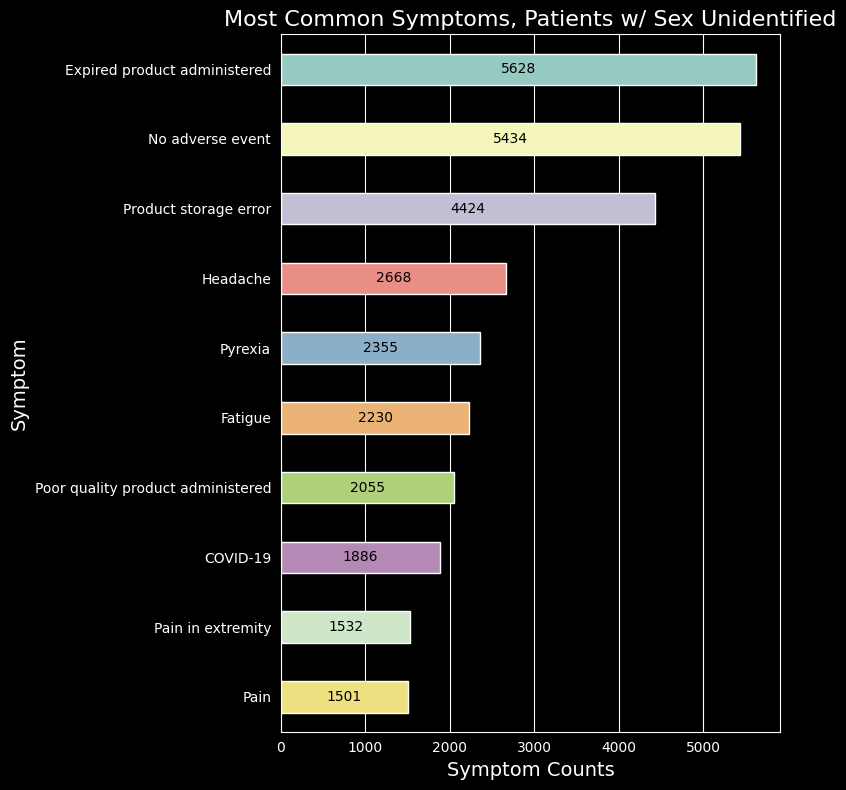

In [111]:
# plot most common symptoms by sex - U

# bar chart
fig, ax = plt.subplots(figsize=(8, 8))
sns.barplot(data=df_symptom_counts_U[0:10], x="count", y="symptom", hue='symptom', width=0.5, gap=0.1)

for container in ax.containers:
    ax.bar_label(container, fontsize=10, label_type='center', color='black')
ax.set_xlabel('Symptom Counts', fontsize=14)
ax.set_ylabel('Symptom', fontsize=14)
ax.set_title('Most Common Symptoms, Patients w/ Sex Unidentified', fontsize=16)

plt.tight_layout()
plt.show()

fig.savefig('visualizations/overall/most_common_symptoms_sexunknown.png')

# Number of Symptoms Per Adverse Event

#### Note to Brian & AJ
Need to double-check something with this particular graph; likely need to remove outliers 'cause this has been plotted on an absurd scale

Text(0.5, 1.0, 'Number of Symptoms Per Adverse Event')

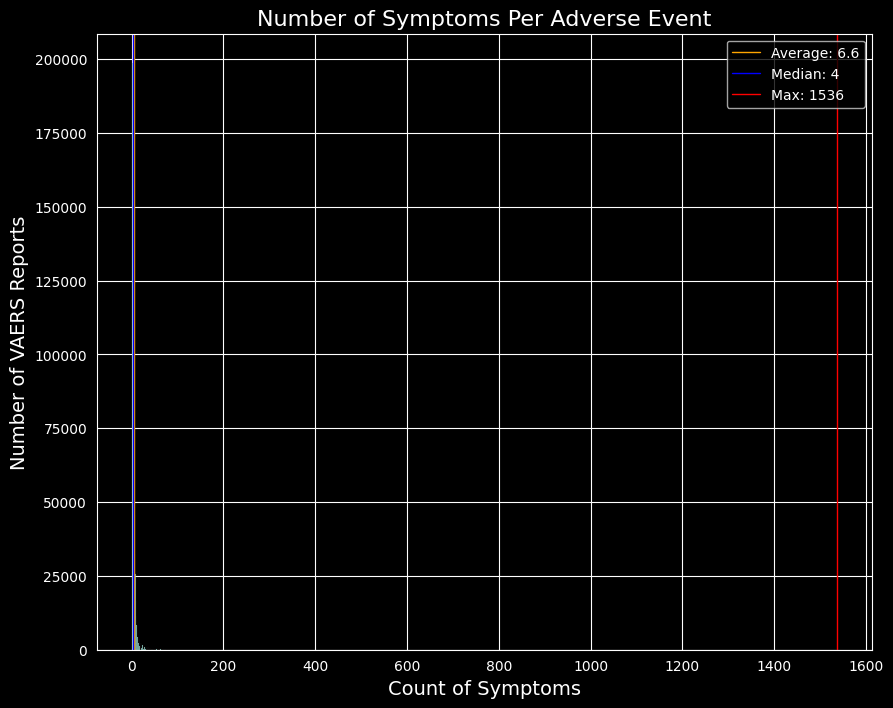

In [51]:
# group df_symptoms_VAERS_merged by VAERS_ID
num_symptoms_per_ID = df_symptoms_VAERS_merged.groupby(by=["VAERS_ID"]).agg(report_count=("symptom", 'count'))

# plot distribution - symptom counts
fig, ax = plt.subplots(figsize=(10, 8))
sns.histplot(data=num_symptoms_per_ID, x="report_count", legend=True)

plt.axvline(x=num_symptoms_per_ID.report_count.mean(),
            color='orange', lw=1.0, label='Average: 6.6')
plt.axvline(x=num_symptoms_per_ID.report_count.median(), color = 'blue', lw=1.0, label='Median: 4')
plt.axvline(x=num_symptoms_per_ID.report_count.max(), color = 'red', lw=1.0, label='Max: 1536')

plt.legend(loc='upper right')

ax.set_xlabel('Count of Symptoms', fontsize=14)
ax.set_ylabel('Number of VAERS Reports', fontsize=14)
ax.set_title('Number of Symptoms Per Adverse Event', fontsize=16)

In [52]:
# summary statistics for number of symptoms per ID
num_symptoms_per_ID.describe()

,report_count
count,790274.000000
mean,4.365936
std,7.739910
min,1.000000
25%,1.000000
50%,3.000000
75%,5.000000
max,1536.000000


# Additional Visualizations - Overall

## Common Symptoms - Ages 0-50

In [58]:
df_symptoms_VAERS_merged.head()

,VAERS_ID,symptom,symptom_version,symptom_dict,VAX_TYPE_x,VAX_MANU_x,VAX_LOT_x,VAX_DOSE_SERIES_x,VAX_ROUTE_x,VAX_SITE_x,...,BIRTH_DEFECT,OFC_VISIT,ER_ED_VISIT,VAX_TYPE_y,VAX_MANU_y,VAX_LOT_y,VAX_DOSE_SERIES_y,VAX_ROUTE_y,VAX_SITE_y,VAX_NAME_y
0,902418,Hypoaesthesia,24.0,"{'SYMPTOM1': 'Hypoaesthesia', 'SYMPTOMVERSION1...",COVID19,PFIZER\BIONTECH,EH9899,1.0,IM,LA,...,N,N,N,COVID19,PFIZER\BIONTECH,EH9899,1.0,IM,LA,PFIZER-BIONTECH
1,902440,Headache,23.1,"{'SYMPTOM1': 'Headache', 'SYMPTOMVERSION1': 23.1}",COVID19,PFIZER\BIONTECH,EH9899,1.0,SYR,LA,...,N,N,N,COVID19,PFIZER\BIONTECH,EH9899,1.0,SYR,LA,PFIZER-BIONTECH
2,902446,Erythema,23.1,"{'SYMPTOM1': 'Erythema', 'SYMPTOMVERSION1': 23.1}",COVID19,PFIZER\BIONTECH,EH9899,1.0,IM,RA,...,N,N,N,COVID19,PFIZER\BIONTECH,EH9899,1.0,IM,RA,PFIZER-BIONTECH
3,902464,Dizziness,23.1,"{'SYMPTOM1': 'Dizziness', 'SYMPTOMVERSION1': 2...",COVID19,PFIZER\BIONTECH,EH9899,NaN,IM,LA,...,N,N,Y,COVID19,PFIZER\BIONTECH,EH9899,NaN,IM,LA,PFIZER-BIONTECH
4,902465,Dysgeusia,23.1,"{'SYMPTOM1': 'Dysgeusia', 'SYMPTOMVERSION1': 2...",COVID19,PFIZER\BIONTECH,EH9899,1.0,IM,RA,...,N,N,N,COVID19,PFIZER\BIONTECH,EH9899,1.0,IM,RA,PFIZER-BIONTECH


In [90]:
symptoms_ages_0_50 = df_symptoms_VAERS_merged[df_symptoms_VAERS_merged['AGE_YRS'] < 51]

In [64]:
symptoms_ages_0_50.describe().T

,count,mean,min,25%,50%,75%,max,std
VAERS_ID,1649527.0,1575772.505544,902440.0,1156101.0,1446819.0,1935107.0,2776295.0,507232.176882
symptom_version,1649527.0,24.164066,23.1,24.0,24.0,24.1,27.0,0.572889
VAX_DOSE_SERIES_x,1478311.0,1.628818,1.0,1.0,1.0,2.0,7.0,0.755607
RECVDATE,1649527,2021-08-18 12:52:03.260425216,2020-12-15 00:00:00,2021-03-23 00:00:00,2021-06-20 00:00:00,2021-11-21 00:00:00,2024-06-27 00:00:00,NaN
AGE_YRS,1649527.0,34.190561,0.08,27.0,36.0,43.0,50.0,11.075193
RPT_DATE,1083,2021-07-18 21:16:27.257616896,2020-12-16 00:00:00,2021-01-22 00:00:00,2021-05-08 00:00:00,2021-09-18 00:00:00,2024-04-06 00:00:00,NaN
DATEDIED,4178,2021-07-25 18:23:36.562948864,2020-12-26 00:00:00,2021-04-08 00:00:00,2021-05-30 00:00:00,2021-10-13 00:00:00,2023-12-13 00:00:00,NaN
HOSPDAYS,96643.0,3.482963,1.0,2.0,3.0,4.0,14.0,2.670177
VAX_DATE,1635144,2021-06-17 08:23:01.855542528,2020-01-02 00:00:00,2021-02-13 00:00:00,2021-04-20 00:00:00,2021-09-02 00:00:00,2024-06-27 00:00:00,NaN
ONSET_DATE,1610048,2021-06-18 06:49:38.618278400,2020-01-01 00:00:00,2021-02-16 00:00:00,2021-04-21 00:00:00,2021-09-03 00:00:00,2024-06-27 00:00:00,NaN


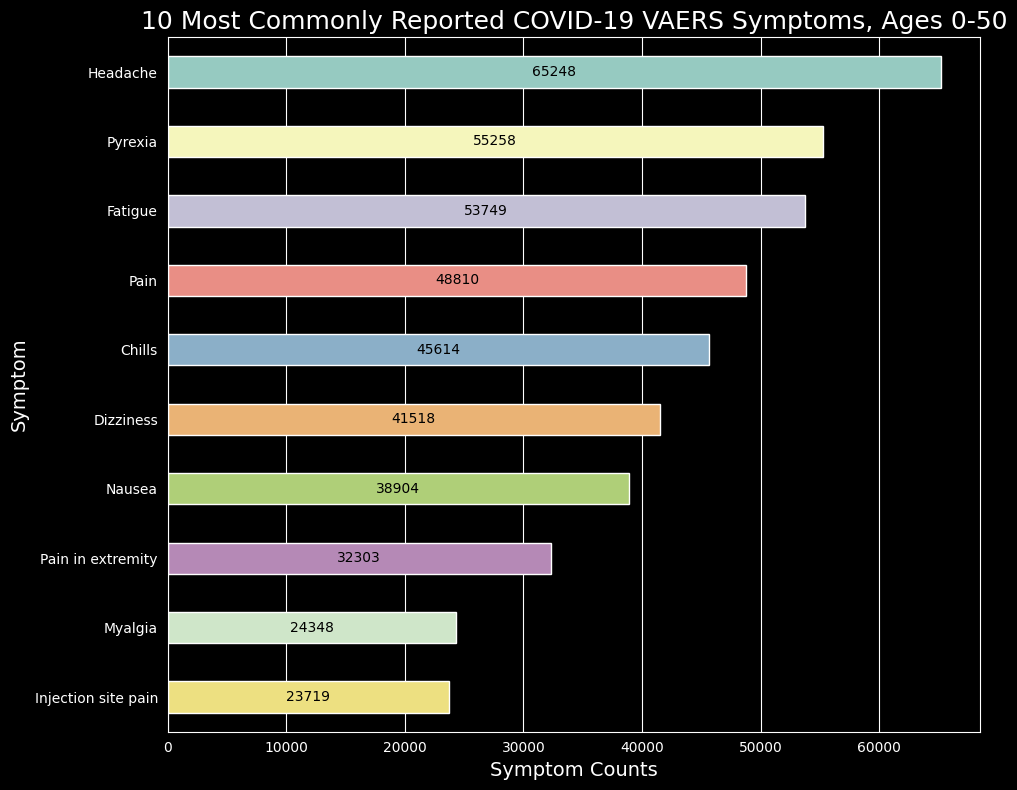

In [92]:
# plot 10 most common symptoms overall ages 0-50
symptom_counts3 = symptoms_ages_0_50['symptom'].value_counts()
df_symptom_counts3 = symptom_counts3.to_frame()
df_symptom_counts3[0:10]

# bar chart
fig, ax = plt.subplots(figsize=(10, 8))
most_common_symptoms_0_50 = sns.barplot(data=df_symptom_counts3[0:10], x="count", y="symptom", hue='symptom', width=0.5, gap=0.1)

for container in ax.containers:
    ax.bar_label(container, fontsize=10, label_type='center', color='black')

ax.set_xlabel('Symptom Counts', fontsize=14)
ax.set_ylabel('Symptom', fontsize=14)
ax.set_title('10 Most Commonly Reported COVID-19 VAERS Symptoms, Ages 0-50', fontsize=18)

plt.tight_layout()
plt.show()

fig.savefig('visualizations/overall/most_common_symptoms_ages0_50.png')

## Common Symptoms - Ages 51-100

In [67]:
symptoms_ages_51_up = df_symptoms_VAERS_merged[df_symptoms_VAERS_merged['AGE_YRS'] >= 51]

In [102]:
print("Shape of df_symptoms_VAERS_merged: ", df_symptoms_VAERS_merged.shape)
print("Shape of symptoms_ages_0_50: ", symptoms_ages_0_50.shape)
print("Shape of symptoms_ages_51_up: ", symptoms_ages_51_up.shape)

Shape of df_symptoms_VAERS_merged:  (3450286, 42)
Shape of symptoms_ages_0_50:  (1649527, 42)
Shape of symptoms_ages_51_up:  (1617062, 42)


In [98]:
symptoms_ages_51_up.describe().T

,count,mean,min,25%,50%,75%,max,std
VAERS_ID,1617062.0,1626447.112892,902418.0,1141641.0,1544083.0,2025092.0,2776283.0,538510.899088
symptom_version,1617062.0,24.233113,23.1,24.0,24.0,24.1,27.0,0.638085
VAX_DOSE_SERIES_x,1424711.0,1.817321,1.0,1.0,2.0,2.0,7.0,1.002428
RECVDATE,1617062,2021-09-14 02:50:38.995907840,2020-12-15 00:00:00,2021-03-21 00:00:00,2021-07-20 00:00:00,2021-12-14 00:00:00,2024-06-27 00:00:00,NaN
AGE_YRS,1617062.0,64.747076,50.0,56.0,64.0,71.0,110.0,10.112756
RPT_DATE,1952,2021-05-15 13:36:38.360655616,2020-01-13 00:00:00,2021-01-12 00:00:00,2021-02-05 00:00:00,2021-09-15 00:00:00,2024-05-21 00:00:00,NaN
DATEDIED,36808,2021-08-11 05:29:45.524886272,2020-01-10 00:00:00,2021-03-01 00:00:00,2021-04-29 00:00:00,2021-11-14 00:00:00,2024-06-22 00:00:00,NaN
HOSPDAYS,141151.0,4.298864,1.0,2.0,3.0,6.0,14.0,3.240915
VAX_DATE,1592100,2021-06-20 22:03:26.869417984,2020-01-01 00:00:00,2021-02-12 00:00:00,2021-03-26 00:00:00,2021-09-11 00:00:00,2024-06-27 00:00:00,NaN
ONSET_DATE,1534538,2021-06-23 00:35:22.138649600,2020-01-01 00:00:00,2021-02-15 00:00:00,2021-03-29 00:00:00,2021-09-14 00:00:00,2024-06-27 00:00:00,NaN


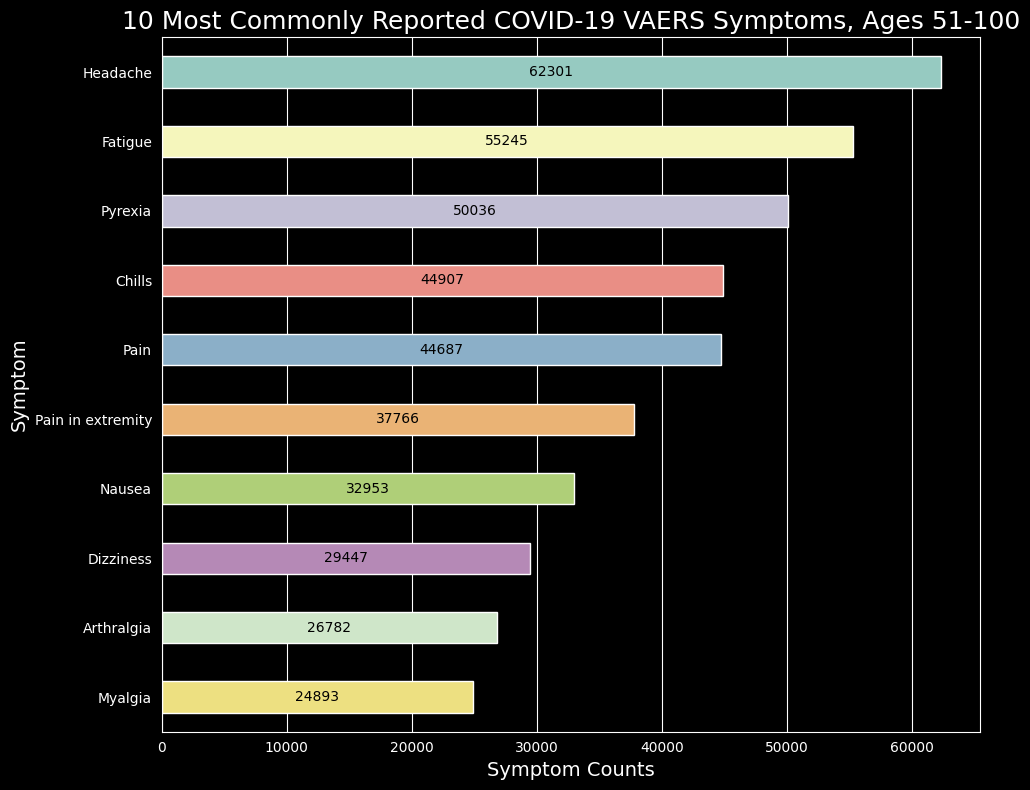

In [103]:
# plot most common symptoms overall ages 51-100
symptom_counts4 = symptoms_ages_51_up['symptom'].value_counts()
df_symptom_counts4 = symptom_counts4.to_frame()
df_symptom_counts4[0:10]

# bar chart
fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(data=df_symptom_counts4[0:10], x="count", y="symptom", hue='symptom', width=0.5, gap=0.1)

for container in ax.containers:
    ax.bar_label(container, fontsize=10, label_type='center', color='black')

ax.set_xlabel('Symptom Counts', fontsize=14)
ax.set_ylabel('Symptom', fontsize=14)
ax.set_title('10 Most Commonly Reported COVID-19 VAERS Symptoms, Ages 51-100', fontsize=18)

plt.tight_layout()
plt.show()

fig.savefig('visualizations/overall/most_common_symptoms_ages51_up')

# Additional Visualizations - Filtered by Pfizer

## Pfizer - frequency of reports by age

In [74]:
df_VAERS_filtered.head()

,VAERS_ID,RECVDATE,STATE,AGE_YRS,SEX,RPT_DATE,DIED,DATEDIED,L_THREAT,ER_VISIT,...,BIRTH_DEFECT,OFC_VISIT,ER_ED_VISIT,VAX_TYPE,VAX_MANU,VAX_LOT,VAX_DOSE_SERIES,VAX_ROUTE,VAX_SITE,VAX_NAME
0,902418,2020-12-15,NJ,56.0,F,NaT,N,NaT,N,N,...,N,N,N,COVID19,PFIZER\BIONTECH,EH9899,1.0,IM,LA,PFIZER-BIONTECH
1,902440,2020-12-15,AZ,35.0,F,NaT,N,NaT,N,N,...,N,N,N,COVID19,PFIZER\BIONTECH,EH9899,1.0,SYR,LA,PFIZER-BIONTECH
2,902446,2020-12-15,WV,55.0,F,NaT,N,NaT,N,N,...,N,N,N,COVID19,PFIZER\BIONTECH,EH9899,1.0,IM,RA,PFIZER-BIONTECH
3,902464,2020-12-15,LA,42.0,M,NaT,N,NaT,N,N,...,N,N,Y,COVID19,PFIZER\BIONTECH,EH9899,NaN,IM,LA,PFIZER-BIONTECH
4,902465,2020-12-15,AR,60.0,F,NaT,N,NaT,N,N,...,N,N,N,COVID19,PFIZER\BIONTECH,EH9899,1.0,IM,RA,PFIZER-BIONTECH


In [54]:
# filter df_VAERS_filtered for Pfizer
VAERS_Pfizer = df_VAERS_filtered[df_VAERS_filtered['VAX_MANU'] == 'PFIZER\\BIONTECH']
print(VAERS_Pfizer['VAX_MANU'].unique().tolist())

['PFIZER\\BIONTECH']


In [55]:
print(df_VAERS_filtered.shape)
print(VAERS_Pfizer.shape)

(810055, 32)
(409340, 32)


In [56]:
# summary stats
VAERS_Pfizer.describe().T

,count,mean,min,25%,50%,75%,max,std
VAERS_ID,409340.0,1681980.750845,902418.0,1223772.0,1648435.5,2107617.25,2776312.0,535420.693228
RECVDATE,409340,2021-10-13 18:27:03.772903168,2020-12-15 00:00:00,2021-04-13 00:00:00,2021-08-23 00:00:00,2022-01-26 00:00:00,2024-06-27 00:00:00,NaN
AGE_YRS,364313.0,45.182027,0.08,30.0,46.0,61.0,107.0,20.71793
RPT_DATE,514,2021-07-01 04:48:33.618677760,2020-12-16 00:00:00,2020-12-23 00:00:00,2021-04-21 00:00:00,2021-10-05 00:00:00,2024-05-21 00:00:00,NaN
DATEDIED,2982,2021-07-14 08:53:07.122736384,2020-01-10 00:00:00,2021-02-22 00:00:00,2021-04-11 12:00:00,2021-10-10 00:00:00,2024-05-15 00:00:00,NaN
HOSPDAYS,12480.0,3.728365,1.0,2.0,3.0,5.0,14.0,2.855709
VAX_DATE,380077,2021-08-01 15:12:50.821701888,2020-01-01 00:00:00,2021-03-05 00:00:00,2021-05-03 00:00:00,2021-11-02 00:00:00,2024-06-27 00:00:00,NaN
ONSET_DATE,362171,2021-08-01 08:36:26.494225152,2020-01-01 00:00:00,2021-03-05 00:00:00,2021-05-04 00:00:00,2021-11-01 00:00:00,2024-06-27 00:00:00,NaN
NUMDAYS,344471.0,1.838796,0.0,0.0,0.0,1.0,20.0,3.736783
FORM_VERS,409340.0,1.998688,1.0,2.0,2.0,2.0,2.0,0.036196


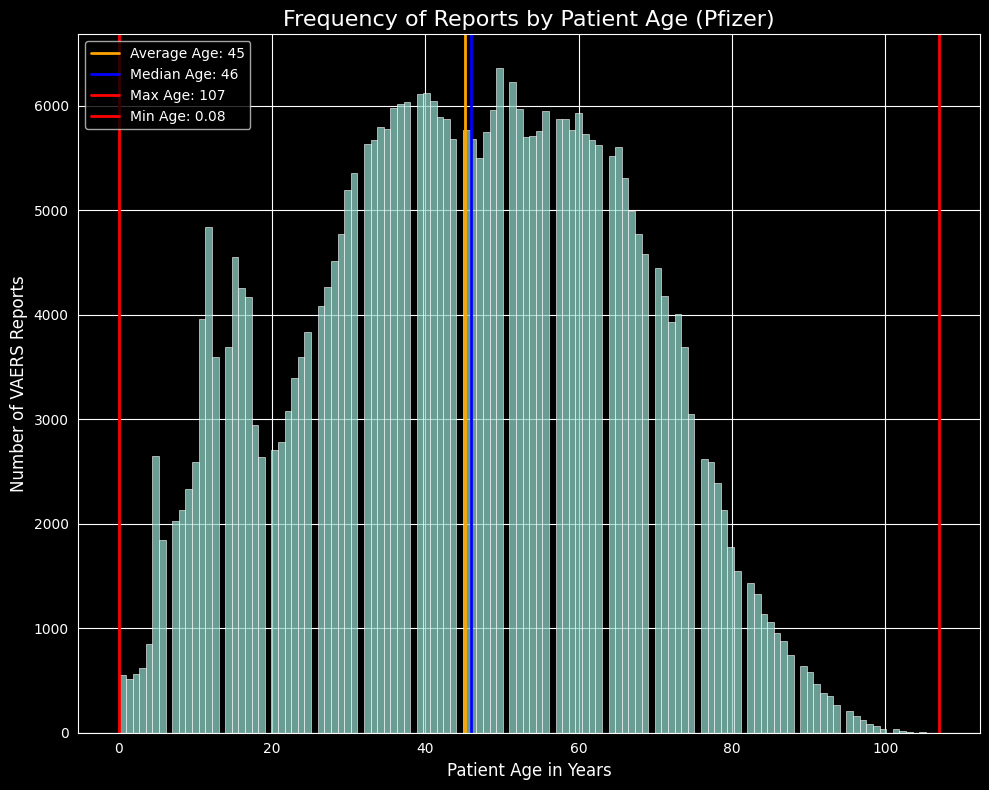

In [93]:
# plot distribution - patient age
fig, ax = plt.subplots(figsize=(10, 8))
patient_age_overall = sns.histplot(data=VAERS_Pfizer, x="AGE_YRS", legend=True)

plt.axvline(x=VAERS_Pfizer.AGE_YRS.mean(),
            color='orange', lw=2.0, label='Average Age: 45')
plt.axvline(x=VAERS_Pfizer.AGE_YRS.median(), color = 'blue', lw=2.0, label='Median Age: 46')
plt.axvline(x=VAERS_Pfizer.AGE_YRS.max(), color = 'red', lw=2.0, label='Max Age: 107')
plt.axvline(x=VAERS_Pfizer.AGE_YRS.min(), color = 'red', lw=2.0, label='Min Age: 0.08')

plt.legend(loc='upper left')

ax.set_xlabel('Patient Age in Years', fontsize=12)
ax.set_ylabel('Number of VAERS Reports', fontsize=12)
ax.set_title('Frequency of Reports by Patient Age (Pfizer)', fontsize=16)

plt.tight_layout()
plt.show()

fig.savefig('visualizations/pfizer/frequency_reports_age_PFIZER.png')

## Pfizer - frequency of reports by sex

In [63]:
print(df_VAERS_filtered.shape)
print(VAERS_Pfizer.shape)
VAERS_Pfizer_F = VAERS_Pfizer[VAERS_Pfizer['SEX'] == 'F']
print(VAERS_Pfizer_F.shape)
VAERS_Pfizer_M = VAERS_Pfizer[VAERS_Pfizer['SEX'] == 'M']
print(VAERS_Pfizer_M.shape)

(810055, 32)
(409340, 32)
(265768, 32)
(129609, 32)


In [66]:
# create groupby object
VAERS_Pfizer_grouped = VAERS_Pfizer.groupby(by=['SEX']).agg(report_count=("VAERS_ID", 'count'))

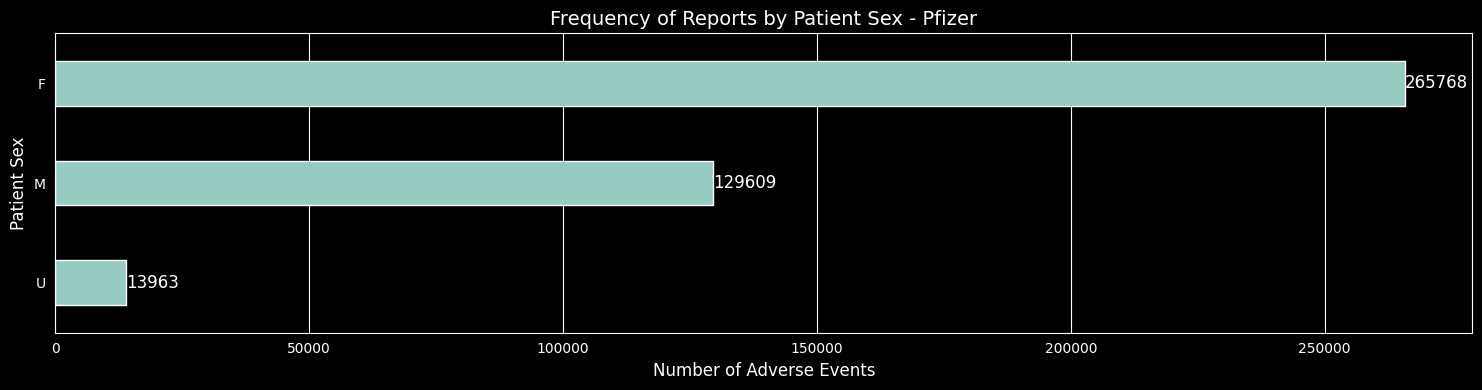

In [94]:
# bar chart
fig, ax = plt.subplots(figsize=(15, 4))
sns.barplot(data=VAERS_Pfizer_grouped, x='report_count', y='SEX', legend=False, width=0.5, gap=0.1) # seaborn

for container in ax.containers:
    ax.bar_label(container, fontsize=12)

ax.set_xlabel('Number of Adverse Events', fontsize=12)
ax.set_ylabel('Patient Sex', fontsize=12)
ax.set_title('Frequency of Reports by Patient Sex - Pfizer', fontsize=14)

fig.savefig('visualizations/pfizer/frequency_reports_sex_PFIZER.png')

plt.tight_layout()
plt.show()

## Pfizer - Most Common Symptoms

In [117]:
# merge df_symptom_vax_Pfizer with VAERS_Pfizer
VAERS_Pfizer_symptoms = pd.merge(VAERS_Pfizer, df_symptom_vax_Pfizer, how='left', on='VAERS_ID')
VAERS_Pfizer_symptoms.head()

,VAERS_ID,RECVDATE,STATE,AGE_YRS,SEX,RPT_DATE,DIED,DATEDIED,L_THREAT,ER_VISIT,...,symptom,symptom_version,symptom_dict,VAX_TYPE_y,VAX_MANU_y,VAX_LOT_y,VAX_DOSE_SERIES_y,VAX_ROUTE_y,VAX_SITE_y,VAX_NAME_y
0,902418,2020-12-15,NJ,56.0,F,NaT,N,NaT,N,N,...,Hypoaesthesia,24.0,"{'SYMPTOM1': 'Hypoaesthesia', 'SYMPTOMVERSION1...",COVID19,PFIZER\BIONTECH,EH9899,1.0,IM,LA,PFIZER-BIONTECH
1,902418,2020-12-15,NJ,56.0,F,NaT,N,NaT,N,N,...,Injection site hypoaesthesia,24.0,"{'SYMPTOM2': 'Injection site hypoaesthesia', '...",COVID19,PFIZER\BIONTECH,EH9899,1.0,IM,LA,PFIZER-BIONTECH
2,902440,2020-12-15,AZ,35.0,F,NaT,N,NaT,N,N,...,Headache,23.1,"{'SYMPTOM1': 'Headache', 'SYMPTOMVERSION1': 23.1}",COVID19,PFIZER\BIONTECH,EH9899,1.0,SYR,LA,PFIZER-BIONTECH
3,902446,2020-12-15,WV,55.0,F,NaT,N,NaT,N,N,...,Erythema,23.1,"{'SYMPTOM1': 'Erythema', 'SYMPTOMVERSION1': 23.1}",COVID19,PFIZER\BIONTECH,EH9899,1.0,IM,RA,PFIZER-BIONTECH
4,902446,2020-12-15,WV,55.0,F,NaT,N,NaT,N,N,...,Feeling hot,23.1,"{'SYMPTOM2': 'Feeling hot', 'SYMPTOMVERSION2':...",COVID19,PFIZER\BIONTECH,EH9899,1.0,IM,RA,PFIZER-BIONTECH


### Most Common Symptoms - 0-50

In [120]:
VAERS_Pfizer_0_50 = VAERS_Pfizer_symptoms[VAERS_Pfizer_symptoms['AGE_YRS'] < 51]
VAERS_Pfizer_0_50.describe().T

,count,mean,min,25%,50%,75%,max,std
VAERS_ID,906745.0,1608438.919831,902440.0,1223558.0,1512952.0,1944109.0,2776127.0,488490.701101
RECVDATE,906745,2021-09-05 07:59:02.320276480,2020-12-15 00:00:00,2021-04-14 00:00:00,2021-07-23 00:00:00,2021-12-04 00:00:00,2024-06-26 00:00:00,NaN
AGE_YRS,906745.0,32.820566,0.08,25.0,35.0,43.0,50.0,11.941682
RPT_DATE,671,2021-08-01 15:22:48.107302656,2020-12-16 00:00:00,2021-01-28 00:00:00,2021-06-11 00:00:00,2021-10-04 12:00:00,2024-04-06 00:00:00,NaN
DATEDIED,2283,2021-07-31 02:19:23.731931392,2020-12-26 00:00:00,2021-04-13 00:00:00,2021-05-31 00:00:00,2021-10-18 00:00:00,2023-12-13 00:00:00,NaN
HOSPDAYS,64320.0,3.478016,1.0,2.0,3.0,4.0,14.0,2.654873
VAX_DATE,900310,2021-07-04 16:58:24.840777728,2020-01-02 00:00:00,2021-03-13 00:00:00,2021-05-06 00:00:00,2021-09-24 00:00:00,2024-06-25 00:00:00,NaN
ONSET_DATE,885558,2021-07-04 17:04:16.963405824,2020-01-01 00:00:00,2021-03-14 00:00:00,2021-05-07 00:00:00,2021-09-24 00:00:00,2024-06-25 00:00:00,NaN
NUMDAYS,861407.0,2.078246,0.0,0.0,1.0,2.0,20.0,3.888318
FORM_VERS,906745.0,1.999218,1.0,2.0,2.0,2.0,2.0,0.027952


In [121]:
symptom_counts5 = VAERS_Pfizer_0_50['symptom'].value_counts()
df_symptom_counts5 = symptom_counts5.to_frame()
df_symptom_counts5[0:10]

,count
symptom,
Headache,34931
Fatigue,29050
Pyrexia,27456
Pain,25596
Dizziness,25442
Chills,22369
Nausea,21228
Pain in extremity,16278
Product storage error,12292


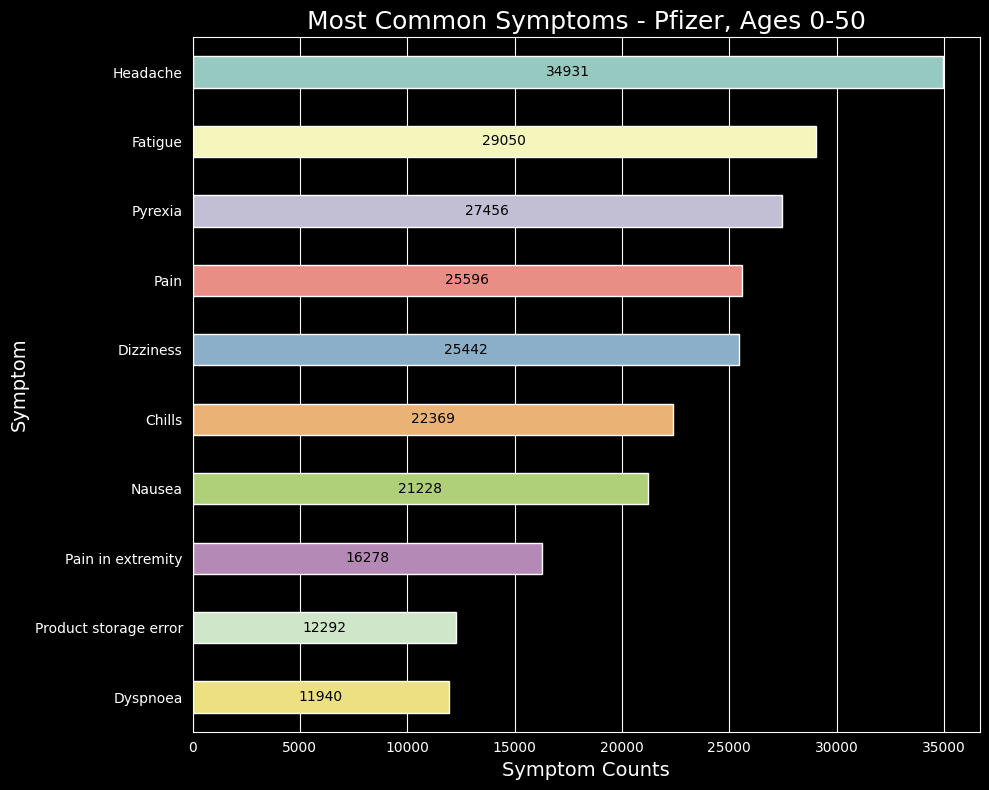

In [122]:
# plot 10 most common symptoms overall ages 0-50 - Pfizer only

# bar chart
fig, ax = plt.subplots(figsize=(10, 8))
most_common_symptoms_0_50_Pfizer = sns.barplot(data=df_symptom_counts5[0:10], x="count", y="symptom", hue='symptom', width=0.5, gap=0.1)

for container in ax.containers:
    ax.bar_label(container, fontsize=10, label_type='center', color='black')

ax.set_xlabel('Symptom Counts', fontsize=14)
ax.set_ylabel('Symptom', fontsize=14)
ax.set_title('Most Common Symptoms - Pfizer, Ages 0-50', fontsize=18)

plt.tight_layout()
plt.show()

fig.savefig('visualizations/pfizer/most_common_symptoms_Pfizer_0_50.png')

### Most Common Symptoms 51-100

In [123]:
VAERS_Pfizer_51_up = VAERS_Pfizer_symptoms[VAERS_Pfizer_symptoms['AGE_YRS'] >= 51]
VAERS_Pfizer_51_up.describe().T

,count,mean,min,25%,50%,75%,max,std
VAERS_ID,704348.0,1656614.394559,902418.0,1173274.0,1569260.0,2075846.0,2776253.0,534184.096204
RECVDATE,704348,2021-10-01 11:01:10.512871680,2020-12-15 00:00:00,2021-04-02 00:00:00,2021-08-03 00:00:00,2022-01-10 00:00:00,2024-06-27 00:00:00,NaN
AGE_YRS,704348.0,64.743669,51.0,57.0,63.0,71.0,107.0,9.924773
RPT_DATE,691,2021-06-14 11:54:47.409551616,2020-12-16 00:00:00,2020-12-30 00:00:00,2021-02-13 00:00:00,2021-10-18 00:00:00,2024-05-21 00:00:00,NaN
DATEDIED,18411,2021-08-09 14:40:36.760632576,2020-01-10 00:00:00,2021-02-24 00:00:00,2021-04-25 00:00:00,2021-11-09 00:00:00,2024-05-15 00:00:00,NaN
HOSPDAYS,74076.0,4.40071,1.0,2.0,3.0,6.0,14.0,3.358786
VAX_DATE,695586,2021-07-09 00:47:41.716020992,2020-01-01 00:00:00,2021-02-22 00:00:00,2021-04-06 00:00:00,2021-10-04 00:00:00,2024-06-27 00:00:00,NaN
ONSET_DATE,668710,2021-07-07 16:37:20.698658304,2020-01-01 00:00:00,2021-02-24 00:00:00,2021-04-07 00:00:00,2021-10-03 00:00:00,2024-06-27 00:00:00,NaN
NUMDAYS,630921.0,2.90909,0.0,0.0,1.0,3.0,20.0,4.650981
FORM_VERS,704348.0,1.999009,1.0,2.0,2.0,2.0,2.0,0.031464


In [124]:
symptom_counts6 = VAERS_Pfizer_51_up['symptom'].value_counts()
df_symptom_counts6 = symptom_counts6.to_frame()
df_symptom_counts6[0:10]

,count
symptom,
Headache,25735
Fatigue,22939
Pain,18741
Pyrexia,18244
Chills,16699
Pain in extremity,15457
Nausea,13818
Dizziness,13769
Arthralgia,11556


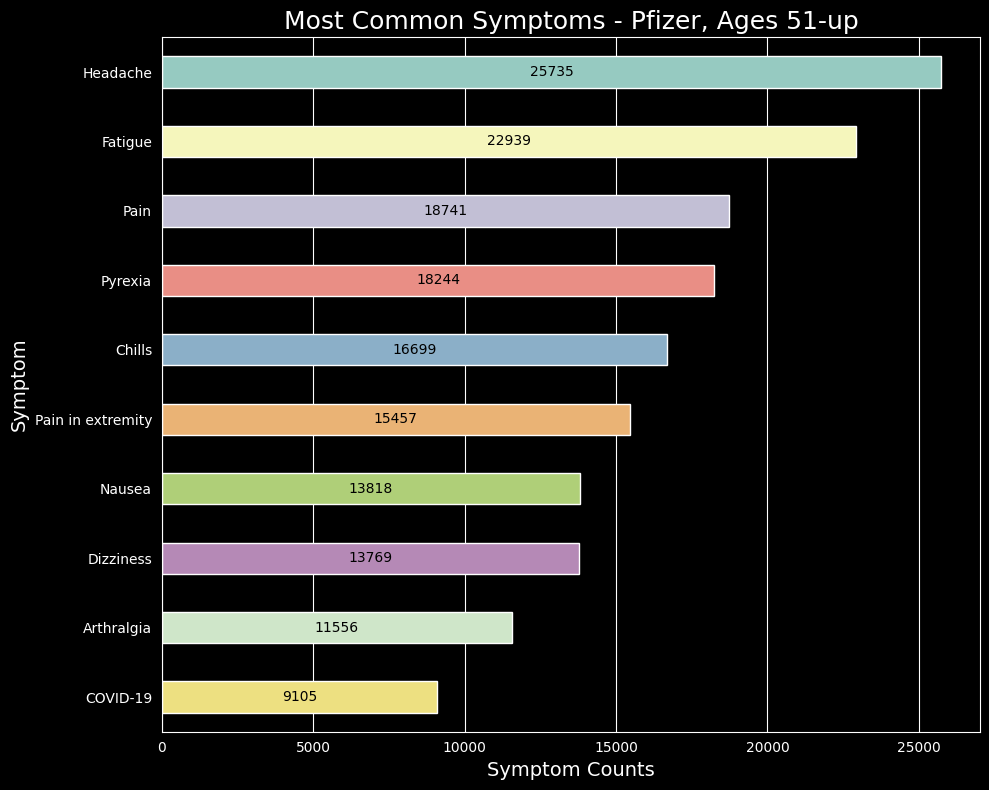

In [125]:
# plot 10 most common symptoms overall ages 51-up - Pfizer only

# bar chart
fig, ax = plt.subplots(figsize=(10, 8))
most_common_symptoms_51_up_Pfizer = sns.barplot(data=df_symptom_counts6[0:10], x="count", y="symptom", hue='symptom', width=0.5, gap=0.1)

for container in ax.containers:
    ax.bar_label(container, fontsize=10, label_type='center', color='black')

ax.set_xlabel('Symptom Counts', fontsize=14)
ax.set_ylabel('Symptom', fontsize=14)
ax.set_title('Most Common Symptoms - Pfizer, Ages 51-up', fontsize=18)

plt.tight_layout()
plt.show()

fig.savefig('visualizations/pfizer/most_common_symptoms_Pfizer_51_up.png')

### Most Common Symptoms Female

In [132]:
# filter by sex
df_symptoms_F_Pfizer = df_symptoms_VAERS_merged[(df_symptoms_VAERS_merged['SEX'] == 'F') & (df_symptoms_VAERS_merged['VAX_MANU_x'] == "PFIZER\\BIONTECH")]
df_symptoms_M_Pfizer = df_symptoms_VAERS_merged[(df_symptoms_VAERS_merged['SEX'] == 'M') & (df_symptoms_VAERS_merged['VAX_MANU_x'] == "PFIZER\\BIONTECH")]
df_symptoms_U_Pfizer = df_symptoms_VAERS_merged[(df_symptoms_VAERS_merged['SEX'] == 'U') & (df_symptoms_VAERS_merged['VAX_MANU_x'] == "PFIZER\\BIONTECH")]

In [135]:
# get counts of 10 most common symptoms by sex
symptom_counts_F_Pfizer = df_symptoms_F_Pfizer['symptom'].value_counts()
df_symptom_counts_F_Pfizer = symptom_counts_F_Pfizer.to_frame()
symptom_counts_M_Pfizer = df_symptoms_M_Pfizer['symptom'].value_counts()
df_symptom_counts_M_Pfizer = symptom_counts_M_Pfizer.to_frame()
symptom_counts_U_Pfizer = df_symptoms_U_Pfizer['symptom'].value_counts()
df_symptom_counts_U_Pfizer = symptom_counts_U_Pfizer.to_frame()

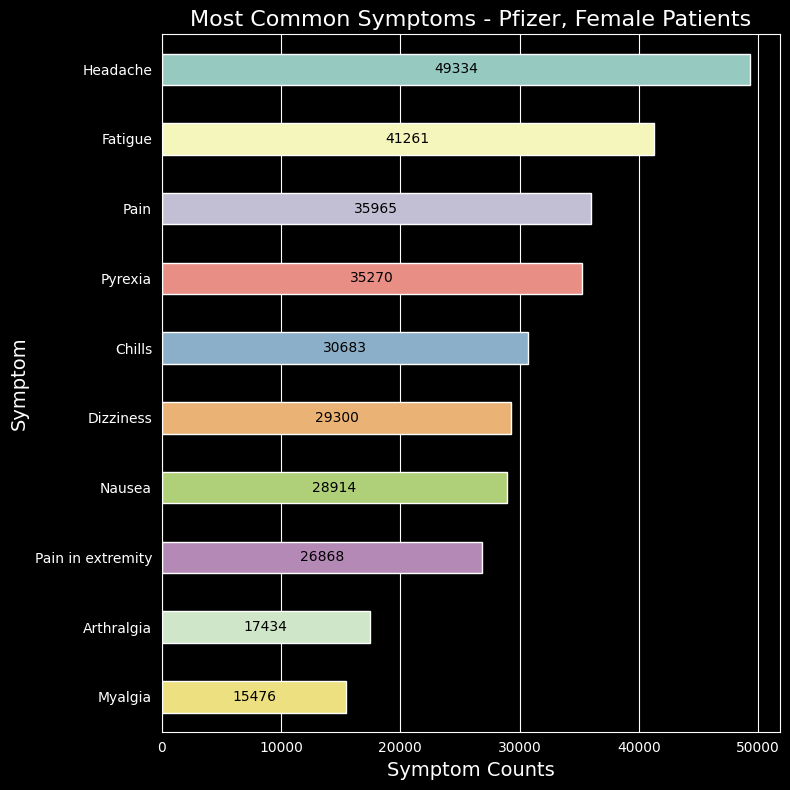

In [136]:
# plot most common symptoms by sex - F

# bar chart
fig, ax = plt.subplots(figsize=(8, 8))
sns.barplot(data=df_symptom_counts_F_Pfizer[0:10], x="count", y="symptom", hue='symptom', width=0.5, gap=0.1)

for container in ax.containers:
    ax.bar_label(container, fontsize=10, label_type='center', color='black')
ax.set_xlabel('Symptom Counts', fontsize=14)
ax.set_ylabel('Symptom', fontsize=14)
ax.set_title('Most Common Symptoms - Pfizer, Female Patients', fontsize=16)

plt.tight_layout()
plt.show()

fig.savefig('visualizations/pfizer/most_common_symptoms_female_Pfizer.png')

### Most Common Symptoms Male

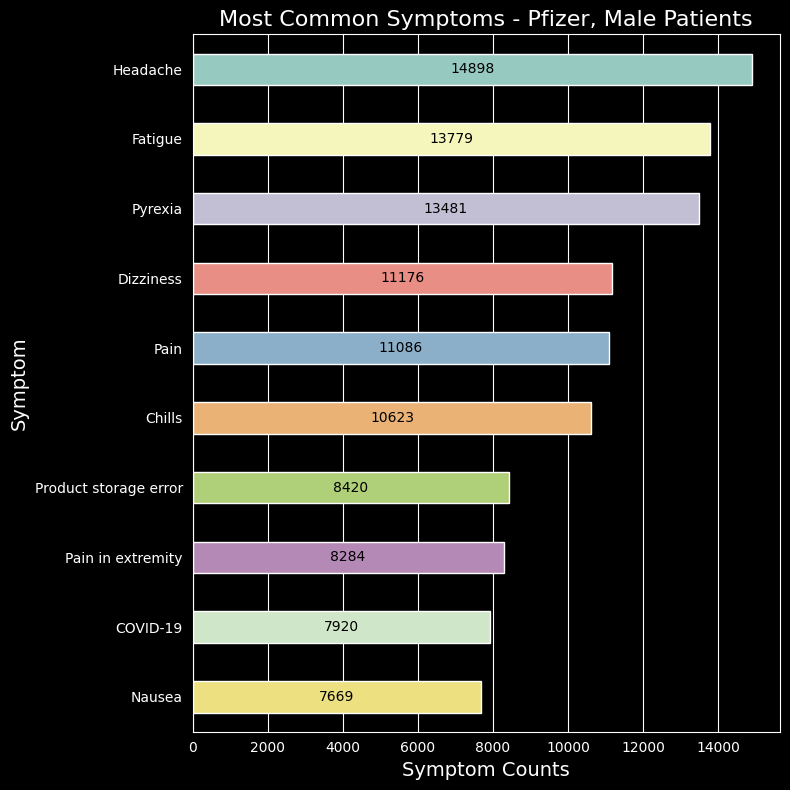

In [137]:
# plot most common symptoms by sex - M

# bar chart
fig, ax = plt.subplots(figsize=(8, 8))
sns.barplot(data=df_symptom_counts_M_Pfizer[0:10], x="count", y="symptom", hue='symptom', width=0.5, gap=0.1)

for container in ax.containers:
    ax.bar_label(container, fontsize=10, label_type='center', color='black')
ax.set_xlabel('Symptom Counts', fontsize=14)
ax.set_ylabel('Symptom', fontsize=14)
ax.set_title('Most Common Symptoms - Pfizer, Male Patients', fontsize=16)

plt.tight_layout()
plt.show()

fig.savefig('visualizations/pfizer/most_common_symptoms_male_Pfizer.png')

# Additional Visualizations - Filtered by Moderna

## Moderna - Frequency of reports by age

In [78]:
# filter df_VAERS_filtered for Moderna
VAERS_Moderna = df_VAERS_filtered[df_VAERS_filtered['VAX_MANU'] == 'MODERNA']
print(VAERS_Moderna['VAX_MANU'].unique().tolist())

['MODERNA']


In [140]:
VAERS_Moderna.describe().T

,count,mean,min,25%,50%,75%,max,std
VAERS_ID,400715.0,1627977.313619,905142.0,1133731.5,1562073.0,2036362.5,2776336.0,548487.452335
RECVDATE,400715,2021-09-12 16:22:05.526621184,2020-12-21 00:00:00,2021-03-15 00:00:00,2021-08-11 00:00:00,2021-12-10 00:00:00,2024-06-28 00:00:00,NaN
AGE_YRS,359573.0,51.789292,0.08,37.0,53.0,67.0,110.0,19.008419
RPT_DATE,572,2021-06-01 03:18:52.867131904,2020-01-13 00:00:00,2021-01-12 00:00:00,2021-02-05 00:00:00,2021-08-16 00:00:00,2024-02-28 00:00:00,NaN
DATEDIED,3172,2021-06-26 06:15:53.341740544,2020-12-01 00:00:00,2021-02-20 00:00:00,2021-04-04 00:00:00,2021-09-03 00:00:00,2024-06-22 00:00:00,NaN
HOSPDAYS,9261.0,3.810172,1.0,2.0,3.0,5.0,14.0,2.867677
VAX_DATE,374298,2021-06-18 06:56:20.420947712,2020-01-01 00:00:00,2021-02-05 00:00:00,2021-03-26 00:00:00,2021-08-31 00:00:00,2024-06-27 00:00:00,NaN
ONSET_DATE,357464,2021-06-22 21:39:42.221426432,2020-01-01 00:00:00,2021-02-08 00:00:00,2021-03-31 00:00:00,2021-09-09 00:00:00,2024-06-27 00:00:00,NaN
NUMDAYS,347975.0,2.240305,0.0,0.0,0.0,2.0,20.0,3.905926
FORM_VERS,400715.0,1.99851,1.0,2.0,2.0,2.0,2.0,0.03857


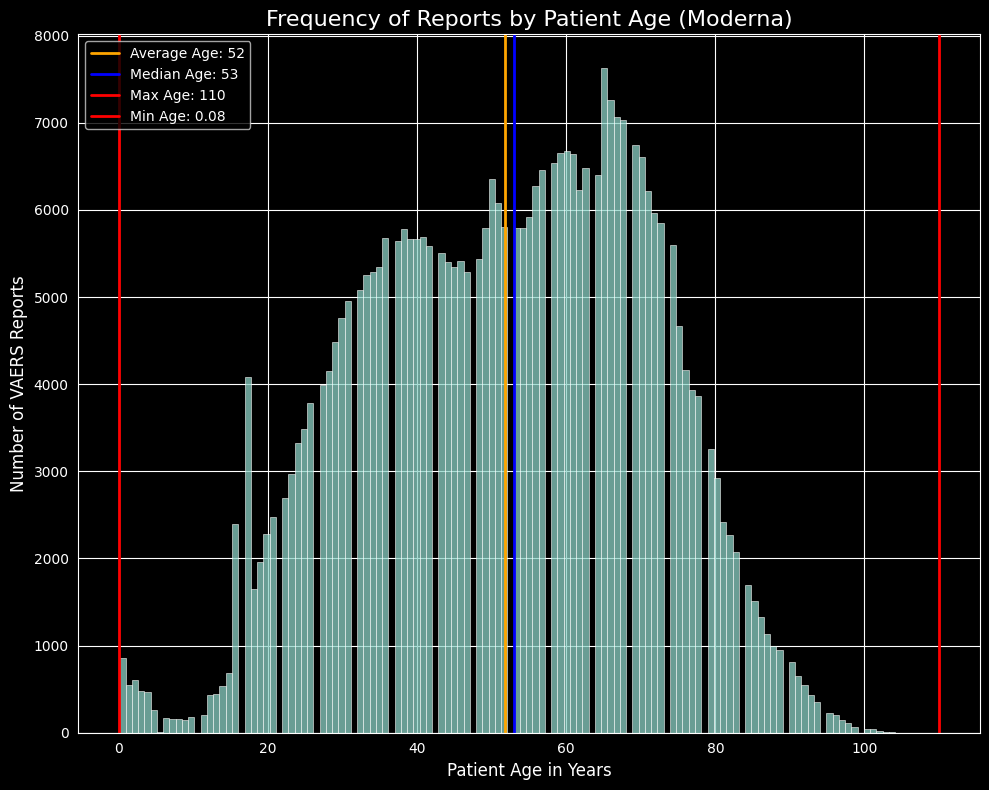

In [95]:
# plot distribution - patient age
fig, ax = plt.subplots(figsize=(10, 8))
patient_age_overall = sns.histplot(data=VAERS_Moderna, x="AGE_YRS", legend=True)

plt.axvline(x=VAERS_Moderna.AGE_YRS.mean(),
            color='orange', lw=2.0, label='Average Age: 52')
plt.axvline(x=VAERS_Moderna.AGE_YRS.median(), color = 'blue', lw=2.0, label='Median Age: 53')
plt.axvline(x=VAERS_Moderna.AGE_YRS.max(), color = 'red', lw=2.0, label='Max Age: 110')
plt.axvline(x=VAERS_Moderna.AGE_YRS.min(), color = 'red', lw=2.0, label='Min Age: 0.08')

plt.legend(loc='upper left')

ax.set_xlabel('Patient Age in Years', fontsize=12)
ax.set_ylabel('Number of VAERS Reports', fontsize=12)
ax.set_title('Frequency of Reports by Patient Age (Moderna)', fontsize=16)

plt.tight_layout()
plt.show()

fig.savefig('visualizations/moderna/frequency_reports_age_MODERNA.png')

## Moderna - frequency of reports by sex

In [79]:
# create groupby object
VAERS_Moderna_grouped = VAERS_Moderna.groupby(by=['SEX']).agg(report_count=("VAERS_ID", 'count'))

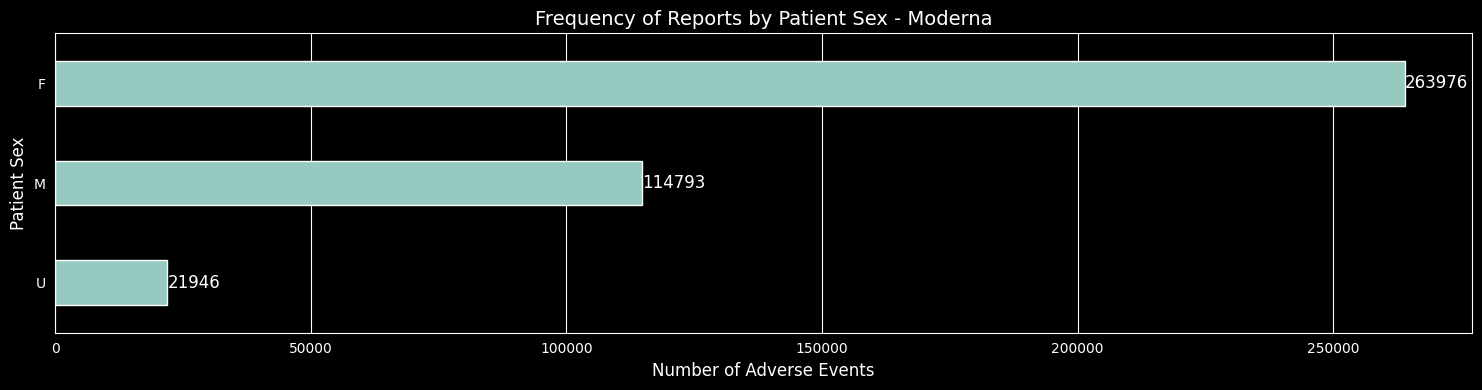

In [96]:
# bar chart
fig, ax = plt.subplots(figsize=(15, 4))
sns.barplot(data=VAERS_Moderna_grouped, x='report_count', y='SEX', legend=False, width=0.5, gap=0.1) # seaborn horizontal chart

for container in ax.containers:
    ax.bar_label(container, fontsize=12)
ax.set_xlabel('Number of Adverse Events', fontsize=12)
ax.set_ylabel('Patient Sex', fontsize=12)
ax.set_title('Frequency of Reports by Patient Sex - Moderna', fontsize=14)

fig.savefig('visualizations/moderna/frequency_reports_sex_MODERNA.png')

plt.tight_layout()
plt.show()

## Moderna - Most Common Symptoms

In [144]:
# merge df_symptom_vax_Moderna with VAERS_Moderna
VAERS_Moderna_symptoms = pd.merge(VAERS_Moderna, df_symptom_vax_Moderna, how='left', on='VAERS_ID')
VAERS_Moderna_symptoms.head()

,VAERS_ID,RECVDATE,STATE,AGE_YRS,SEX,RPT_DATE,DIED,DATEDIED,L_THREAT,ER_VISIT,...,symptom,symptom_version,symptom_dict,VAX_TYPE_y,VAX_MANU_y,VAX_LOT_y,VAX_DOSE_SERIES_y,VAX_ROUTE_y,VAX_SITE_y,VAX_NAME_y
0,905142,2020-12-21,CA,40.0,M,NaT,N,NaT,N,N,...,Pyrexia,23.1,"{'SYMPTOM1': 'Pyrexia', 'SYMPTOMVERSION1': 23.1}",COVID19,MODERNA,EJ1685,1.0,SYR,LA,MODERNA
1,905455,2020-12-21,CA,37.0,M,NaT,N,NaT,N,N,...,Pain in extremity,23.1,"{'SYMPTOM1': 'Pain in extremity', 'SYMPTOMVERS...",COVID19,MODERNA,E51685,1.0,SYR,LA,MODERNA
2,905937,2020-12-21,MO,53.0,F,NaT,N,NaT,N,N,...,Breath sounds abnormal,23.1,"{'SYMPTOM1': 'Breath sounds abnormal', 'SYMPTO...",COVID19,MODERNA,001J20A,1.0,IM,LA,MODERNA
3,905937,2020-12-21,MO,53.0,F,NaT,N,NaT,N,N,...,Stridor,23.1,"{'SYMPTOM1': 'Stridor', 'SYMPTOMVERSION1': 23.1}",COVID19,MODERNA,001J20A,1.0,IM,LA,MODERNA
4,905937,2020-12-21,MO,53.0,F,NaT,N,NaT,N,N,...,Cough,23.1,"{'SYMPTOM2': 'Cough', 'SYMPTOMVERSION2': 23.1}",COVID19,MODERNA,001J20A,1.0,IM,LA,MODERNA


### Most Common Symptoms 0-50

In [145]:
VAERS_Moderna_0_50 = VAERS_Moderna_symptoms[VAERS_Moderna_symptoms['AGE_YRS'] < 51]
VAERS_Moderna_0_50.describe().T

,count,mean,min,25%,50%,75%,max,std
VAERS_ID,738232.0,1532142.740067,905142.0,1086200.0,1357872.0,1914256.0,2776295.0,524962.486627
RECVDATE,738232,2021-07-26 00:33:39.345680128,2020-12-21 00:00:00,2021-02-24 00:00:00,2021-05-11 00:00:00,2021-10-30 00:00:00,2024-06-27 00:00:00,NaN
AGE_YRS,738232.0,35.862889,0.08,29.0,37.0,44.0,50.0,9.656717
RPT_DATE,412,2021-06-26 11:39:01.747572736,2020-12-22 00:00:00,2021-01-11 00:00:00,2021-03-23 12:00:00,2021-08-17 00:00:00,2024-02-28 00:00:00,NaN
DATEDIED,1895,2021-07-19 08:16:12.664907520,2020-12-29 00:00:00,2021-04-03 00:00:00,2021-05-28 00:00:00,2021-09-15 00:00:00,2023-09-26 00:00:00,NaN
HOSPDAYS,32191.0,3.498555,1.0,2.0,3.0,5.0,14.0,2.702844
VAX_DATE,730464,2021-05-26 03:24:57.318964224,2020-01-04 00:00:00,2021-02-01 00:00:00,2021-04-01 00:00:00,2021-07-17 00:00:00,2024-06-27 00:00:00,NaN
ONSET_DATE,720240,2021-05-28 05:52:30.869710080,2020-01-02 00:00:00,2021-02-02 00:00:00,2021-04-03 00:00:00,2021-07-20 00:00:00,2024-06-27 00:00:00,NaN
NUMDAYS,709132.0,2.491189,0.0,0.0,1.0,3.0,20.0,4.056138
FORM_VERS,738232.0,1.999407,1.0,2.0,2.0,2.0,2.0,0.024351


In [146]:
symptom_counts7 = VAERS_Moderna_0_50['symptom'].value_counts()
df_symptom_counts7 = symptom_counts7.to_frame()
df_symptom_counts7[0:10]

,count
symptom,
Headache,30225
Pyrexia,27722
Fatigue,24587
Chills,23181
Pain,23106
Nausea,17636
Dizziness,16024
Pain in extremity,15985
Injection site pain,14572


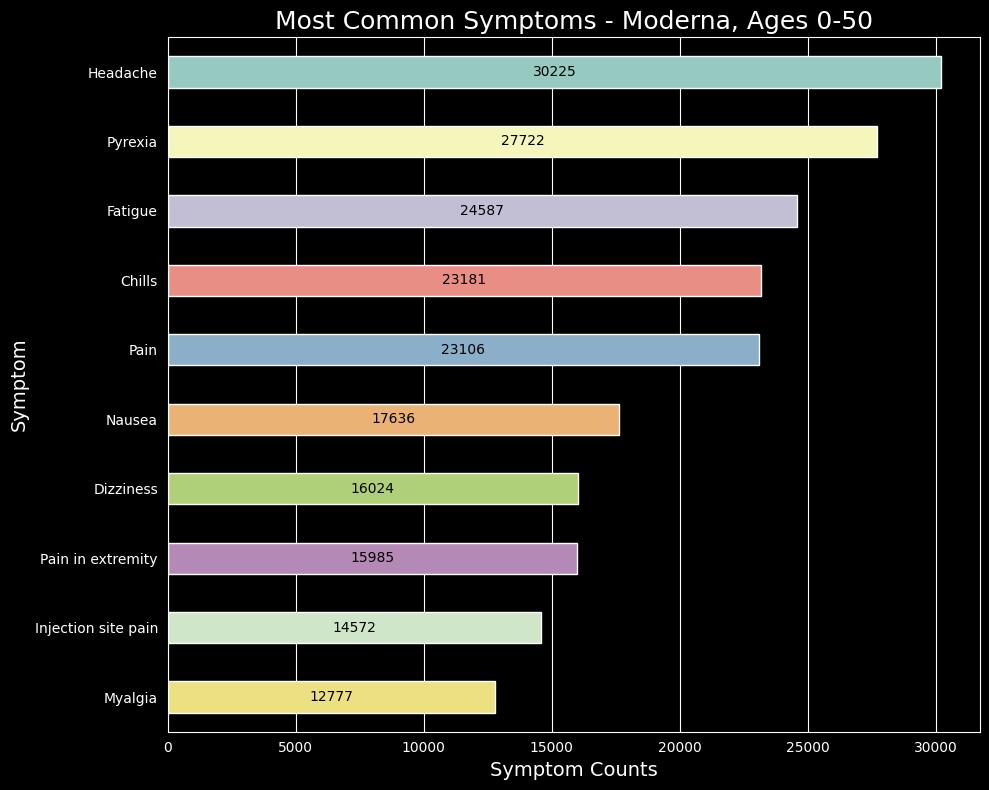

In [147]:
# plot 10 most common symptoms overall ages 0-50 - Moderna only

# bar chart
fig, ax = plt.subplots(figsize=(10, 8))
most_common_symptoms_0_50_Moderna = sns.barplot(data=df_symptom_counts7[0:10], x="count", y="symptom", hue='symptom', width=0.5, gap=0.1)

for container in ax.containers:
    ax.bar_label(container, fontsize=10, label_type='center', color='black')

ax.set_xlabel('Symptom Counts', fontsize=14)
ax.set_ylabel('Symptom', fontsize=14)
ax.set_title('Most Common Symptoms - Moderna, Ages 0-50', fontsize=18)

plt.tight_layout()
plt.show()

fig.savefig('visualizations/moderna/most_common_symptoms_Moderna_0_50.png')

### Most Common Symptoms 51-100

In [148]:
VAERS_Moderna_51_up = VAERS_Moderna_symptoms[VAERS_Moderna_symptoms['AGE_YRS'] >= 51]
VAERS_Moderna_51_up.describe().T

,count,mean,min,25%,50%,75%,max,std
VAERS_ID,843957.0,1599985.728439,905937.0,1117363.0,1542736.0,1967919.0,2776283.0,539868.184981
RECVDATE,843957,2021-08-30 17:08:26.051848448,2020-12-21 00:00:00,2021-03-12 00:00:00,2021-06-29 00:00:00,2021-11-20 00:00:00,2024-06-27 00:00:00,NaN
AGE_YRS,843957.0,65.813257,51.0,58.0,65.0,72.0,110.0,9.763364
RPT_DATE,1213,2021-05-01 15:54:27.600989184,2020-01-13 00:00:00,2021-01-19 00:00:00,2021-02-05 00:00:00,2021-08-17 00:00:00,2023-11-02 00:00:00,NaN
DATEDIED,17800,2021-08-06 18:32:26.426965248,2020-12-01 00:00:00,2021-03-06 00:00:00,2021-05-03 00:00:00,2021-11-17 00:00:00,2024-06-22 00:00:00,NaN
HOSPDAYS,62575.0,4.210627,1.0,2.0,3.0,5.0,14.0,3.118047
VAX_DATE,828814,2021-06-05 15:38:16.655220224,2020-01-01 00:00:00,2021-02-08 00:00:00,2021-03-15 00:00:00,2021-07-20 00:00:00,2024-06-26 00:00:00,NaN
ONSET_DATE,799750,2021-06-10 17:56:29.712285696,2020-01-01 00:00:00,2021-02-10 00:00:00,2021-03-19 00:00:00,2021-08-03 00:00:00,2024-06-26 00:00:00,NaN
NUMDAYS,777456.0,2.782907,0.0,0.0,1.0,3.0,20.0,4.364422
FORM_VERS,843957.0,1.998511,1.0,2.0,2.0,2.0,2.0,0.038564


In [149]:
symptom_counts8 = VAERS_Moderna_51_up['symptom'].value_counts()
df_symptom_counts8 = symptom_counts8.to_frame()
df_symptom_counts8[0:10]

,count
symptom,
Headache,33696
Fatigue,29926
Pyrexia,29531
Chills,26174
Pain,23809
Pain in extremity,20898
Nausea,17646
Myalgia,14919
Dizziness,14281


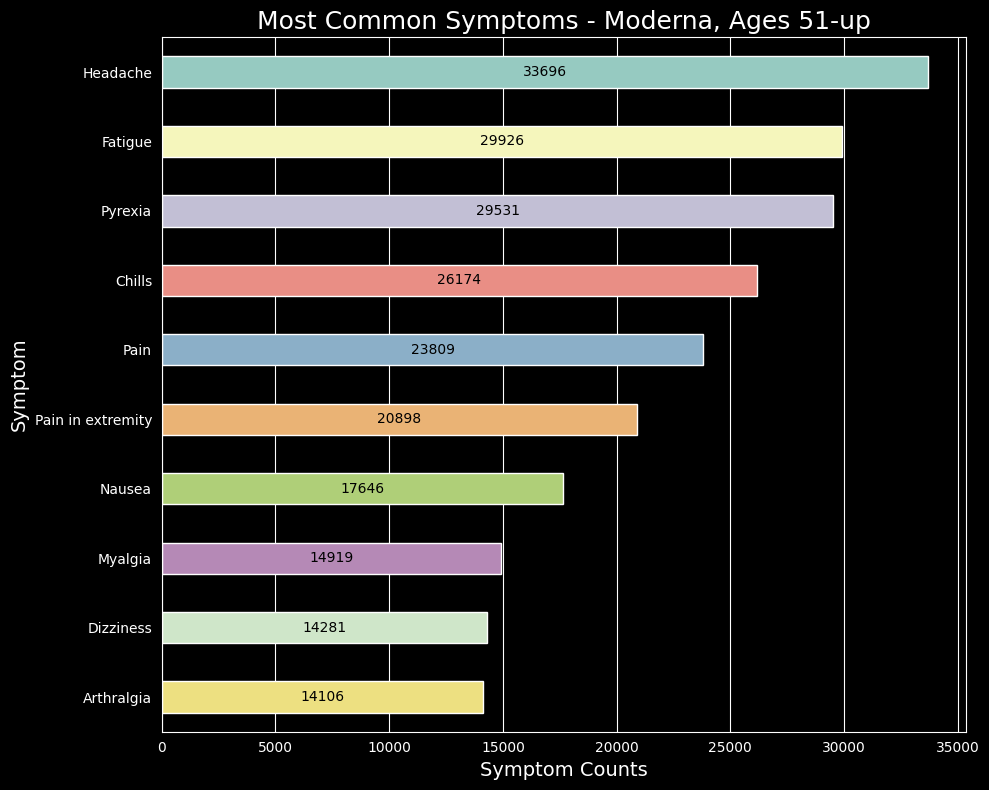

In [150]:
# plot 10 most common symptoms overall ages 51-up - Moderna only

# bar chart
fig, ax = plt.subplots(figsize=(10, 8))
most_common_symptoms_51_up_Moderna = sns.barplot(data=df_symptom_counts8[0:10], x="count", y="symptom", hue='symptom', width=0.5, gap=0.1)

for container in ax.containers:
    ax.bar_label(container, fontsize=10, label_type='center', color='black')

ax.set_xlabel('Symptom Counts', fontsize=14)
ax.set_ylabel('Symptom', fontsize=14)
ax.set_title('Most Common Symptoms - Moderna, Ages 51-up', fontsize=18)

plt.tight_layout()
plt.show()

fig.savefig('visualizations/moderna/most_common_symptoms_Moderna_51_up.png')

### Most Common Symptoms Female

In [151]:
# filter by sex
df_symptoms_F_Moderna = df_symptoms_VAERS_merged[(df_symptoms_VAERS_merged['SEX'] == 'F') & (df_symptoms_VAERS_merged['VAX_MANU_x'] == "MODERNA")]
df_symptoms_M_Moderna = df_symptoms_VAERS_merged[(df_symptoms_VAERS_merged['SEX'] == 'M') & (df_symptoms_VAERS_merged['VAX_MANU_x'] == "MODERNA")]
df_symptoms_U_Moderna = df_symptoms_VAERS_merged[(df_symptoms_VAERS_merged['SEX'] == 'U') & (df_symptoms_VAERS_merged['VAX_MANU_x'] == "MODERNA")]

In [152]:
# get counts of 10 most common symptoms by sex
symptom_counts_F_Moderna = df_symptoms_F_Moderna['symptom'].value_counts()
df_symptom_counts_F_Moderna = symptom_counts_F_Moderna.to_frame()
symptom_counts_M_Moderna = df_symptoms_M_Moderna['symptom'].value_counts()
df_symptom_counts_M_Moderna = symptom_counts_M_Moderna.to_frame()
symptom_counts_U_Moderna = df_symptoms_U_Moderna['symptom'].value_counts()
df_symptom_counts_U_Moderna = symptom_counts_U_Moderna.to_frame()

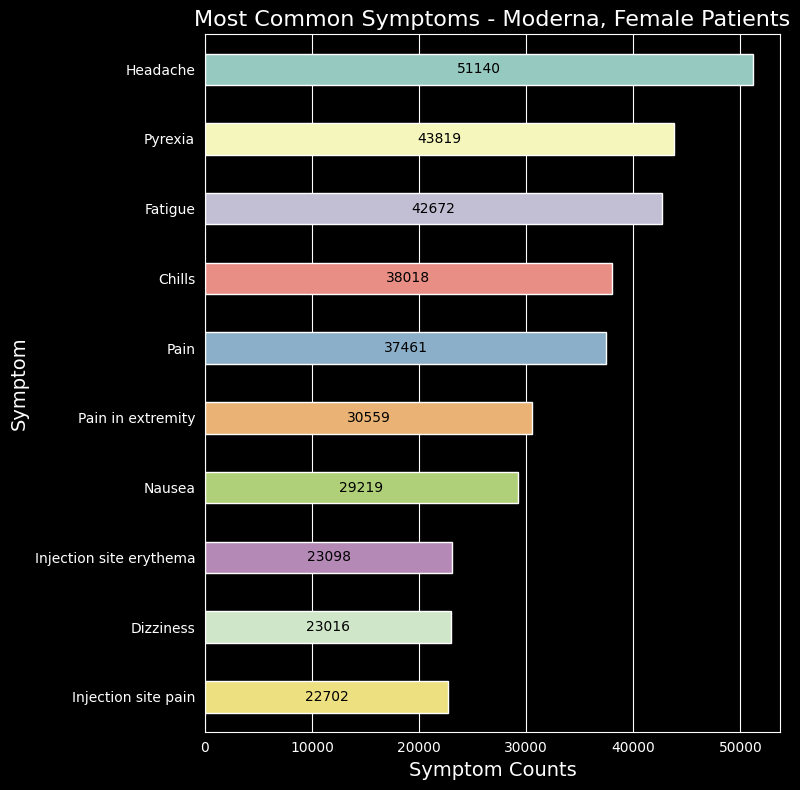

In [153]:
# plot most common symptoms by sex - F

# bar chart
fig, ax = plt.subplots(figsize=(8, 8))
sns.barplot(data=df_symptom_counts_F_Moderna[0:10], x="count", y="symptom", hue='symptom', width=0.5, gap=0.1)

for container in ax.containers:
    ax.bar_label(container, fontsize=10, label_type='center', color='black')
ax.set_xlabel('Symptom Counts', fontsize=14)
ax.set_ylabel('Symptom', fontsize=14)
ax.set_title('Most Common Symptoms - Moderna, Female Patients', fontsize=16)

plt.tight_layout()
plt.show()

fig.savefig('visualizations/moderna/most_common_symptoms_female_Moderna.png')

### Most Common Symptoms Male

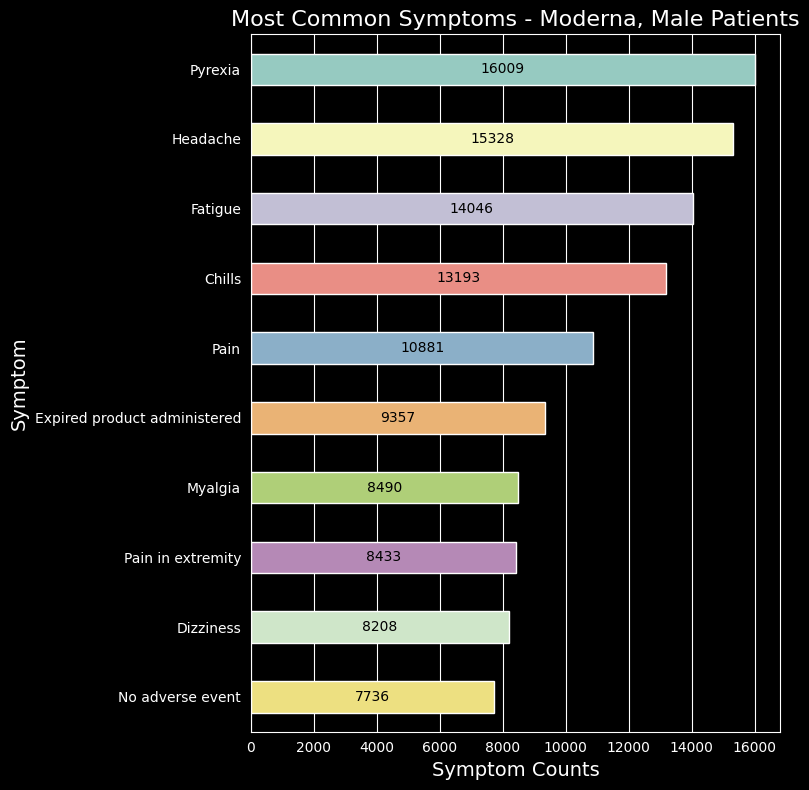

In [154]:
# plot most common symptoms by sex - M

# bar chart
fig, ax = plt.subplots(figsize=(8, 8))
sns.barplot(data=df_symptom_counts_M_Moderna[0:10], x="count", y="symptom", hue='symptom', width=0.5, gap=0.1)

for container in ax.containers:
    ax.bar_label(container, fontsize=10, label_type='center', color='black')
ax.set_xlabel('Symptom Counts', fontsize=14)
ax.set_ylabel('Symptom', fontsize=14)
ax.set_title('Most Common Symptoms - Moderna, Male Patients', fontsize=16)

plt.tight_layout()
plt.show()

fig.savefig('visualizations/moderna/most_common_symptoms_male_Moderna.png')

# Additional Visualizations - Filtered by Washington State

## WA - frequency of reports by age

In [82]:
# filter df_VAERS_filtered for Washington State
VAERS_WA = df_VAERS_filtered[df_VAERS_filtered['STATE'] == 'WA']
print(VAERS_WA['STATE'].unique().tolist())

['WA']


In [159]:
# summary stats
VAERS_WA.describe().T

,count,mean,min,25%,50%,75%,max,std
VAERS_ID,19206.0,1666708.957409,902793.0,1188879.25,1571708.0,2090750.5,2776028.0,544486.593413
RECVDATE,19206,2021-10-20 20:15:44.704779776,2020-12-16 00:00:00,2021-04-09 00:00:00,2021-08-15 00:00:00,2022-02-04 00:00:00,2024-06-26 00:00:00,NaN
AGE_YRS,18282.0,46.128738,0.08,31.0,46.0,63.0,103.0,20.718445
RPT_DATE,6,2022-01-13 04:00:00,2021-03-21 00:00:00,2021-05-23 00:00:00,2021-11-18 00:00:00,2022-08-11 18:00:00,2023-02-23 00:00:00,NaN
DATEDIED,106,2021-07-08 09:44:09.056603648,2020-12-29 00:00:00,2021-02-26 00:00:00,2021-04-13 00:00:00,2021-09-28 18:00:00,2023-10-27 00:00:00,NaN
HOSPDAYS,555.0,3.212613,1.0,1.5,2.0,4.0,14.0,2.457183
VAX_DATE,18713,2021-08-10 23:15:45.161117952,2020-01-01 00:00:00,2021-03-02 00:00:00,2021-05-01 00:00:00,2021-11-19 00:00:00,2024-06-26 00:00:00,NaN
ONSET_DATE,18032,2021-08-10 22:21:46.477373696,2020-01-06 00:00:00,2021-03-03 00:00:00,2021-05-03 00:00:00,2021-11-19 00:00:00,2024-06-26 00:00:00,NaN
NUMDAYS,17503.0,2.239273,0.0,0.0,0.0,2.0,20.0,3.969789
FORM_VERS,19206.0,1.999636,1.0,2.0,2.0,2.0,2.0,0.019088


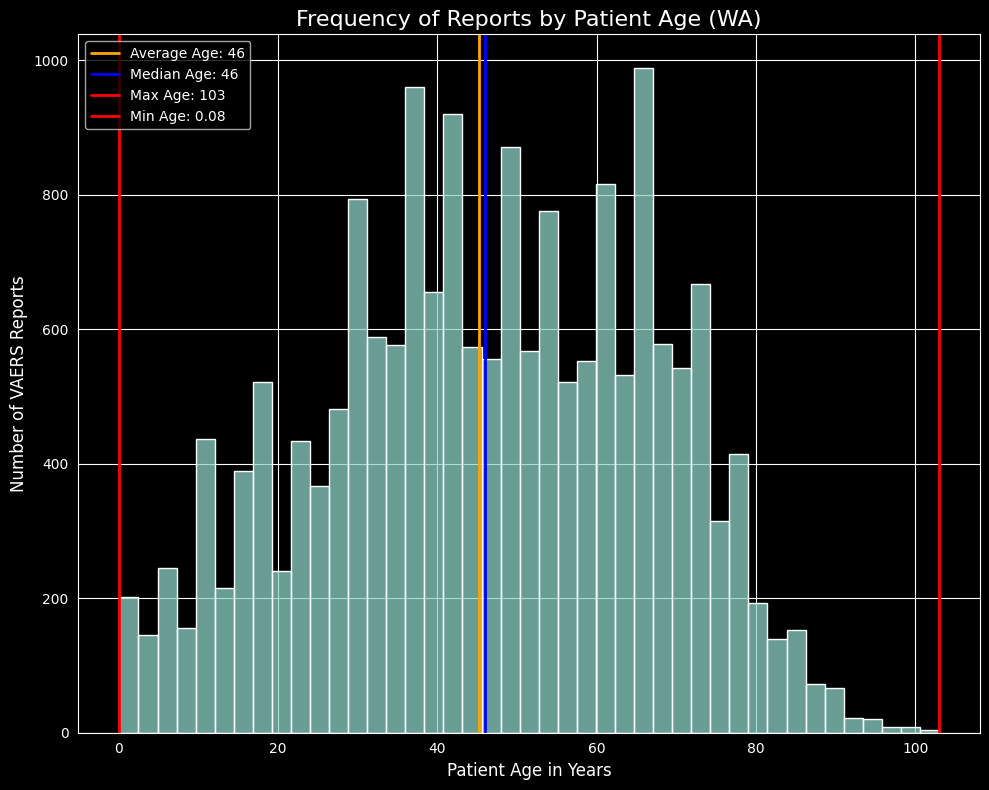

In [97]:
# plot distribution - patient age
fig, ax = plt.subplots(figsize=(10, 8))
patient_age_overall = sns.histplot(data=VAERS_WA, x="AGE_YRS", legend=True)

plt.axvline(x=VAERS_Pfizer.AGE_YRS.mean(),
            color='orange', lw=2.0, label='Average Age: 46')
plt.axvline(x=VAERS_WA.AGE_YRS.median(), color = 'blue', lw=2.0, label='Median Age: 46')
plt.axvline(x=VAERS_WA.AGE_YRS.max(), color = 'red', lw=2.0, label='Max Age: 103')
plt.axvline(x=VAERS_WA.AGE_YRS.min(), color = 'red', lw=2.0, label='Min Age: 0.08')

plt.legend(loc='upper left')

ax.set_xlabel('Patient Age in Years', fontsize=12)
ax.set_ylabel('Number of VAERS Reports', fontsize=12)
ax.set_title('Frequency of Reports by Patient Age (WA)', fontsize=16)

plt.tight_layout()
plt.show()

fig.savefig('visualizations/WA/frequency_reports_age_WA.png')

## WA - frequency of reports by sex

In [83]:
# create groupby object
VAERS_WA_sex_grouped = VAERS_WA.groupby(by=['SEX']).agg(report_count=("VAERS_ID", 'count'))

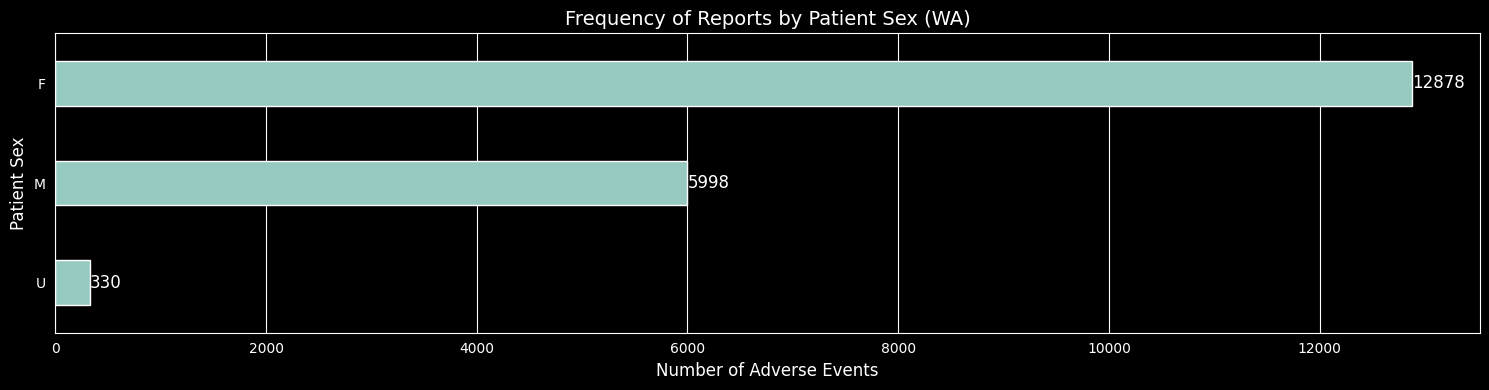

In [98]:
# bar chart
fig, ax = plt.subplots(figsize=(15, 4))
sns.barplot(data = VAERS_WA_sex_grouped, x='report_count', y='SEX', legend=False, width=0.5, gap=0.1) # seaborn horizontal chart

for container in ax.containers:
    ax.bar_label(container, fontsize=12)
ax.set_xlabel('Number of Adverse Events', fontsize=12)
ax.set_ylabel('Patient Sex', fontsize=12)
ax.set_title('Frequency of Reports by Patient Sex (WA)', fontsize=14)

fig.savefig('visualizations/WA/frequency_reports_sex_WA.png')

plt.tight_layout()
plt.show()

## WA - most common symptoms

#### most common overall WA

In [164]:
# merge VAERS_WA with df_symptoms_filtered
VAERS_WA_symptoms = pd.merge(VAERS_WA, df_symptoms_filtered, how='left', on='VAERS_ID')
VAERS_WA_symptoms.head()

,VAERS_ID,RECVDATE,STATE,AGE_YRS,SEX,RPT_DATE,DIED,DATEDIED,L_THREAT,ER_VISIT,...,symptom,symptom_version,symptom_dict,VAX_TYPE_y,VAX_MANU_y,VAX_LOT_y,VAX_DOSE_SERIES_y,VAX_ROUTE_y,VAX_SITE_y,VAX_NAME_y
0,902793,2020-12-16,WA,71.0,F,NaT,N,NaT,N,N,...,Asthenia,23.1,"{'SYMPTOM1': 'Asthenia', 'SYMPTOMVERSION1': 23.1}",COVID19,PFIZER\BIONTECH,EK5U30,1.0,IM,LA,PFIZER-BIONTECH
1,902793,2020-12-16,WA,71.0,F,NaT,N,NaT,N,N,...,Impaired work ability,23.1,"{'SYMPTOM1': 'Impaired work ability', 'SYMPTOM...",COVID19,PFIZER\BIONTECH,EK5U30,1.0,IM,LA,PFIZER-BIONTECH
2,902793,2020-12-16,WA,71.0,F,NaT,N,NaT,N,N,...,Tongue discomfort,23.1,"{'SYMPTOM1': 'Tongue discomfort', 'SYMPTOMVERS...",COVID19,PFIZER\BIONTECH,EK5U30,1.0,IM,LA,PFIZER-BIONTECH
3,902793,2020-12-16,WA,71.0,F,NaT,N,NaT,N,N,...,Blood glucose normal,23.1,"{'SYMPTOM2': 'Blood glucose normal', 'SYMPTOMV...",COVID19,PFIZER\BIONTECH,EK5U30,1.0,IM,LA,PFIZER-BIONTECH
4,902793,2020-12-16,WA,71.0,F,NaT,N,NaT,N,N,...,Malaise,23.1,"{'SYMPTOM2': 'Malaise', 'SYMPTOMVERSION2': 23.1}",COVID19,PFIZER\BIONTECH,EK5U30,1.0,IM,LA,PFIZER-BIONTECH


In [165]:
print(VAERS_WA_symptoms['STATE'].unique().tolist())

['WA']


In [167]:
symptom_counts9 = VAERS_WA_symptoms['symptom'].value_counts()
df_symptom_counts9 = symptom_counts9.to_frame()
df_symptom_counts9[0:10]

,count
symptom,
Headache,2938
Fatigue,2795
Pyrexia,2351
Pain,2285
Chills,1903
Nausea,1787
Pain in extremity,1760
Dizziness,1751
No adverse event,1264


NameError: name 'df_symptom_counts9' is not defined

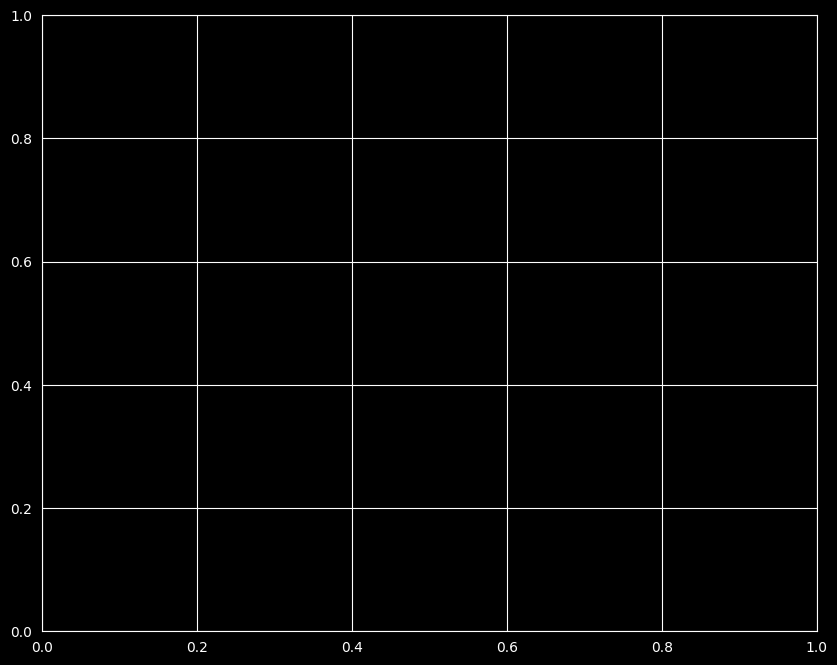

In [99]:
# plot 10 most common symptoms WA State

# bar chart
fig, ax = plt.subplots(figsize=(10, 8))
most_common_symptoms_WA = sns.barplot(data=df_symptom_counts9[0:10], x="count", y="symptom", hue='symptom', width=0.5, gap=0.1)

for container in ax.containers:
    ax.bar_label(container, fontsize=10, label_type='center', color='black')

ax.set_xlabel('Symptom Counts', fontsize=14)
ax.set_ylabel('Symptom', fontsize=14)
ax.set_title('Most Common Symptoms - WA', fontsize=18)

plt.tight_layout()
plt.show()

fig.savefig('visualizations/WA/most_common_symptoms_WA.png')

#### most common overall WA - ages 0-50

In [169]:
VAERS_WA_symptoms_0_50 = VAERS_WA_symptoms[VAERS_WA_symptoms['AGE_YRS'] < 51]

symptom_counts10 = VAERS_WA_symptoms_0_50['symptom'].value_counts()
df_symptom_counts10 = symptom_counts10.to_frame()
df_symptom_counts10[0:10]

,count
symptom,
Headache,1517
Fatigue,1415
Pyrexia,1262
Pain,1233
Dizziness,1066
Nausea,986
Chills,942
Pain in extremity,848
No adverse event,831


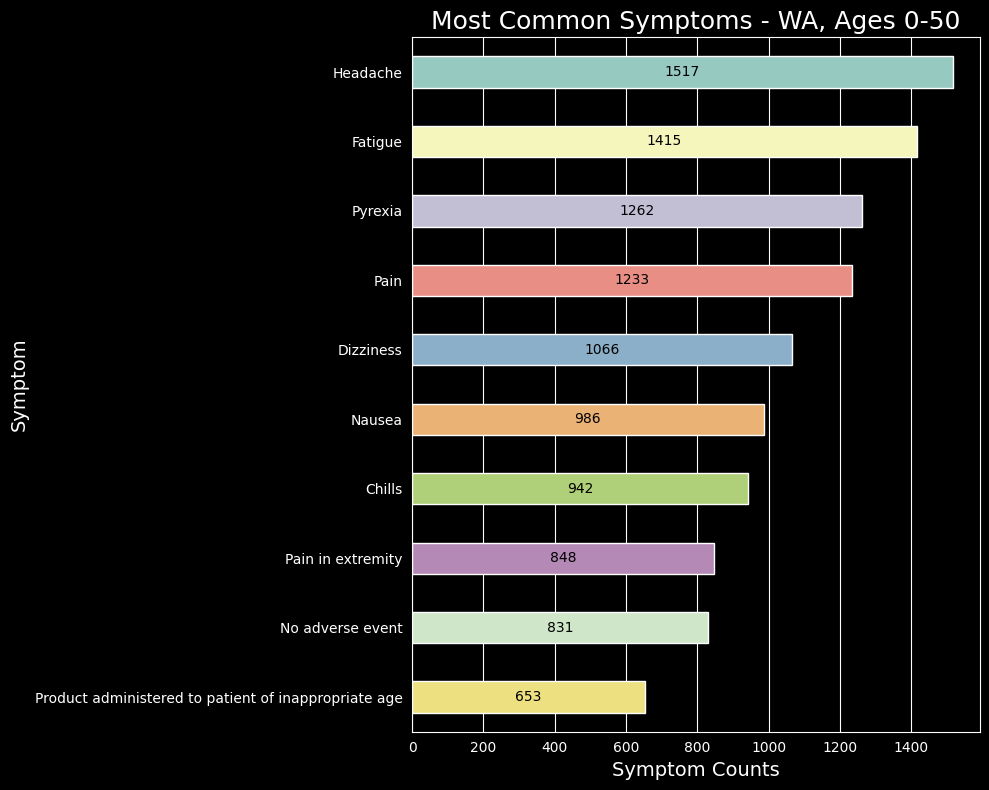

In [171]:
# plot 10 most common symptoms WA State - ages 0-50

# bar chart
fig, ax = plt.subplots(figsize=(10, 8))
most_common_symptoms_WA_0_50 = sns.barplot(data=df_symptom_counts10[0:10], x="count", y="symptom", hue='symptom', width=0.5, gap=0.1)

for container in ax.containers:
    ax.bar_label(container, fontsize=10, label_type='center', color='black')

ax.set_xlabel('Symptom Counts', fontsize=14)
ax.set_ylabel('Symptom', fontsize=14)
ax.set_title('Most Common Symptoms - WA, Ages 0-50', fontsize=18)

plt.tight_layout()
plt.show()

fig.savefig('visualizations/WA/most_common_symptoms_WA_0_50.png')

#### most common overall WA - ages 51-up

In [170]:
VAERS_WA_symptoms_51_up = VAERS_WA_symptoms[VAERS_WA_symptoms['AGE_YRS'] >= 51]

symptom_counts11 = VAERS_WA_symptoms_51_up['symptom'].value_counts()
df_symptom_counts11 = symptom_counts11.to_frame()
df_symptom_counts11[0:10]

,count
symptom,
Headache,1324
Fatigue,1289
Pyrexia,1008
Pain,968
Chills,900
Pain in extremity,836
Nausea,759
Arthralgia,666
Dizziness,655


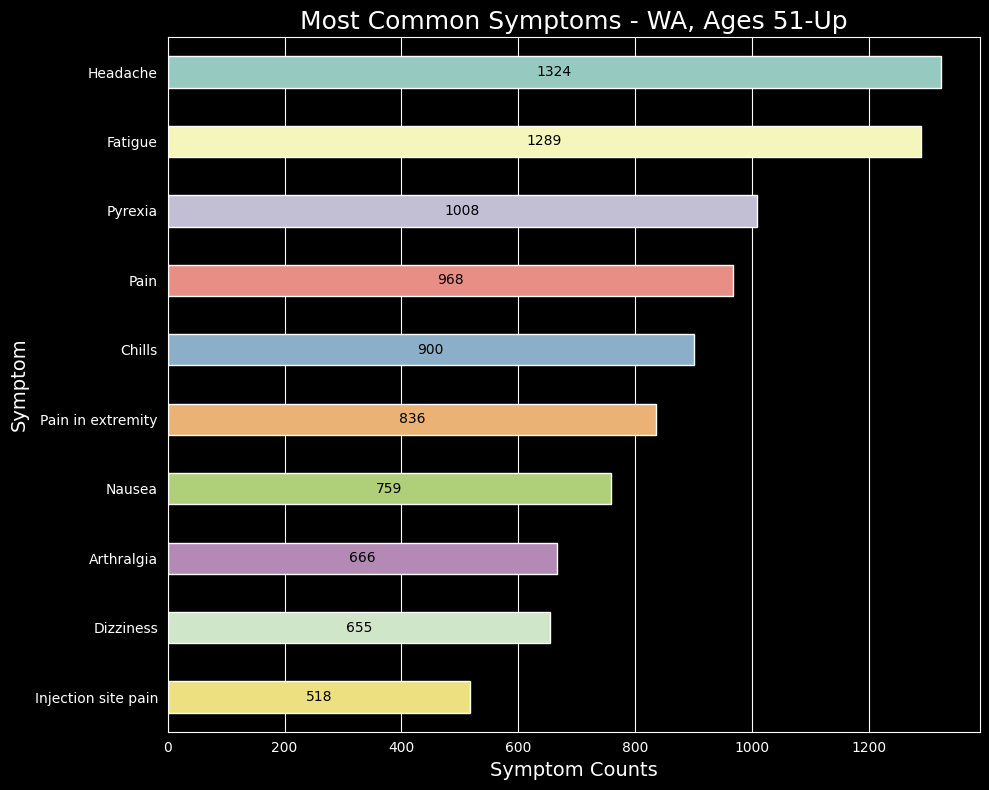

In [177]:
# plot 10 most common symptoms WA State - ages 51-up

# bar chart
fig, ax = plt.subplots(figsize=(10, 8))
most_common_symptoms_WA_51_up = sns.barplot(data=df_symptom_counts11[0:10], x="count", y="symptom", hue='symptom', width=0.5, gap=0.1)

for container in ax.containers:
    ax.bar_label(container, fontsize=10, label_type='center', color='black')

ax.set_xlabel('Symptom Counts', fontsize=14)
ax.set_ylabel('Symptom', fontsize=14)
ax.set_title('Most Common Symptoms - WA, Ages 51-Up', fontsize=18)

plt.tight_layout()
plt.show()

fig.savefig('visualizations/WA/most_common_symptoms_WA_51-up.png')

#### most common overall WA - female

In [173]:
VAERS_WA_symptoms_F = VAERS_WA_symptoms[VAERS_WA_symptoms['SEX'] == 'F']

symptom_counts12 = VAERS_WA_symptoms_F['symptom'].value_counts()
df_symptom_counts12 = symptom_counts12.to_frame()
df_symptom_counts12[0:10]

,count
symptom,
Headache,2290
Fatigue,2108
Pain,1764
Pyrexia,1696
Chills,1421
Nausea,1419
Pain in extremity,1383
Dizziness,1289
Injection site pain,909


In [174]:
print(VAERS_WA_symptoms_F['SEX'].unique().tolist())

['F']


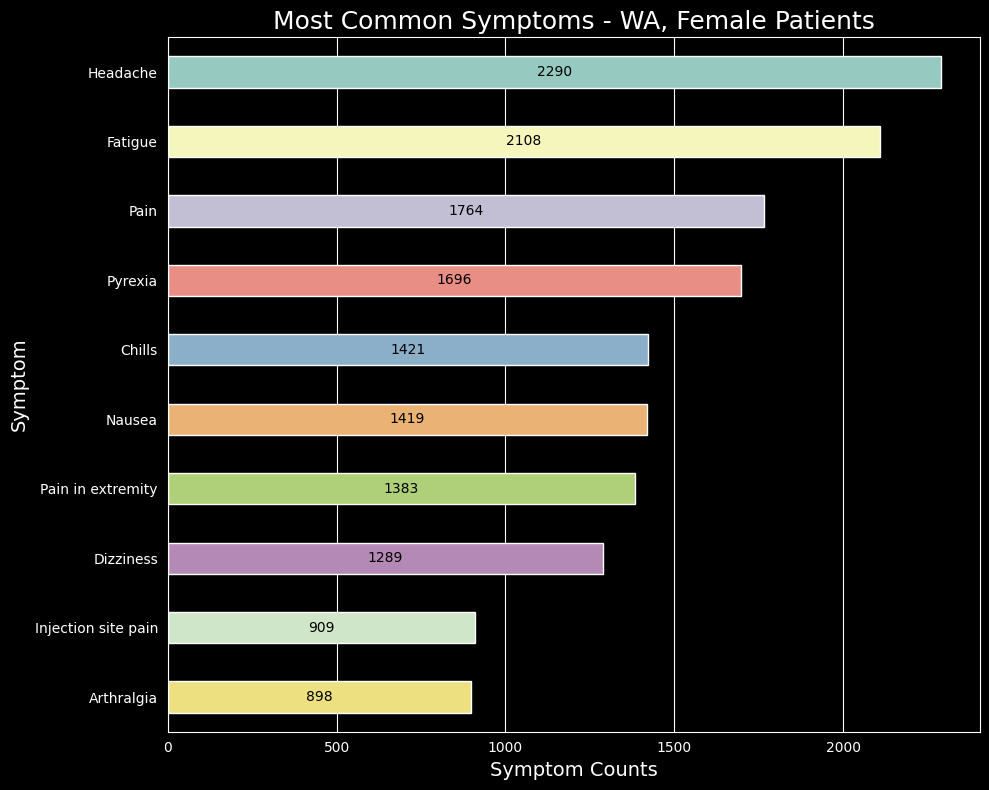

In [178]:
# plot 10 most common symptoms WA State - female

# bar chart
fig, ax = plt.subplots(figsize=(10, 8))
most_common_symptoms_WA_F = sns.barplot(data=df_symptom_counts12[0:10], x="count", y="symptom", hue='symptom', width=0.5, gap=0.1)

for container in ax.containers:
    ax.bar_label(container, fontsize=10, label_type='center', color='black')

ax.set_xlabel('Symptom Counts', fontsize=14)
ax.set_ylabel('Symptom', fontsize=14)
ax.set_title('Most Common Symptoms - WA, Female Patients', fontsize=18)

plt.tight_layout()
plt.show()

fig.savefig('visualizations/WA/most_common_symptoms_WA_F.png')

#### most common overall WA - male

In [175]:
VAERS_WA_symptoms_M = VAERS_WA_symptoms[VAERS_WA_symptoms['SEX'] == 'M']

symptom_counts13 = VAERS_WA_symptoms_M['symptom'].value_counts()
df_symptom_counts13 = symptom_counts13.to_frame()
df_symptom_counts13[0:10]

,count
symptom,
Fatigue,659
Headache,633
Pyrexia,630
No adverse event,564
Pain,493
Chills,472
Dizziness,452
Product storage error,391
Pain in extremity,362


In [176]:
print(VAERS_WA_symptoms_M['SEX'].unique().tolist())

['M']


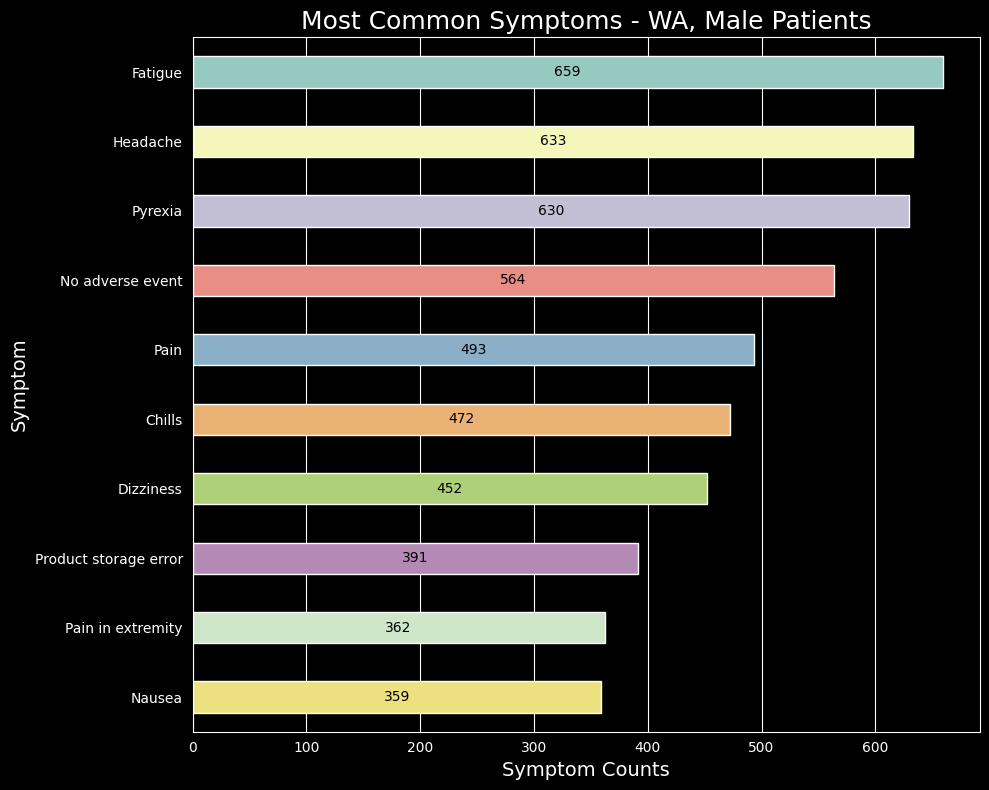

In [179]:
# plot 10 most common symptoms WA State - male

# bar chart
fig, ax = plt.subplots(figsize=(10, 8))
most_common_symptoms_WA_M = sns.barplot(data=df_symptom_counts13[0:10], x="count", y="symptom", hue='symptom', width=0.5, gap=0.1)

for container in ax.containers:
    ax.bar_label(container, fontsize=10, label_type='center', color='black')

ax.set_xlabel('Symptom Counts', fontsize=14)
ax.set_ylabel('Symptom', fontsize=14)
ax.set_title('Most Common Symptoms - WA, Male Patients', fontsize=18)

plt.tight_layout()
plt.show()

fig.savefig('visualizations/WA/most_common_symptoms_WA_M.png')

## WA - frequency of reports over time

In [181]:
VAERS_WA.head()

,VAERS_ID,RECVDATE,STATE,AGE_YRS,SEX,RPT_DATE,DIED,DATEDIED,L_THREAT,ER_VISIT,...,BIRTH_DEFECT,OFC_VISIT,ER_ED_VISIT,VAX_TYPE,VAX_MANU,VAX_LOT,VAX_DOSE_SERIES,VAX_ROUTE,VAX_SITE,VAX_NAME
66,902793,2020-12-16,WA,71.0,F,NaT,N,NaT,N,N,...,N,N,N,COVID19,PFIZER\BIONTECH,EK5U30,1.0,IM,LA,PFIZER-BIONTECH
293,903279,2020-12-17,WA,41.0,F,NaT,N,NaT,N,N,...,N,N,N,COVID19,PFIZER\BIONTECH,EH9899,1.0,IM,LA,PFIZER-BIONTECH
297,903283,2020-12-17,WA,31.0,F,NaT,N,NaT,N,N,...,N,N,Y,COVID19,PFIZER\BIONTECH,EH9899,1.0,SYR,RA,PFIZER-BIONTECH
397,903440,2020-12-18,WA,43.0,F,NaT,N,NaT,N,N,...,N,N,Y,COVID19,PFIZER\BIONTECH,EJ1685,1.0,UN,AR,PFIZER-BIONTECH
444,903516,2020-12-18,WA,36.0,F,NaT,N,NaT,N,N,...,N,N,N,COVID19,PFIZER\BIONTECH,EL0140,1.0,IM,LA,PFIZER-BIONTECH


In [185]:
# add column to line1 with MonthYear object
import datetime
VAERS_WA['ONSET_YEAR'] = VAERS_WA['ONSET_DATE'].dt.year
VAERS_WA['ONSET_MONTH'] = VAERS_WA['ONSET_DATE'].dt.strftime('%b')
VAERS_WA['ONSET_MONTHYEAR'] = VAERS_WA['ONSET_DATE'].dt.strftime('%Y-%m')

In [186]:
VAERS_WA.head()

,VAERS_ID,RECVDATE,STATE,AGE_YRS,SEX,RPT_DATE,DIED,DATEDIED,L_THREAT,ER_VISIT,...,VAX_TYPE,VAX_MANU,VAX_LOT,VAX_DOSE_SERIES,VAX_ROUTE,VAX_SITE,VAX_NAME,ONSET_YEAR,ONSET_MONTH,ONSET_MONTHYEAR
66,902793,2020-12-16,WA,71.0,F,NaT,N,NaT,N,N,...,COVID19,PFIZER\BIONTECH,EK5U30,1.0,IM,LA,PFIZER-BIONTECH,2020.0,Dec,2020-12
293,903279,2020-12-17,WA,41.0,F,NaT,N,NaT,N,N,...,COVID19,PFIZER\BIONTECH,EH9899,1.0,IM,LA,PFIZER-BIONTECH,2020.0,Dec,2020-12
297,903283,2020-12-17,WA,31.0,F,NaT,N,NaT,N,N,...,COVID19,PFIZER\BIONTECH,EH9899,1.0,SYR,RA,PFIZER-BIONTECH,2020.0,Dec,2020-12
397,903440,2020-12-18,WA,43.0,F,NaT,N,NaT,N,N,...,COVID19,PFIZER\BIONTECH,EJ1685,1.0,UN,AR,PFIZER-BIONTECH,2020.0,Dec,2020-12
444,903516,2020-12-18,WA,36.0,F,NaT,N,NaT,N,N,...,COVID19,PFIZER\BIONTECH,EL0140,1.0,IM,LA,PFIZER-BIONTECH,2020.0,Dec,2020-12


In [188]:
# create grouped bar chart
VAERS_WA_grouped = VAERS_WA.groupby(by=["ONSET_MONTHYEAR"]).agg(report_count=("VAERS_ID", 'count'))
# display(VAERS_WA_grouped)

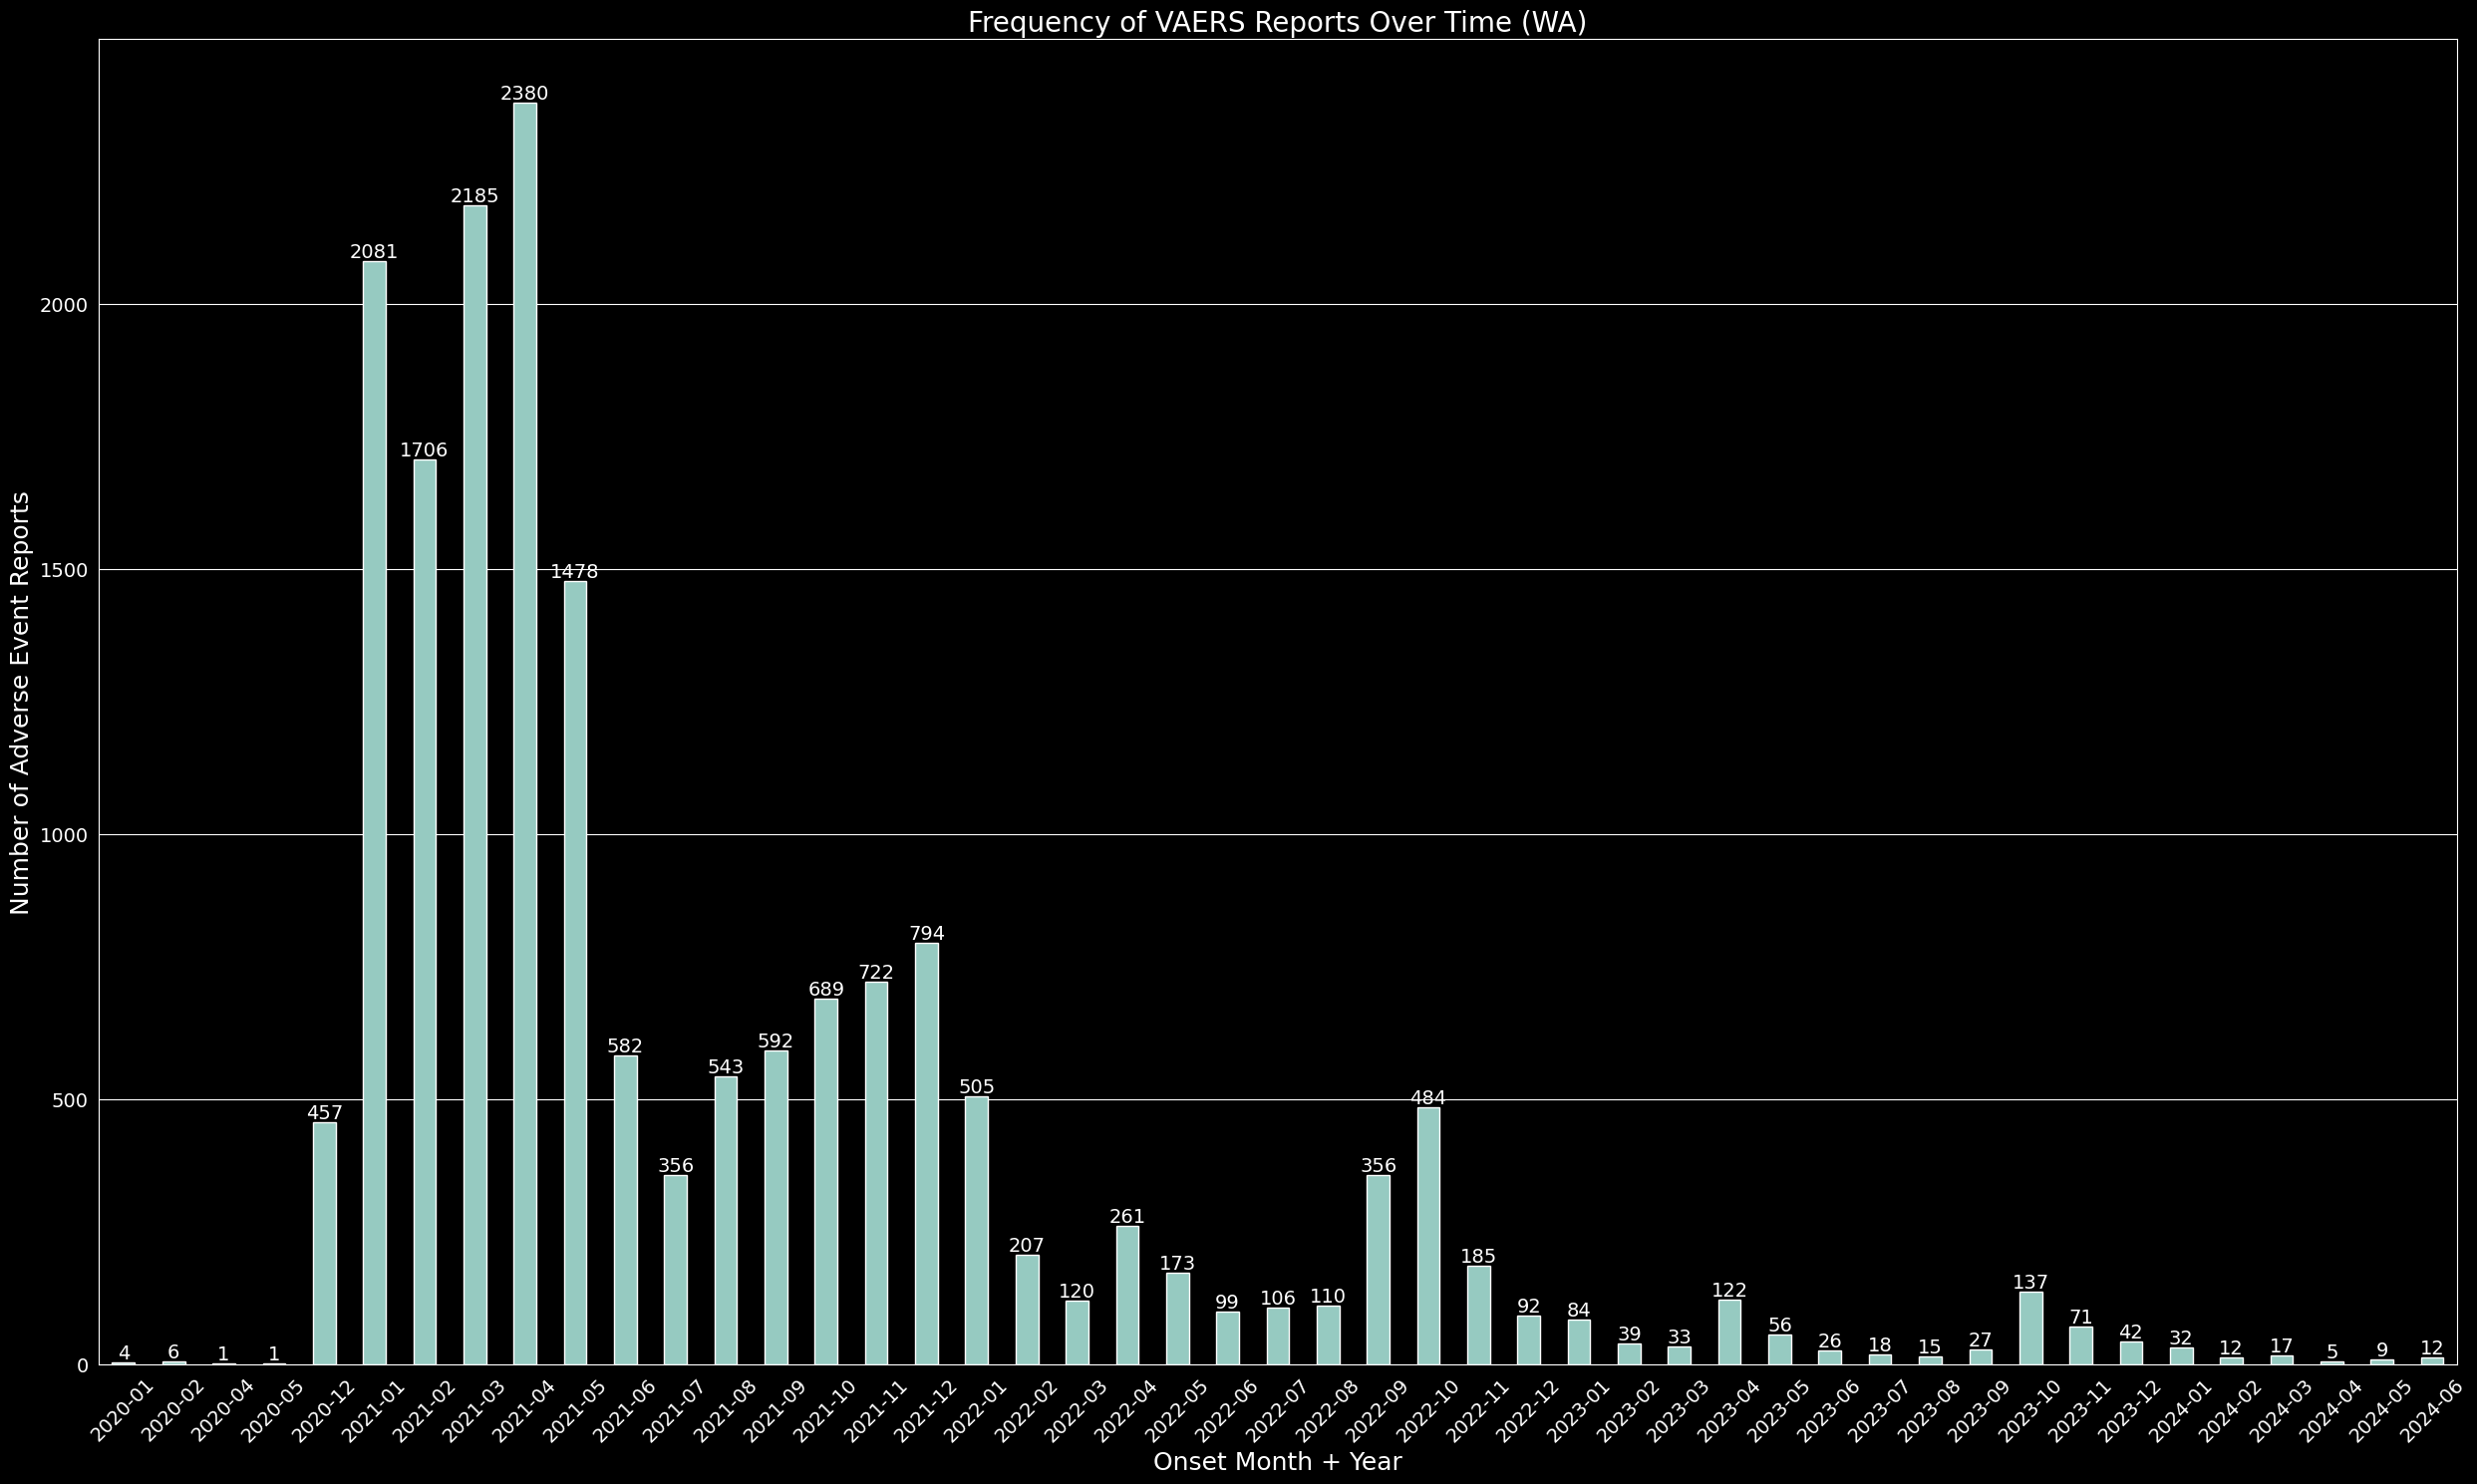

In [189]:
# bar chart
fig, ax = plt.subplots(figsize=(25, 15))
frequency_reports_over_time_WA = sns.barplot(data=VAERS_WA_grouped, x="ONSET_MONTHYEAR", y="report_count", width=0.5, gap=0.1)

for container in ax.containers:
    ax.bar_label(container, fontsize=14)
ax.set_xlabel('Onset Month + Year', fontsize=18)
ax.tick_params("x", rotation=45)
ax.tick_params(axis='both', which='major', labelsize=14)
ax.tick_params(axis='both', which='minor', labelsize=14)
ax.set_ylabel('Number of Adverse Event Reports', fontsize=18)
ax.set_title('Frequency of VAERS Reports Over Time (WA)', fontsize=20)

plt.tight_layout()
plt.show()

fig.savefig("visualizations/WA/frequency_reports_over_time_WA.png")

# Additional Visualizations - 1 Dose

## 1 Dose - frequency of reports by age

In [190]:
df_VAERS_filtered.head()

,VAERS_ID,RECVDATE,STATE,AGE_YRS,SEX,RPT_DATE,DIED,DATEDIED,L_THREAT,ER_VISIT,...,BIRTH_DEFECT,OFC_VISIT,ER_ED_VISIT,VAX_TYPE,VAX_MANU,VAX_LOT,VAX_DOSE_SERIES,VAX_ROUTE,VAX_SITE,VAX_NAME
0,902418,2020-12-15,NJ,56.0,F,NaT,N,NaT,N,N,...,N,N,N,COVID19,PFIZER\BIONTECH,EH9899,1.0,IM,LA,PFIZER-BIONTECH
1,902440,2020-12-15,AZ,35.0,F,NaT,N,NaT,N,N,...,N,N,N,COVID19,PFIZER\BIONTECH,EH9899,1.0,SYR,LA,PFIZER-BIONTECH
2,902446,2020-12-15,WV,55.0,F,NaT,N,NaT,N,N,...,N,N,N,COVID19,PFIZER\BIONTECH,EH9899,1.0,IM,RA,PFIZER-BIONTECH
3,902464,2020-12-15,LA,42.0,M,NaT,N,NaT,N,N,...,N,N,Y,COVID19,PFIZER\BIONTECH,EH9899,NaN,IM,LA,PFIZER-BIONTECH
4,902465,2020-12-15,AR,60.0,F,NaT,N,NaT,N,N,...,N,N,N,COVID19,PFIZER\BIONTECH,EH9899,1.0,IM,RA,PFIZER-BIONTECH


In [85]:
# filter df_VAERS_filtered for Washington State
VAERS_dose1 = df_VAERS_filtered[df_VAERS_filtered['VAX_DOSE_SERIES'] == 1]
print(VAERS_dose1['VAX_DOSE_SERIES'].unique().tolist())

[1.0]


In [192]:
# summary stats
VAERS_dose1.describe().T

,count,mean,min,25%,50%,75%,max,std
VAERS_ID,352380.0,1495794.657563,902418.0,1097359.75,1390770.5,1715489.25,2776312.0,488337.704929
RECVDATE,352380,2021-07-27 08:23:51.663545088,2020-12-15 00:00:00,2021-03-07 00:00:00,2021-05-27 00:00:00,2021-09-08 00:00:00,2024-06-27 00:00:00,NaN
AGE_YRS,313842.0,47.239727,0.08,32.0,48.0,63.0,109.0,20.071014
RPT_DATE,208,2021-09-14 21:20:46.153846272,2020-12-21 00:00:00,2021-03-09 06:00:00,2021-08-12 00:00:00,2021-09-23 06:00:00,2024-05-21 00:00:00,NaN
DATEDIED,2658,2021-04-24 18:34:56.613996032,2020-01-10 00:00:00,2021-02-03 00:00:00,2021-03-11 00:00:00,2021-04-30 00:00:00,2024-05-15 00:00:00,NaN
HOSPDAYS,7814.0,3.867417,1.0,2.0,3.0,5.0,14.0,2.964327
VAX_DATE,333135,2021-05-05 14:15:29.850061056,2020-01-01 00:00:00,2021-01-28 00:00:00,2021-03-17 00:00:00,2021-05-18 00:00:00,2024-06-27 00:00:00,NaN
ONSET_DATE,314948,2021-05-08 09:41:40.389905152,2020-01-01 00:00:00,2021-01-30 00:00:00,2021-03-20 00:00:00,2021-05-21 00:00:00,2024-06-27 00:00:00,NaN
NUMDAYS,303665.0,2.264453,0.0,0.0,0.0,2.0,20.0,3.924607
FORM_VERS,352380.0,1.999376,1.0,2.0,2.0,2.0,2.0,0.024979


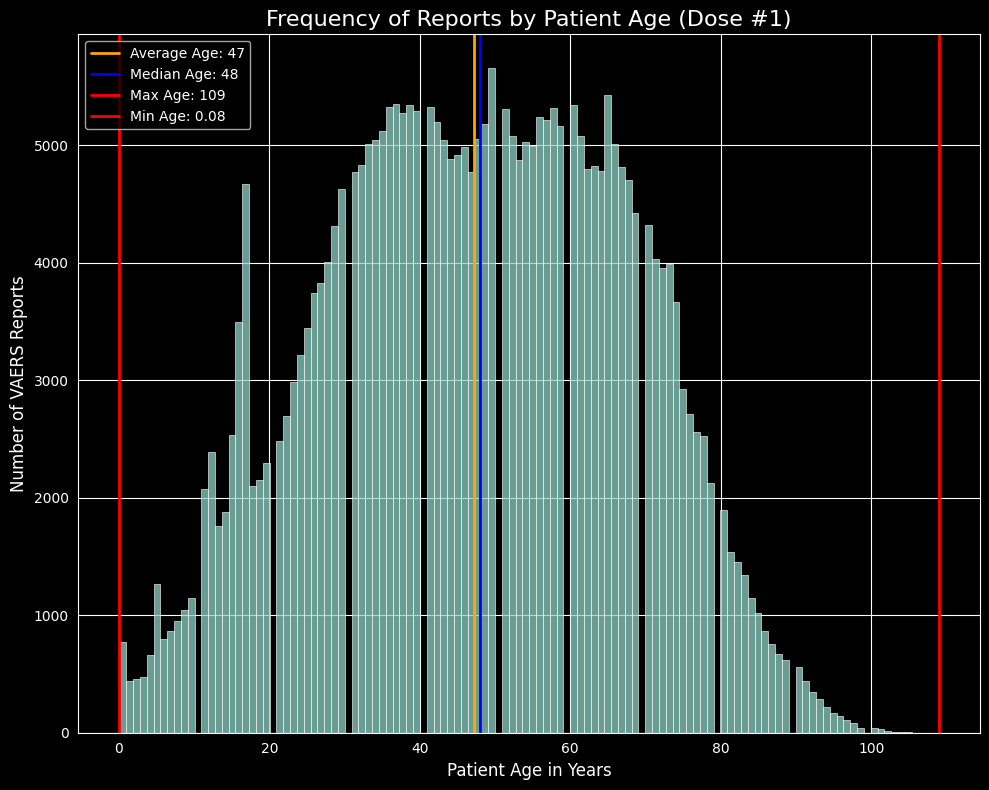

In [100]:
# plot distribution - patient age
fig, ax = plt.subplots(figsize=(10, 8))
patient_age_overall = sns.histplot(data=VAERS_dose1, x="AGE_YRS", legend=True)

plt.axvline(x=VAERS_dose1.AGE_YRS.mean(),
            color='orange', lw=2.0, label='Average Age: 47')
plt.axvline(x=VAERS_dose1.AGE_YRS.median(), color = 'blue', lw=2.0, label='Median Age: 48')
plt.axvline(x=VAERS_dose1.AGE_YRS.max(), color = 'red', lw=2.0, label='Max Age: 109')
plt.axvline(x=VAERS_dose1.AGE_YRS.min(), color = 'red', lw=2.0, label='Min Age: 0.08')

plt.legend(loc='upper left')

ax.set_xlabel('Patient Age in Years', fontsize=12)
ax.set_ylabel('Number of VAERS Reports', fontsize=12)
ax.set_title('Frequency of Reports by Patient Age (Dose #1)', fontsize=16)

plt.tight_layout()
plt.show()

fig.savefig('visualizations/dose1/frequency_reports_age_dose1.png')

## 1 Dose - frequency of reports by sex

In [86]:
# create groupby object
VAERS_dose1_sex_grouped = VAERS_dose1.groupby(by=['SEX']).agg(report_count=("VAERS_ID", 'count'))

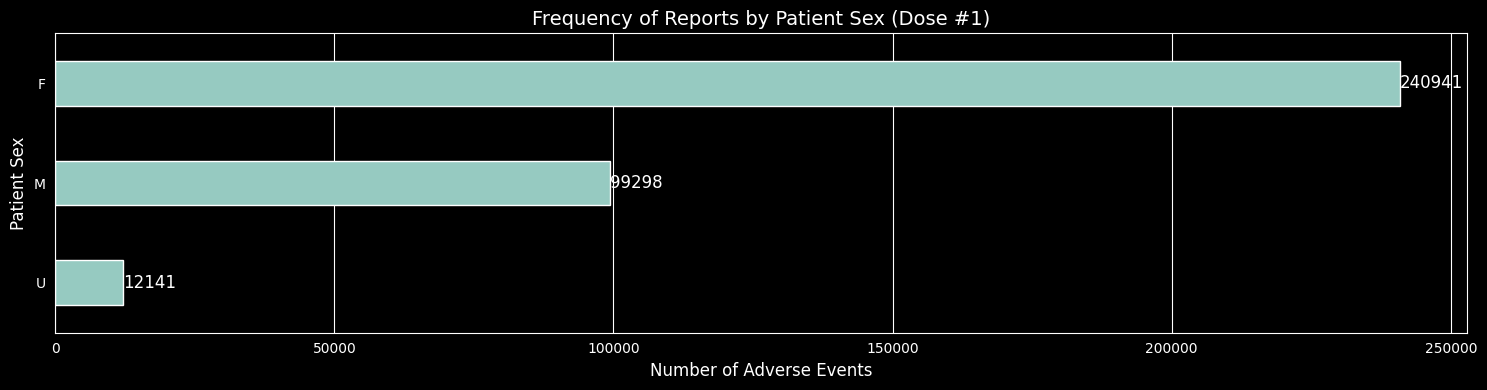

In [101]:
# bar chart
fig, ax = plt.subplots(figsize=(15, 4))
sns.barplot(data=VAERS_dose1_sex_grouped, x='report_count', y='SEX', legend=False, width=0.5, gap=0.1) # seaborn horizontal chart

for container in ax.containers:
    ax.bar_label(container, fontsize=12)
ax.set_xlabel('Number of Adverse Events', fontsize=12)
ax.set_ylabel('Patient Sex', fontsize=12)
ax.set_title('Frequency of Reports by Patient Sex (Dose #1)', fontsize=14)

fig.savefig('visualizations/dose1/frequency_reports_sex_dose1.png')

plt.tight_layout()
plt.show()

## 1 Dose - most common symptoms

### Most common symptoms dose1 overall

In [196]:
# merge VAERS_dose1 with df_symptoms_filtered
VAERS_dose1_symptoms = pd.merge(VAERS_dose1, df_symptoms_filtered, how='left', on='VAERS_ID')
VAERS_dose1_symptoms.head()

,VAERS_ID,RECVDATE,STATE,AGE_YRS,SEX,RPT_DATE,DIED,DATEDIED,L_THREAT,ER_VISIT,...,symptom,symptom_version,symptom_dict,VAX_TYPE_y,VAX_MANU_y,VAX_LOT_y,VAX_DOSE_SERIES_y,VAX_ROUTE_y,VAX_SITE_y,VAX_NAME_y
0,902418,2020-12-15,NJ,56.0,F,NaT,N,NaT,N,N,...,Hypoaesthesia,24.0,"{'SYMPTOM1': 'Hypoaesthesia', 'SYMPTOMVERSION1...",COVID19,PFIZER\BIONTECH,EH9899,1.0,IM,LA,PFIZER-BIONTECH
1,902418,2020-12-15,NJ,56.0,F,NaT,N,NaT,N,N,...,Injection site hypoaesthesia,24.0,"{'SYMPTOM2': 'Injection site hypoaesthesia', '...",COVID19,PFIZER\BIONTECH,EH9899,1.0,IM,LA,PFIZER-BIONTECH
2,902440,2020-12-15,AZ,35.0,F,NaT,N,NaT,N,N,...,Headache,23.1,"{'SYMPTOM1': 'Headache', 'SYMPTOMVERSION1': 23.1}",COVID19,PFIZER\BIONTECH,EH9899,1.0,SYR,LA,PFIZER-BIONTECH
3,902446,2020-12-15,WV,55.0,F,NaT,N,NaT,N,N,...,Erythema,23.1,"{'SYMPTOM1': 'Erythema', 'SYMPTOMVERSION1': 23.1}",COVID19,PFIZER\BIONTECH,EH9899,1.0,IM,RA,PFIZER-BIONTECH
4,902446,2020-12-15,WV,55.0,F,NaT,N,NaT,N,N,...,Feeling hot,23.1,"{'SYMPTOM2': 'Feeling hot', 'SYMPTOMVERSION2':...",COVID19,PFIZER\BIONTECH,EH9899,1.0,IM,RA,PFIZER-BIONTECH


In [198]:
print(VAERS_dose1_symptoms['VAX_DOSE_SERIES_x'].unique().tolist())

[1.0]


In [199]:
symptom_counts14 = VAERS_dose1_symptoms['symptom'].value_counts()
df_symptom_counts14 = symptom_counts14.to_frame()
df_symptom_counts14[0:10]

,count
symptom,
Headache,55683
Fatigue,47908
Pyrexia,39409
Dizziness,38691
Pain in extremity,37072
Pain,35776
Chills,34390
Nausea,33311
Injection site pain,21699


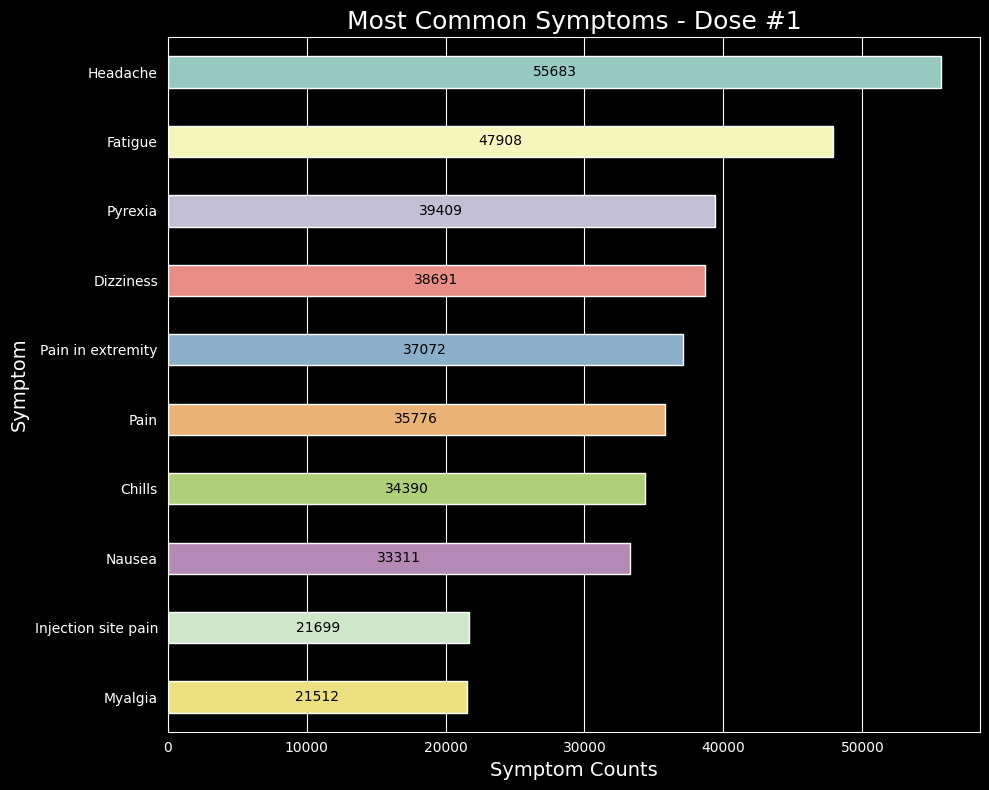

In [200]:
# plot 10 most common symptoms dose #1

# bar chart
fig, ax = plt.subplots(figsize=(10, 8))
most_common_symptoms_dose1 = sns.barplot(data=df_symptom_counts14[0:10], x="count", y="symptom", hue='symptom', width=0.5, gap=0.1)

for container in ax.containers:
    ax.bar_label(container, fontsize=10, label_type='center', color='black')

ax.set_xlabel('Symptom Counts', fontsize=14)
ax.set_ylabel('Symptom', fontsize=14)
ax.set_title('Most Common Symptoms - Dose #1', fontsize=18)

plt.tight_layout()
plt.show()

fig.savefig('visualizations/dose1/most_common_symptoms_dose1.png')

### Most common symptoms dose1 Ages 0-50

In [201]:
VAERS_dose1_symptoms_0_50 = VAERS_dose1_symptoms[VAERS_dose1_symptoms['AGE_YRS'] < 51]

symptom_counts15 = VAERS_dose1_symptoms_0_50['symptom'].value_counts()
df_symptom_counts15 = symptom_counts15.to_frame()
df_symptom_counts15[0:10]

,count
symptom,
Headache,26739
Dizziness,23263
Fatigue,22679
Pyrexia,18576
Nausea,17863
Pain,17776
Pain in extremity,16169
Chills,15623
Injection site pain,12111


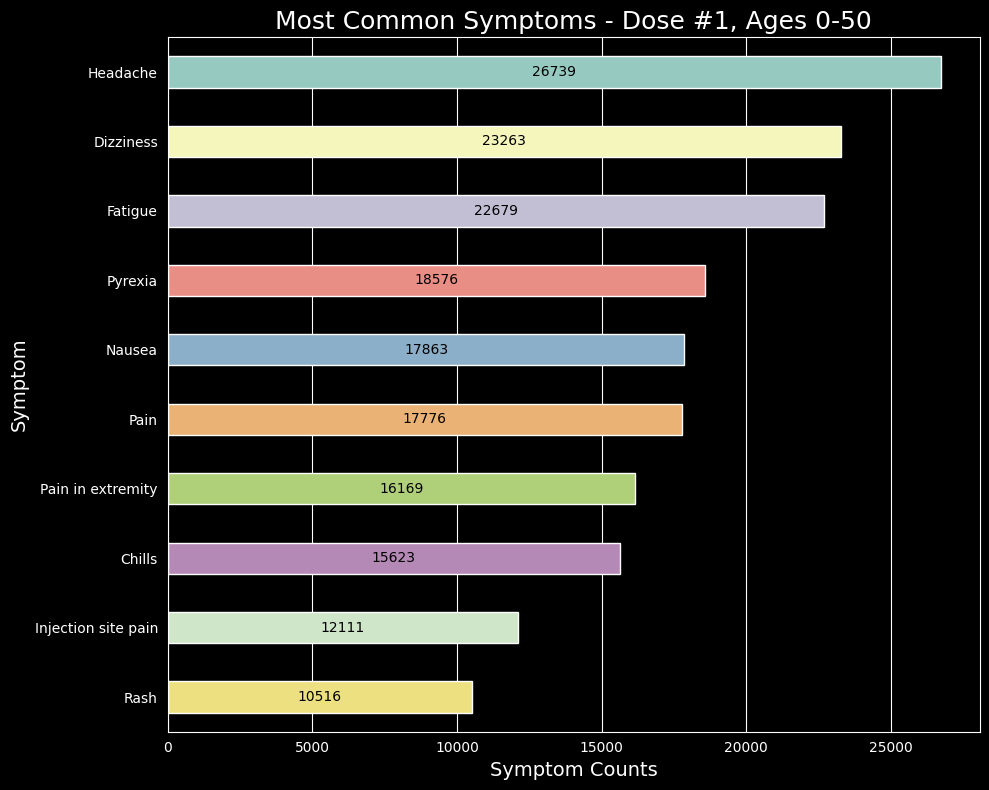

In [202]:
# plot 10 most common symptoms WA State

# bar chart
fig, ax = plt.subplots(figsize=(10, 8))
most_common_symptoms_dose1_0_50 = sns.barplot(data=df_symptom_counts15[0:10], x="count", y="symptom", hue='symptom', width=0.5, gap=0.1)

for container in ax.containers:
    ax.bar_label(container, fontsize=10, label_type='center', color='black')

ax.set_xlabel('Symptom Counts', fontsize=14)
ax.set_ylabel('Symptom', fontsize=14)
ax.set_title('Most Common Symptoms - Dose #1, Ages 0-50', fontsize=18)

plt.tight_layout()
plt.show()

fig.savefig('visualizations/dose1/most_common_symptoms_dose1_ages0_50.png')

### Most common symptoms dose1 Ages 51-up

In [203]:
VAERS_dose1_symptoms_51_up = VAERS_dose1_symptoms[VAERS_dose1_symptoms['AGE_YRS'] >= 51]

symptom_counts16 = VAERS_dose1_symptoms_51_up['symptom'].value_counts()
df_symptom_counts16 = symptom_counts16.to_frame()
df_symptom_counts16[0:10]

,count
symptom,
Headache,24754
Fatigue,21830
Pain in extremity,17278
Pyrexia,17244
Chills,16163
Pain,15692
Dizziness,13649
Nausea,13584
Arthralgia,10398


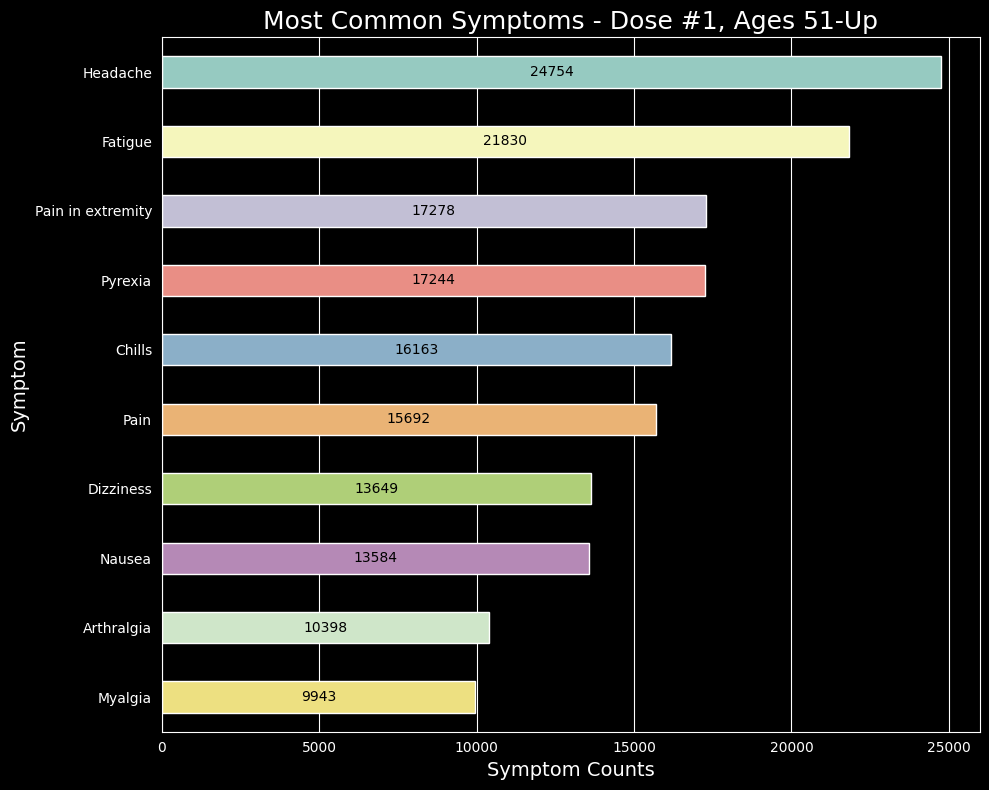

In [204]:
# plot 10 most common symptoms dose 1 - ages 51-up

# bar chart
fig, ax = plt.subplots(figsize=(10, 8))
most_common_symptoms_dose1_51_up = sns.barplot(data=df_symptom_counts16[0:10], x="count", y="symptom", hue='symptom', width=0.5, gap=0.1)

for container in ax.containers:
    ax.bar_label(container, fontsize=10, label_type='center', color='black')

ax.set_xlabel('Symptom Counts', fontsize=14)
ax.set_ylabel('Symptom', fontsize=14)
ax.set_title('Most Common Symptoms - Dose #1, Ages 51-Up', fontsize=18)

plt.tight_layout()
plt.show()

fig.savefig('visualizations/dose1/most_common_symptoms_dose1_51-up.png')

### Most common symptoms dose1 female

In [205]:
VAERS_dose1_symptoms_F = VAERS_dose1_symptoms[VAERS_dose1_symptoms['SEX'] == 'F']

symptom_counts17 = VAERS_dose1_symptoms_F['symptom'].value_counts()
df_symptom_counts17 = symptom_counts17.to_frame()
df_symptom_counts17[0:10]

,count
symptom,
Headache,42421
Fatigue,35632
Pain in extremity,28556
Pyrexia,27700
Dizziness,27560
Pain,27131
Nausea,25975
Chills,24959
Pruritus,17792


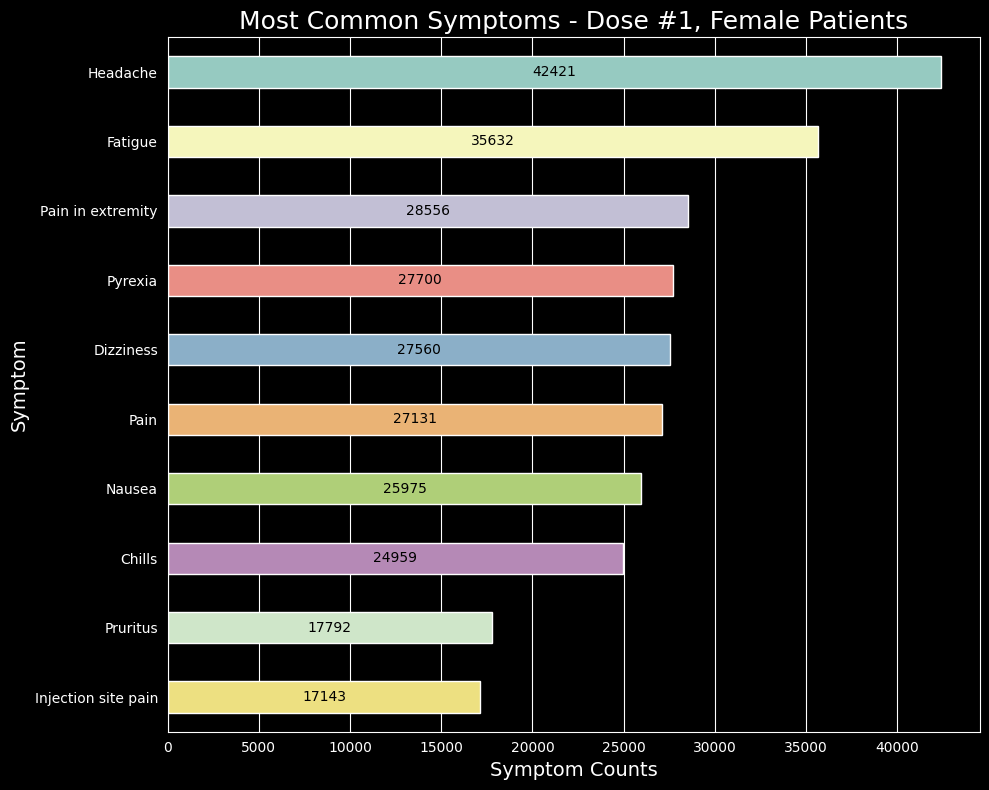

In [207]:
# plot 10 most common symptoms for dose 1 - female

# bar chart
fig, ax = plt.subplots(figsize=(10, 8))
most_common_symptoms_dose1_F = sns.barplot(data=df_symptom_counts17[0:10], x="count", y="symptom", hue='symptom', width=0.5, gap=0.1)

for container in ax.containers:
    ax.bar_label(container, fontsize=10, label_type='center', color='black')

ax.set_xlabel('Symptom Counts', fontsize=14)
ax.set_ylabel('Symptom', fontsize=14)
ax.set_title('Most Common Symptoms - Dose #1, Female Patients', fontsize=18)

plt.tight_layout()
plt.show()

fig.savefig('visualizations/dose1/most_common_symptoms_dose1_F.png')

### Most common symptoms dose1 male

In [206]:
VAERS_dose1_symptoms_M = VAERS_dose1_symptoms[VAERS_dose1_symptoms['SEX'] == 'M']

symptom_counts18 = VAERS_dose1_symptoms_M['symptom'].value_counts()
df_symptom_counts18 = symptom_counts18.to_frame()
df_symptom_counts18[0:10]

,count
symptom,
Headache,12285
Fatigue,11404
Pyrexia,10861
Dizziness,10661
Chills,8903
Pain,8171
Pain in extremity,7898
Nausea,6875
Myalgia,5875


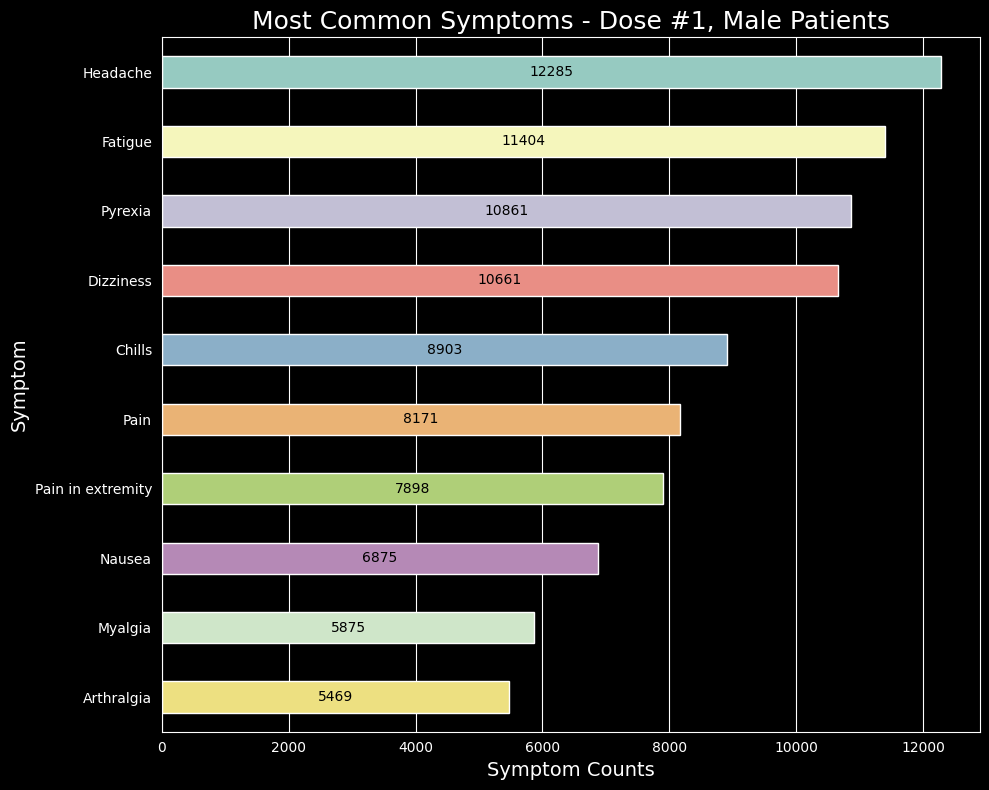

In [208]:
# plot 10 most common symptoms dose 1 - male

# bar chart
fig, ax = plt.subplots(figsize=(10, 8))
most_common_symptoms_dose1_M = sns.barplot(data=df_symptom_counts18[0:10], x="count", y="symptom", hue='symptom', width=0.5, gap=0.1)

for container in ax.containers:
    ax.bar_label(container, fontsize=10, label_type='center', color='black')

ax.set_xlabel('Symptom Counts', fontsize=14)
ax.set_ylabel('Symptom', fontsize=14)
ax.set_title('Most Common Symptoms - Dose #1, Male Patients', fontsize=18)

plt.tight_layout()
plt.show()

fig.savefig('visualizations/dose1/most_common_symptoms_dose1_M.png')

## 1 Dose - frequency of reports over time

In [209]:
VAERS_dose1.head()

,VAERS_ID,RECVDATE,STATE,AGE_YRS,SEX,RPT_DATE,DIED,DATEDIED,L_THREAT,ER_VISIT,...,BIRTH_DEFECT,OFC_VISIT,ER_ED_VISIT,VAX_TYPE,VAX_MANU,VAX_LOT,VAX_DOSE_SERIES,VAX_ROUTE,VAX_SITE,VAX_NAME
0,902418,2020-12-15,NJ,56.0,F,NaT,N,NaT,N,N,...,N,N,N,COVID19,PFIZER\BIONTECH,EH9899,1.0,IM,LA,PFIZER-BIONTECH
1,902440,2020-12-15,AZ,35.0,F,NaT,N,NaT,N,N,...,N,N,N,COVID19,PFIZER\BIONTECH,EH9899,1.0,SYR,LA,PFIZER-BIONTECH
2,902446,2020-12-15,WV,55.0,F,NaT,N,NaT,N,N,...,N,N,N,COVID19,PFIZER\BIONTECH,EH9899,1.0,IM,RA,PFIZER-BIONTECH
4,902465,2020-12-15,AR,60.0,F,NaT,N,NaT,N,N,...,N,N,N,COVID19,PFIZER\BIONTECH,EH9899,1.0,IM,RA,PFIZER-BIONTECH
5,902468,2020-12-15,NaN,59.0,M,NaT,N,NaT,N,N,...,N,N,Y,COVID19,PFIZER\BIONTECH,EH9899,1.0,IM,LA,PFIZER-BIONTECH


In [210]:
# add column to line1 with MonthYear object
import datetime
VAERS_dose1['ONSET_YEAR'] = VAERS_dose1['ONSET_DATE'].dt.year
VAERS_dose1['ONSET_MONTH'] = VAERS_dose1['ONSET_DATE'].dt.strftime('%b')
VAERS_dose1['ONSET_MONTHYEAR'] = VAERS_dose1['ONSET_DATE'].dt.strftime('%Y-%m')

In [213]:
# create grouped bar chart
VAERS_dose1_grouped = VAERS_dose1.groupby(by=["ONSET_MONTHYEAR"]).agg(report_count=("VAERS_ID", 'count'))
# display(VAERS_dose1_grouped)

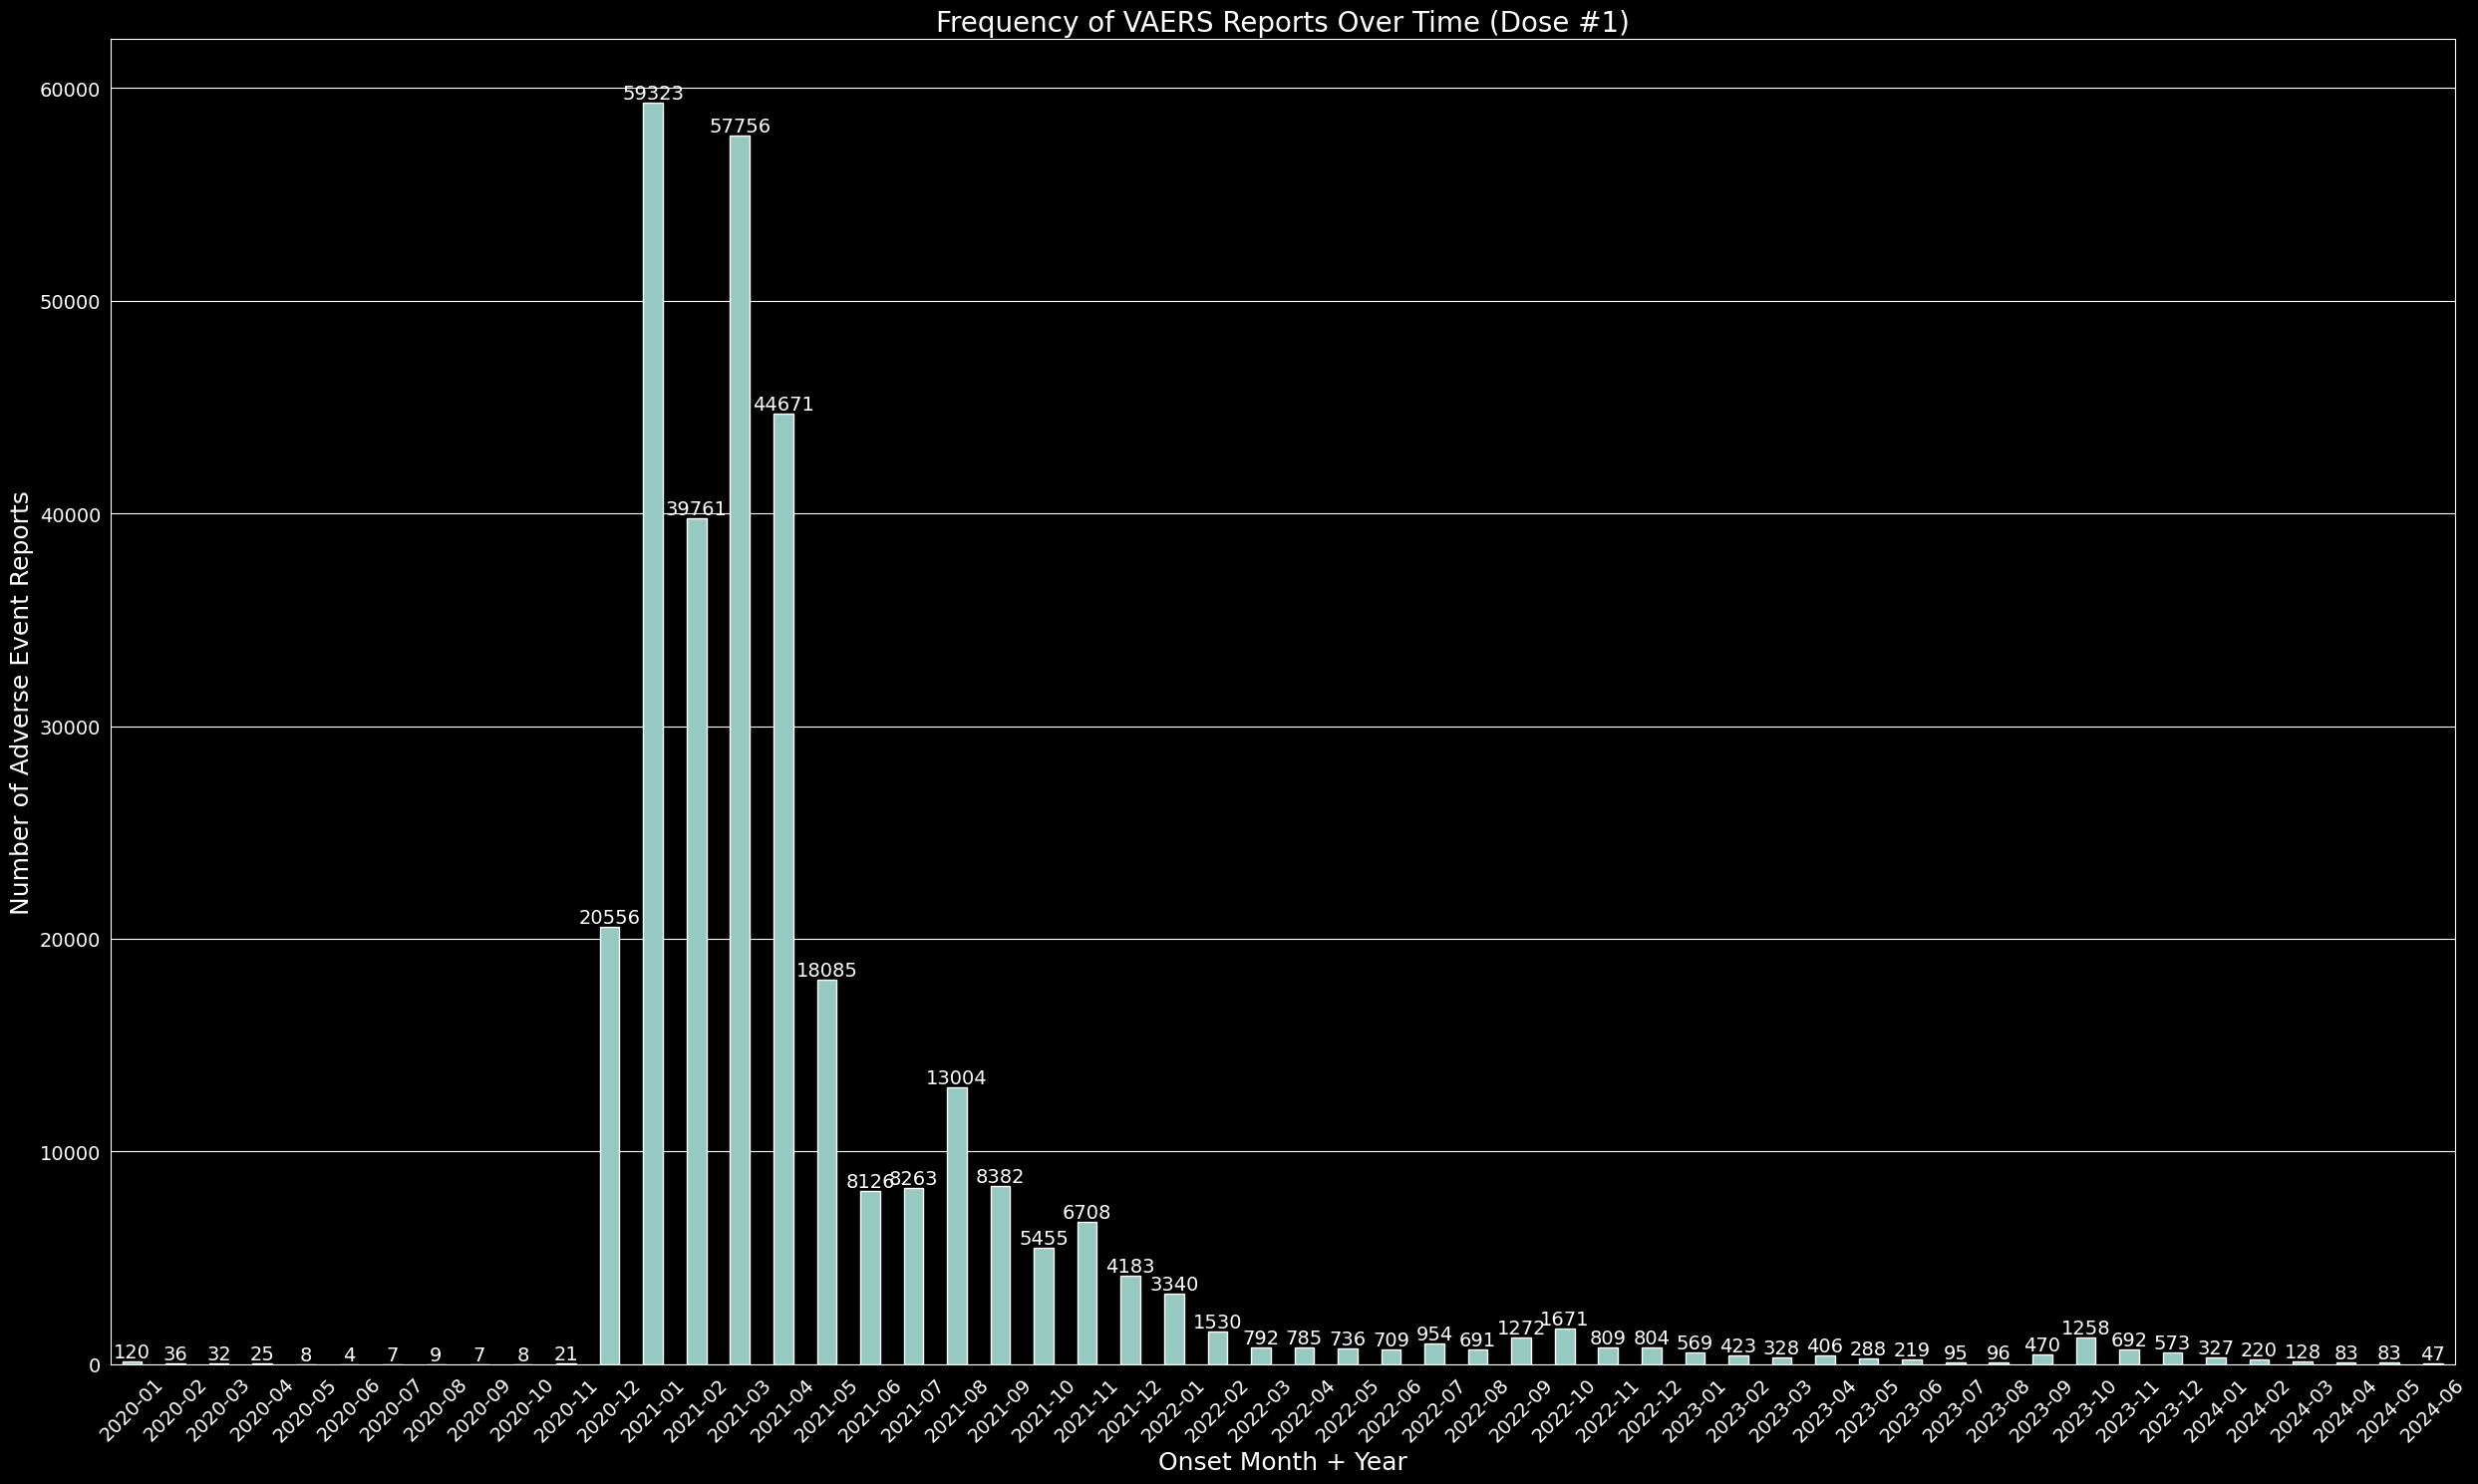

In [214]:
# bar chart
fig, ax = plt.subplots(figsize=(25, 15))
frequency_reports_over_time_dose1 = sns.barplot(data=VAERS_dose1_grouped, x="ONSET_MONTHYEAR", y="report_count", width=0.5, gap=0.1)

for container in ax.containers:
    ax.bar_label(container, fontsize=14)
ax.set_xlabel('Onset Month + Year', fontsize=18)
ax.tick_params("x", rotation=45)
ax.tick_params(axis='both', which='major', labelsize=14)
ax.tick_params(axis='both', which='minor', labelsize=14)
ax.set_ylabel('Number of Adverse Event Reports', fontsize=18)
ax.set_title('Frequency of VAERS Reports Over Time (Dose #1)', fontsize=20)

plt.tight_layout()
plt.show()

fig.savefig("visualizations/dose1/frequency_reports_over_time_dose1.png")

# KPIs

KPI checklist
- Total adverse events in [Month]
- % change in # adverse events (month)
- % reports where deaths were reported

## Total adverse events in December 2020

In [81]:
df_symptoms_VAERS_merged.head()

,VAERS_ID,symptom,symptom_version,symptom_dict,VAX_TYPE_x,VAX_MANU_x,VAX_LOT_x,VAX_DOSE_SERIES_x,VAX_ROUTE_x,VAX_SITE_x,...,VAX_TYPE_y,VAX_MANU_y,VAX_LOT_y,VAX_DOSE_SERIES_y,VAX_ROUTE_y,VAX_SITE_y,VAX_NAME_y,ONSET_YEAR,ONSET_MONTH,MONTH_YEAR
0,902418,Hypoaesthesia,24.0,"{'SYMPTOM1': 'Hypoaesthesia', 'SYMPTOMVERSION1...",COVID19,PFIZER\BIONTECH,EH9899,1.0,IM,LA,...,COVID19,PFIZER\BIONTECH,EH9899,1.0,IM,LA,PFIZER-BIONTECH,2020.0,Dec,2020-12
1,902440,Headache,23.1,"{'SYMPTOM1': 'Headache', 'SYMPTOMVERSION1': 23.1}",COVID19,PFIZER\BIONTECH,EH9899,1.0,SYR,LA,...,COVID19,PFIZER\BIONTECH,EH9899,1.0,SYR,LA,PFIZER-BIONTECH,2020.0,Dec,2020-12
2,902446,Erythema,23.1,"{'SYMPTOM1': 'Erythema', 'SYMPTOMVERSION1': 23.1}",COVID19,PFIZER\BIONTECH,EH9899,1.0,IM,RA,...,COVID19,PFIZER\BIONTECH,EH9899,1.0,IM,RA,PFIZER-BIONTECH,2020.0,Dec,2020-12
3,902464,Dizziness,23.1,"{'SYMPTOM1': 'Dizziness', 'SYMPTOMVERSION1': 2...",COVID19,PFIZER\BIONTECH,EH9899,NaN,IM,LA,...,COVID19,PFIZER\BIONTECH,EH9899,NaN,IM,LA,PFIZER-BIONTECH,2020.0,Dec,2020-12
4,902465,Dysgeusia,23.1,"{'SYMPTOM1': 'Dysgeusia', 'SYMPTOMVERSION1': 2...",COVID19,PFIZER\BIONTECH,EH9899,1.0,IM,RA,...,COVID19,PFIZER\BIONTECH,EH9899,1.0,IM,RA,PFIZER-BIONTECH,2020.0,Dec,2020-12


In [82]:
print(type(df_symptoms_VAERS_merged['ONSET_DATE'][0]))

<class 'pandas.Timestamp'>


In [83]:
df_symptoms_VAERS_merged['ONSET_YEAR'] = df_symptoms_VAERS_merged['ONSET_DATE'].dt.year
df_symptoms_VAERS_merged['ONSET_MONTH'] = df_symptoms_VAERS_merged['ONSET_DATE'].dt.strftime('%b')
df_symptoms_VAERS_merged['MONTH_YEAR'] = df_symptoms_VAERS_merged['ONSET_DATE'].dt.strftime('%Y-%m')

df_symptoms_VAERS_merged.head()

,VAERS_ID,symptom,symptom_version,symptom_dict,VAX_TYPE_x,VAX_MANU_x,VAX_LOT_x,VAX_DOSE_SERIES_x,VAX_ROUTE_x,VAX_SITE_x,...,VAX_TYPE_y,VAX_MANU_y,VAX_LOT_y,VAX_DOSE_SERIES_y,VAX_ROUTE_y,VAX_SITE_y,VAX_NAME_y,ONSET_YEAR,ONSET_MONTH,MONTH_YEAR
0,902418,Hypoaesthesia,24.0,"{'SYMPTOM1': 'Hypoaesthesia', 'SYMPTOMVERSION1...",COVID19,PFIZER\BIONTECH,EH9899,1.0,IM,LA,...,COVID19,PFIZER\BIONTECH,EH9899,1.0,IM,LA,PFIZER-BIONTECH,2020.0,Dec,2020-12
1,902440,Headache,23.1,"{'SYMPTOM1': 'Headache', 'SYMPTOMVERSION1': 23.1}",COVID19,PFIZER\BIONTECH,EH9899,1.0,SYR,LA,...,COVID19,PFIZER\BIONTECH,EH9899,1.0,SYR,LA,PFIZER-BIONTECH,2020.0,Dec,2020-12
2,902446,Erythema,23.1,"{'SYMPTOM1': 'Erythema', 'SYMPTOMVERSION1': 23.1}",COVID19,PFIZER\BIONTECH,EH9899,1.0,IM,RA,...,COVID19,PFIZER\BIONTECH,EH9899,1.0,IM,RA,PFIZER-BIONTECH,2020.0,Dec,2020-12
3,902464,Dizziness,23.1,"{'SYMPTOM1': 'Dizziness', 'SYMPTOMVERSION1': 2...",COVID19,PFIZER\BIONTECH,EH9899,NaN,IM,LA,...,COVID19,PFIZER\BIONTECH,EH9899,NaN,IM,LA,PFIZER-BIONTECH,2020.0,Dec,2020-12
4,902465,Dysgeusia,23.1,"{'SYMPTOM1': 'Dysgeusia', 'SYMPTOMVERSION1': 2...",COVID19,PFIZER\BIONTECH,EH9899,1.0,IM,RA,...,COVID19,PFIZER\BIONTECH,EH9899,1.0,IM,RA,PFIZER-BIONTECH,2020.0,Dec,2020-12


In [105]:
# get groupby objects

# all events
df_KPI_grouped = df_symptoms_VAERS_merged.groupby(by=["MONTH_YEAR"]).agg(report_count=("VAERS_ID", 'count'))
df_KPI_grouped = df_KPI_grouped.reset_index()

# just Pfizer
Pfizer_only = df_symptoms_VAERS_merged[df_symptoms_VAERS_merged['VAX_MANU_x'] == 'PFIZER\\BIONTECH']
df_KPI_grouped1 = Pfizer_only.groupby(by=['MONTH_YEAR']).agg(report_count=('VAERS_ID','count'))
df_KPI_grouped1 = df_KPI_grouped1.reset_index()

# just Moderna
Moderna_only = df_symptoms_VAERS_merged[df_symptoms_VAERS_merged['VAX_MANU_x'] == 'MODERNA']
df_KPI_grouped2 = Moderna_only.groupby(by=['MONTH_YEAR']).agg(report_count=('VAERS_ID','count'))
df_KPI_grouped2 = df_KPI_grouped2.reset_index()

# just Washington State
WA_state_only = df_symptoms_VAERS_merged[df_symptoms_VAERS_merged['STATE'] == 'WA']
df_KPI_grouped3 = WA_state_only.groupby(by=['MONTH_YEAR']).agg(report_count=('VAERS_ID','count'))
df_KPI_grouped3 = df_KPI_grouped3.reset_index()

# just 1 dose
dose1_only = df_symptoms_VAERS_merged[df_symptoms_VAERS_merged['VAX_DOSE_SERIES_x'] == 1]
df_KPI_grouped4 = dose1_only.groupby(by=['MONTH_YEAR']).agg(report_count=('VAERS_ID','count'))
df_KPI_grouped4 = df_KPI_grouped4.reset_index()

In [106]:
# calculate total adverse events in December 2020 (both Pfizer & Moderna)
total_events_202011 = df_KPI_grouped[df_KPI_grouped['MONTH_YEAR'] == '2020-11']
total_events_202012 = df_KPI_grouped[df_KPI_grouped['MONTH_YEAR'] == '2020-12']

# calculate total adverse events in December 2020 (Pfizer only)
Pfizer_events_202011 = df_KPI_grouped1[df_KPI_grouped1['MONTH_YEAR'] == '2020-11']
Pfizer_events_202012 = df_KPI_grouped1[df_KPI_grouped1['MONTH_YEAR'] == '2020-12']

# calculate total adverse events in December 2020 (Moderna only)
Moderna_events_202011 = df_KPI_grouped2[df_KPI_grouped2['MONTH_YEAR'] == '2020-11']
Moderna_events_202012 = df_KPI_grouped2[df_KPI_grouped2['MONTH_YEAR'] == '2020-12']

# calculate total adverse events in December 2020 (WA State only)
WA_events_202011 = df_KPI_grouped3[df_KPI_grouped3['MONTH_YEAR'] == '2020-11']
WA_events_202012 = df_KPI_grouped3[df_KPI_grouped3['MONTH_YEAR'] == '2020-12']

# calculate total adverse events in December 2020 (1 dose only)
dose1_events_202011 = df_KPI_grouped4[df_KPI_grouped4['MONTH_YEAR'] == '2020-11']
dose1_events_202012 = df_KPI_grouped4[df_KPI_grouped4['MONTH_YEAR'] == '2020-12']

In [107]:
WA_events_202011

,MONTH_YEAR,report_count


In [108]:
# print results
print("Total events 2020-11: ", total_events_202011.at[10,'report_count'])
print("Total events 2020-12: ", total_events_202012.at[11, 'report_count'])
print("Total events 2020-11, Pfizer: ", Pfizer_events_202011.at[10, 'report_count'])
print("Total events 2020-12, Pfizer: ", Pfizer_events_202012.at[11, 'report_count'])
print("Total events 2020-11, Moderna: ", Moderna_events_202011.at[10, 'report_count'])
print("Total events 2020-12, Moderna: ", Moderna_events_202012.at[11, 'report_count'])
print("Total events 2020-11, WA: ", '0')
print("Total events 2020-12, WA: ", WA_events_202012.at[4, 'report_count'])
print("Total events 2020-11, 1 dose: ", dose1_events_202011.at[10, 'report_count'])
print("Total events 2020-12, 1 dose: ", dose1_events_202012.at[11, 'report_count'])

Total events 2020-11:  280
Total events 2020-12:  113245
Total events 2020-11, Pfizer:  180
Total events 2020-12, Pfizer:  63634
Total events 2020-11, Moderna:  100
Total events 2020-12, Moderna:  49611
Total events 2020-11, WA:  0
Total events 2020-12, WA:  2303
Total events 2020-11, 1 dose:  133
Total events 2020-12, 1 dose:  92741


## Total adverse events where patients died December 2020

In [109]:
# filter for patient deaths
df_patients_died = df_symptoms_VAERS_merged[df_symptoms_VAERS_merged['DIED'] == 'Y']

In [110]:
print(df_patients_died['DIED'].unique().tolist())

['Y']


In [111]:
# get groupby objects

# all events
df_died_grouped = df_patients_died.groupby(by=["MONTH_YEAR"]).agg(report_count=("VAERS_ID", 'count'))
df_died_grouped = df_died_grouped.reset_index()

# just Pfizer
Pfizer_died = df_patients_died[df_patients_died['VAX_MANU_x'] == 'PFIZER\\BIONTECH']
df_died_grouped1 = Pfizer_died.groupby(by=['MONTH_YEAR']).agg(report_count=('VAERS_ID','count'))
df_died_grouped1 = df_died_grouped1.reset_index()

# just Moderna
Moderna_died = df_patients_died[df_patients_died['VAX_MANU_x'] == 'MODERNA']
df_died_grouped2 = Moderna_died.groupby(by=['MONTH_YEAR']).agg(report_count=('VAERS_ID','count'))
df_died_grouped2 = df_died_grouped2.reset_index()

# just Washington State
WA_state_died = df_patients_died[df_patients_died['STATE'] == 'WA']
df_died_grouped3 = WA_state_died.groupby(by=['MONTH_YEAR']).agg(report_count=('VAERS_ID','count'))
df_died_grouped3 = df_died_grouped3.reset_index()

# just 1 dose
dose1_died = df_patients_died[df_patients_died['VAX_DOSE_SERIES_x'] == 1]
df_died_grouped4 = dose1_died.groupby(by=['MONTH_YEAR']).agg(report_count=('VAERS_ID','count'))
df_died_grouped4 = df_died_grouped4.reset_index()

In [112]:
# calculate adverse events where patients died in December 2020

# (both Pfizer & Moderna)
total_died_202011 = df_died_grouped[df_died_grouped['MONTH_YEAR'] == '2020-11']
total_died_202012 = df_died_grouped[df_died_grouped['MONTH_YEAR'] == '2020-12']

# Pfizer only
Pfizer_died_202011 = df_died_grouped1[df_died_grouped1['MONTH_YEAR'] == '2020-11']
Pfizer_died_202012 = df_died_grouped1[df_died_grouped1['MONTH_YEAR'] == '2020-12']

# Moderna only
Moderna_died_202011 = df_died_grouped2[df_died_grouped2['MONTH_YEAR'] == '2020-11']
Moderna_died_202012 = df_died_grouped2[df_died_grouped2['MONTH_YEAR'] == '2020-12']

# calculate total adverse events in December 2020 (WA State only)
WA_died_202011 = df_died_grouped3[df_died_grouped3['MONTH_YEAR'] == '2020-11']
WA_died_202012 = df_died_grouped3[df_died_grouped3['MONTH_YEAR'] == '2020-12']

# calculate total adverse events in December 2020 (1 dose only)
dose1_died_202011 = df_died_grouped4[df_died_grouped4['MONTH_YEAR'] == '2020-11']
dose1_died_202012 = df_died_grouped4[df_died_grouped4['MONTH_YEAR'] == '2020-12']

In [113]:
dose1_died_202012

,MONTH_YEAR,report_count
1,2020-12,313


In [114]:
# print results
print("Total died 2020-11: ", "0")
print("Total died 2020-12: ", total_died_202012.at[4, 'report_count'])
print("Total died 2020-11, Pfizer: ", "0")
print("Total died 2020-12, Pfizer: ", Pfizer_died_202012.at[4, 'report_count'])
print("Total died 2020-11, Moderna: ", "0")
print("Total died 2020-12, Moderna: ", Moderna_died_202012.at[0, 'report_count'])
print("Total died 2020-11, WA: ", '0')
print("Total died 2020-12, WA: ", WA_died_202012.at[0, 'report_count'])
print("Total died 2020-11, 1 dose: ", "0")
print("Total died 2020-12, 1 dose: ", dose1_died_202012.at[1, 'report_count'])

Total died 2020-11:  0
Total died 2020-12:  404
Total died 2020-11, Pfizer:  0
Total died 2020-12, Pfizer:  190
Total died 2020-11, Moderna:  0
Total died 2020-12, Moderna:  214
Total died 2020-11, WA:  0
Total died 2020-12, WA:  1
Total died 2020-11, 1 dose:  0
Total died 2020-12, 1 dose:  313


In [115]:
# print results
print("Total events 2020-12: ", )
print("Total events 2020-12, Pfizer: ", )
print("Total events 2020-11, Moderna: ", )
print("Total events 2020-12, Moderna: ", )
print("Total events 2020-11, WA: ", )
print("Total events 2020-12, WA: ", )
print("Total events 2020-11, 1 dose: ", )
print("Total events 2020-12, 1 dose: ", )

Total events 2020-12: 
Total events 2020-12, Pfizer: 
Total events 2020-11, Moderna: 
Total events 2020-12, Moderna: 
Total events 2020-11, WA: 
Total events 2020-12, WA: 
Total events 2020-11, 1 dose: 
Total events 2020-12, 1 dose: 


In [116]:
# create dataframe with results
# KPI_results = pd.DataFrame()

col_202011_all = [total_events_202011.at[10,'report_count'],
                  '0',
                  Pfizer_events_202011.at[10, 'report_count'],
                  '0',
                  Moderna_events_202011.at[10, 'report_count'],
                  '0',
                  '0',
                  '0',
                  dose1_events_202011.at[10, 'report_count'],
                  '0']
col_202012_all = [total_events_202012.at[11, 'report_count'],
                  total_died_202012.at[4, 'report_count'],
                  Pfizer_events_202012.at[11, 'report_count'],
                  Pfizer_died_202012.at[4, 'report_count'],
                  Moderna_events_202012.at[11, 'report_count'],
                  Moderna_died_202012.at[0, 'report_count'],
                  WA_events_202012.at[4, 'report_count'],
                  WA_died_202012.at[0, 'report_count'],
                  dose1_events_202012.at[11, 'report_count'],
                  dose1_died_202012.at[1, 'report_count']]

KPIs = {"2020-11": pd.Series(col_202011_all, index=["All",
                                                    "All-died",
                                                    "Pfizer",
                                                    "Pfizer-died",
                                                    "Moderna",
                                                    "Moderna-died",
                                                    "WA",
                                                    "WA-died",
                                                    "Dose1",
                                                    "Dose1-died"]),
        "2020-12": pd.Series(col_202012_all, index=["All",
                                                    "All-died",
                                                    "Pfizer",
                                                    "Pfizer-died",
                                                    "Moderna",
                                                    "Moderna-died",
                                                    "WA",
                                                    "WA-died",
                                                    "Dose1",
                                                    "Dose1-died"])}

KPIs_df = pd.DataFrame(data=KPIs)
KPIs_df

# d = {"col1": [1, 2], "col2": [3, 4]}
# df = pd.DataFrame(data=d)
# df

,2020-11,2020-12
All,280,113245
All-died,0,404
Pfizer,180,63634
Pfizer-died,0,190
Moderna,100,49611
Moderna-died,0,214
WA,0,2303
WA-died,0,1
Dose1,133,92741
Dose1-died,0,313


In [145]:
# percent change calculator

def percent_change (val1, val2):
    percent_change = ((val2 - val1) / abs(val1))*100
    return percent_change

KPIs_df['2020-11'] = KPIs_df['2020-11'].astype('int64')
KPIs_df['2020-12'] = KPIs_df['2020-12'].astype('int64')

In [118]:
KPIs_df['percent_change'] = percent_change(KPIs_df['2020-11'], KPIs_df['2020-12'])

In [119]:
KPIs_df

,2020-11,2020-12,percent_change
All,280,113245,4.034464e+04
All-died,0,404,inf
Pfizer,180,63634,3.525222e+04
Pfizer-died,0,190,inf
Moderna,100,49611,4.951100e+04
Moderna-died,0,214,inf
WA,0,2303,inf
WA-died,0,1,inf
Dose1,133,92741,6.963008e+04
Dose1-died,0,313,inf


In [120]:
# all
percent_died_2020_11 = (0/280)*100
percent_died_2020_12 = (404/113245)*100
print(percent_died_2020_11)
print(percent_died_2020_12)

# Pfizer
pfizer_died_2020_11 = (0/180)*100
pfizer_died_2020_12 = (190/63634)*100
print(pfizer_died_2020_11)
print(pfizer_died_2020_12)

# Moderna
moderna_died_2020_11 = (0/100)*100
moderna_died_2020_12 = (214/49611)*100
print(moderna_died_2020_11)
print(moderna_died_2020_12)

# WA
WA_died_2020_11 = (0)*100
WA_died_2020_12 = (1/2303)*100
print(WA_died_2020_11)
print(WA_died_2020_12)

# dose1
dose1_died_2020_11 = (0/133)*100
dose1_died_2020_12 = (313/92741)*100
print(dose1_died_2020_11)
print(dose1_died_2020_12)

0.0
0.3567486423241644
0.0
0.29858251877926895
0.0
0.43135594928544074
0
0.04342162396873643
0.0
0.33749905651222223


## Total Adverse Events where Patients were Hospitalized

In [100]:
# filter for patient hospitaliations
df_patients_hosp = df_symptoms_VAERS_merged[df_symptoms_VAERS_merged['HOSPITAL'] == 'Y']

In [101]:
print(df_patients_hosp['HOSPITAL'].unique().tolist())

['Y']


In [102]:
# get groupby objects

# all events
df_hosp_grouped = df_patients_hosp.groupby(by=["MONTH_YEAR"]).agg(report_count=("VAERS_ID", 'count'))
df_hosp_grouped = df_hosp_grouped.reset_index()

# just Pfizer
Pfizer_hosp = df_patients_hosp[df_patients_hosp['VAX_MANU_x'] == 'PFIZER\\BIONTECH']
df_hosp1_grouped = Pfizer_hosp.groupby(by=['MONTH_YEAR']).agg(report_count=('VAERS_ID','count'))
df_hosp1_grouped = df_hosp1_grouped.reset_index()

# just Moderna
Moderna_hosp = df_patients_hosp[df_patients_hosp['VAX_MANU_x'] == 'MODERNA']
df_hosp2_grouped = Moderna_hosp.groupby(by=['MONTH_YEAR']).agg(report_count=('VAERS_ID','count'))
df_hosp2_grouped = df_hosp2_grouped.reset_index()

# just Washington State
WA_state_hosp = df_patients_hosp[df_patients_hosp['STATE'] == 'WA']
df_hosp3_grouped = WA_state_hosp.groupby(by=['MONTH_YEAR']).agg(report_count=('VAERS_ID','count'))
df_hosp3_grouped = df_hosp3_grouped.reset_index()

# just 1 dose
dose1_hosp = df_patients_hosp[df_patients_hosp['VAX_DOSE_SERIES_x'] == 1]
df_hosp4_grouped = dose1_hosp.groupby(by=['MONTH_YEAR']).agg(report_count=('VAERS_ID','count'))
df_hosp4_grouped = df_hosp4_grouped.reset_index()

In [127]:
# calculate adverse events where patients died in December 2020

# (both Pfizer & Moderna)
total_hosp_202011 = df_hosp_grouped[df_hosp_grouped['MONTH_YEAR'] == '2020-11']
total_hosp_202011 = total_hosp_202011.reset_index()
total_hosp_202012 = df_hosp_grouped[df_hosp_grouped['MONTH_YEAR'] == '2020-12']
total_hosp_202012 = total_hosp_202012.reset_index()

# Pfizer only
Pfizer_hosp_202011 = df_hosp1_grouped[df_hosp1_grouped['MONTH_YEAR'] == '2020-11']
Pfizer_hosp_202011 = Pfizer_hosp_202011.reset_index()
Pfizer_hosp_202012 = df_hosp1_grouped[df_hosp1_grouped['MONTH_YEAR'] == '2020-12']
Pfizer_hosp_202012 = Pfizer_hosp_202012.reset_index()

# Moderna only
Moderna_hosp_202011 = df_hosp2_grouped[df_hosp2_grouped['MONTH_YEAR'] == '2020-11']
Moderna_hosp_202011 = Moderna_hosp_202011.reset_index()
Moderna_hosp_202012 = df_hosp2_grouped[df_hosp2_grouped['MONTH_YEAR'] == '2020-12']
Moderna_hosp_202012 = Moderna_hosp_202012.reset_index()

# calculate total adverse events in December 2020 (WA State only)
WA_hosp_202011 = df_hosp3_grouped[df_hosp3_grouped['MONTH_YEAR'] == '2020-11']
WA_hosp_202011 = WA_hosp_202011.reset_index()
WA_hosp_202012 = df_hosp3_grouped[df_hosp3_grouped['MONTH_YEAR'] == '2020-12']
WA_hosp_202012 = WA_hosp_202012.reset_index()

# calculate total adverse events in December 2020 (1 dose only)
dose1_hosp_202011 = df_hosp4_grouped[df_hosp4_grouped['MONTH_YEAR'] == '2020-11']
dose1_hosp_202011 = dose1_hosp_202011.reset_index()
dose1_hosp_202012 = df_hosp4_grouped[df_hosp4_grouped['MONTH_YEAR'] == '2020-12']
dose1_hosp_202012 = dose1_hosp_202012.reset_index()

In [137]:
WA_hosp_202011

,index,MONTH_YEAR,report_count


In [138]:
KPIs_df

,2020-11,2020-12,percent_change
All,280,113245,4.034464e+04
All-died,0,404,inf
Pfizer,180,63634,3.525222e+04
Pfizer-died,0,190,inf
Moderna,100,49611,4.951100e+04
Moderna-died,0,214,inf
WA,0,2303,inf
WA-died,0,1,inf
Dose1,133,92741,6.963008e+04
Dose1-died,0,313,inf


In [139]:
# add results to KPIs dataframe

hosp_indices = ['All_hosp', 'Pfizer_hosp', 'Moderna_hosp', 'WA_hosp', 'Dose1_hosp']

cols_202011_hosp = [total_hosp_202011.at[0, 'report_count'],
                    Pfizer_hosp_202011.at[0, 'report_count'],
                    Moderna_hosp_202011.at[0, 'report_count'],
                    '0',
                    dose1_hosp_202011.at[0, 'report_count']
]

cols_202012_hosp = [total_hosp_202012.at[0, 'report_count'],
                    Pfizer_hosp_202012.at[0, 'report_count'],
                    Moderna_hosp_202012.at[0, 'report_count'],
                    WA_hosp_202012.at[0, 'report_count'],
                    dose1_hosp_202012.at[0, 'report_count']
]

In [140]:
KPIs_hosp = {"2020-11": pd.Series(cols_202011_hosp, index=['All_hosp',
                                                           'Pfizer_hosp',
                                                           'Moderna_hosp',
                                                           'WA_hosp',
                                                           'Dose1_hosp']),
        "2020-12": pd.Series(cols_202012_hosp, index=['All_hosp',
                                                           'Pfizer_hosp',
                                                           'Moderna_hosp',
                                                           'WA_hosp',
                                                           'Dose1_hosp'])}

KPIs_hosp_df = pd.DataFrame(data=KPIs_hosp)
KPIs_hosp_df

,2020-11,2020-12
All_hosp,45,4249
Pfizer_hosp,40,2602
Moderna_hosp,5,1647
WA_hosp,0,58
Dose1_hosp,26,3422


In [142]:
KPIs_hosp_df['2020-11'] = KPIs_hosp_df['2020-11'].astype('int')
KPIs_hosp_df['2020-12'] = KPIs_hosp_df['2020-12'].astype('int')

In [149]:
KPIs_hosp_df['percent_change'] = percent_change(KPIs_hosp_df['2020-11'], KPIs_hosp_df['2020-12'])

In [150]:
KPIs_hosp_df

,2020-11,2020-12,percent_change
All_hosp,45,4249,9.342222e+03
Pfizer_hosp,40,2602,6.405000e+03
Moderna_hosp,5,1647,3.284000e+04
WA_hosp,0,58,inf
Dose1_hosp,26,3422,1.306154e+04


In [166]:
percent_change(26, 3422)

13061.538461538461

In [157]:
frames = [KPIs_df, KPIs_hosp_df]
KPIs_df1 = pd.concat(frames)

In [158]:
KPIs_df1

,2020-11,2020-12,percent_change
All,280,113245,4.034464e+04
All-died,0,404,inf
Pfizer,180,63634,3.525222e+04
Pfizer-died,0,190,inf
Moderna,100,49611,4.951100e+04
Moderna-died,0,214,inf
WA,0,2303,inf
WA-died,0,1,inf
Dose1,133,92741,6.963008e+04
Dose1-died,0,313,inf


In [165]:
percent_change(133, 92741)

69630.07518796992